# Pipeline B

This Notebook features the Dynamic Customer Segmentation implementation using the Pipeline B Dataset (Dataset of a United Kingdom Online business)

## Phase 1: Data Cleaning and Preprocessing 

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

print("--- PHASE 1: DATA CLEANING (ONLINE RETAIL) ---")

# 1. Load the Dataset
df_retail = pd.read_excel('Online UK_Retail.xlsx', engine='openpyxl')

# For the sake of testing without the file, we assume df_retail is already loaded here.
# (Keep your pd.read_excel line in your actual script)

# 2. Data Cleaning
# Drop rows without CustomerID
df_retail = df_retail.dropna(subset=['CustomerID'])

# Filter out cancellations (InvoiceNo starting with 'C')
df_retail = df_retail[~df_retail['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative quantities and prices
df_retail = df_retail[(df_retail['Quantity'] > 0) & (df_retail['UnitPrice'] > 0)]

# Calculate the actual transaction value
df_retail['Total_Price'] = df_retail['Quantity'] * df_retail['UnitPrice']

# Standardize Dates and strictly sort chronologically
df_retail['InvoiceDate'] = pd.to_datetime(df_retail['InvoiceDate'])
df_retail = df_retail.sort_values(by='InvoiceDate').reset_index(drop=True)

print(f"Dataset cleaned. Remaining records: {len(df_retail)}")


print("\n--- PHASE 2: DYNAMIC TIME SLICING (PREPARING THE CASCADE) ---")

def split_into_cycles(df, date_column='InvoiceDate', cycle_0_months=3):
    """
    Dynamically slices the dataset into Cycle 0 (baseline) and Cycles 1-n.
    Groups based on the actual chronological months present in the data.
    """
    # Create YearMonth period (e.g., '2010-12', '2011-01') for easy grouping
    df['YearMonth'] = df[date_column].dt.to_period('M')
    
    # Get a list of all unique months, perfectly sorted
    unique_months = sorted(df['YearMonth'].unique())
    
    # Identify the baseline months (the first 3 months: Dec, Jan, Feb)
    baseline_months = unique_months[:cycle_0_months]
    
    system_cycles = {}
    
    # --- Slice out Cycle 0 (Baseline) ---
    cycle_0_df = df[df['YearMonth'].isin(baseline_months)].copy()
    cycle_0_df = cycle_0_df.drop(columns=['YearMonth'])
    system_cycles['Cycle_0'] = cycle_0_df
    
    # --- Slice Cycles 1 through n (Dynamic Loop) ---
    remaining_months = unique_months[cycle_0_months:]
    
    cycle_num = 1
    for period in remaining_months:
        monthly_batch = df[df['YearMonth'] == period].copy()
        monthly_batch = monthly_batch.drop(columns=['YearMonth'])
        system_cycles[f'Cycle_{cycle_num}'] = monthly_batch
        cycle_num += 1
        
    return system_cycles

# Execute the dynamic split (We tell it to use 3 months for the baseline)
all_cycles = split_into_cycles(df_retail, date_column='InvoiceDate', cycle_0_months=3)

# Print a summary to verify it perfectly sliced your data
print("\n--- SLICING VERIFICATION ---")
for cycle_name, cycle_df in all_cycles.items():
    min_date = cycle_df['InvoiceDate'].min().strftime('%Y-%m-%d')
    max_date = cycle_df['InvoiceDate'].max().strftime('%Y-%m-%d')
    print(f"{cycle_name}: {len(cycle_df):,}\trecords  |  From: {min_date}  To: {max_date}")

--- PHASE 1: DATA CLEANING (ONLINE RETAIL) ---
Dataset cleaned. Remaining records: 397884

--- PHASE 2: DYNAMIC TIME SLICING (PREPARING THE CASCADE) ---

--- SLICING VERIFICATION ---
Cycle_0: 67,313	records  |  From: 2010-12-01  To: 2011-02-28
Cycle_1: 27,175	records  |  From: 2011-03-01  To: 2011-03-31
Cycle_2: 22,642	records  |  From: 2011-04-01  To: 2011-04-28
Cycle_3: 28,320	records  |  From: 2011-05-01  To: 2011-05-31
Cycle_4: 27,185	records  |  From: 2011-06-01  To: 2011-06-30
Cycle_5: 26,825	records  |  From: 2011-07-01  To: 2011-07-31
Cycle_6: 27,007	records  |  From: 2011-08-01  To: 2011-08-31
Cycle_7: 40,028	records  |  From: 2011-09-01  To: 2011-09-30
Cycle_8: 49,554	records  |  From: 2011-10-02  To: 2011-10-31
Cycle_9: 64,531	records  |  From: 2011-11-01  To: 2011-11-30
Cycle_10: 17,304	records  |  From: 2011-12-01  To: 2011-12-09


### Cascaded RFM Implementation

In [2]:
import datetime as dt
from sklearn.preprocessing import MinMaxScaler

print("\n--- PHASE 3: CASCADED RFM (ONLINE RETAIL) ---")

def assign_recency_bin(days):
    """Isolates Recency into strict categorical risk brackets."""
    if days <= 30: return 1   # 'Best' (Active)
    elif days <= 60: return 2 # 'Loyal' (Recent)
    elif days <= 90: return 3 # 'Almost Lost' (Slipping)
    else: return 4            # 'Lost' (Inactive)

def apply_advanced_cascaded_rfm(cycles_dict):
    
    rfm_profiles = {}
    scaler = MinMaxScaler() # Initialize the scaler for distance math
    
    for cycle_name, df_cycle in cycles_dict.items():
        
        # --- SAFETY NET 1: Drop any duplicate columns inherited from raw Excel data ---
        df_cycle = df_cycle.loc[:, ~df_cycle.columns.duplicated()].copy()
        
        # Snapshot date: 1 day after the last transaction in THIS specific cycle
        snapshot_date = df_cycle['InvoiceDate'].max() + dt.timedelta(days=1)
        
        # 1. BASE CALCULATION (Adapted for UK Retail columns)
        rfm = df_cycle.groupby('CustomerID').agg(
            Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
            Frequency=('InvoiceNo', 'nunique'),     # Number of distinct shopping carts/orders
            Monetary=('Total_Price', 'sum')         # Total money spent in this cycle
        ).reset_index()
        
        # --- SAFETY NET 2: Ensure no duplicates accidentally survived the groupby ---
        rfm = rfm.loc[:, ~rfm.columns.duplicated()].copy()
        
        # 2. RECENCY ISOLATION
        rfm['Recency_Bucket'] = rfm['Recency'].apply(assign_recency_bin)
        
        # 3. STRUCTURAL PAIRING (Log Transformation)
        # Using np.log1p to safely handle any zeros (e.g., if Recency is 0 days)
        rfm['Log_R'] = np.log1p(rfm['Recency'])
        rfm['Log_F'] = np.log1p(rfm['Frequency'])
        rfm['Log_M'] = np.log1p(rfm['Monetary'])
        
        # Interaction features for the "Structural Pairs"
        rfm['RF_Score'] = rfm['Log_R'] * rfm['Log_F']
        rfm['RM_Score'] = rfm['Log_R'] * rfm['Log_M']
        rfm['FM_Score'] = rfm['Log_F'] * rfm['Log_M']
        
        # 4. MATHEMATICAL SCALING
        # We scale the core features so they don't overpower each other in Fuzzy C-Means
        features_to_scale = ['Log_R', 'Log_F', 'Log_M', 'RF_Score', 'RM_Score', 'FM_Score']
        
        # Create scaled versions of these columns
        scaled_array = scaler.fit_transform(rfm[features_to_scale])
        scaled_df = pd.DataFrame(scaled_array, columns=[f"Scaled_{col}" for col in features_to_scale])
        
        # Join the scaled features back to the main RFM table
        rfm_final = pd.concat([rfm, scaled_df], axis=1)
        
        # Save to dictionary
        rfm_profiles[cycle_name] = rfm_final
        
    return rfm_profiles

# Execute the Advanced Cascaded RFM
rfm_cycles = apply_advanced_cascaded_rfm(all_cycles)

# --- VERIFICATION ---
print(f"Total Unique Customers in Cycle 0 (Baseline): {len(rfm_cycles['Cycle_0']):,}")
print("\nSample Cascaded RFM Features (Cycle 0):")
print(rfm_cycles['Cycle_0'][['CustomerID', 'Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M', 'Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score']].head())



--- PHASE 3: CASCADED RFM (ONLINE RETAIL) ---
Total Unique Customers in Cycle 0 (Baseline): 1,682

Sample Cascaded RFM Features (Cycle 0):
   CustomerID  Scaled_Log_R  Scaled_Log_F  Scaled_Log_M  Scaled_RF_Score  \
0     12346.0      0.803636      0.000000      1.000000         0.137042   
1     12347.0      0.749716      0.130227      0.607682         0.220744   
2     12348.0      0.757095      0.130227      0.602232         0.222739   
3     12350.0      0.691267      0.000000      0.488791         0.117880   
4     12352.0      0.509706      0.000000      0.477520         0.086919   

   Scaled_RM_Score  Scaled_FM_Score  
0         1.000000         0.230271  
1         0.570396         0.229575  
2         0.570187         0.227586  
3         0.425291         0.112555  
4         0.316429         0.109959  


--- VISUALIZING LOG TRANSFORMATION (PIPELINE B) ---


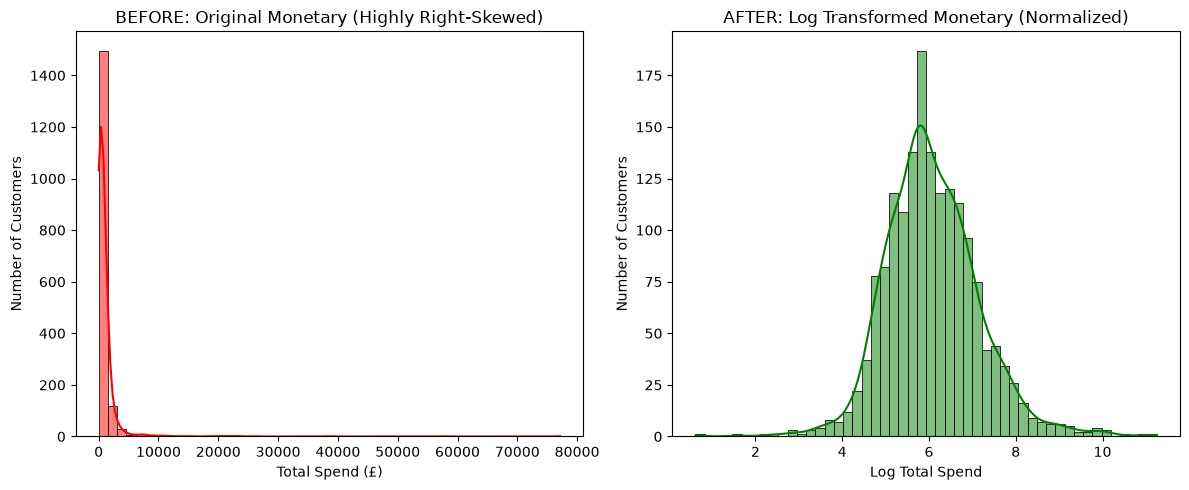

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- VISUALIZING LOG TRANSFORMATION (PIPELINE B) ---")

# We will look at the Baseline Cycle (Cycle 0) for the plot
baseline_rfm = rfm_cycles['Cycle_0']

# Set up the plotting area (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: BEFORE Log Transformation (Original Data)
sns.histplot(baseline_rfm['Monetary'], bins=50, ax=axes[0], color='red', kde=True)
axes[0].set_title('BEFORE: Original Monetary (Highly Right-Skewed)')
axes[0].set_xlabel('Total Spend (£)')
axes[0].set_ylabel('Number of Customers')

# Plot 2: AFTER Log Transformation
sns.histplot(baseline_rfm['Log_M'], bins=50, ax=axes[1], color='green', kde=True)
axes[1].set_title('AFTER: Log Transformed Monetary (Normalized)')
axes[1].set_xlabel('Log Total Spend')
axes[1].set_ylabel('Number of Customers')

# Show the graphs
plt.tight_layout()
plt.show()

--- VISUALIZING THE FULL PREPROCESSING PIPELINE ---


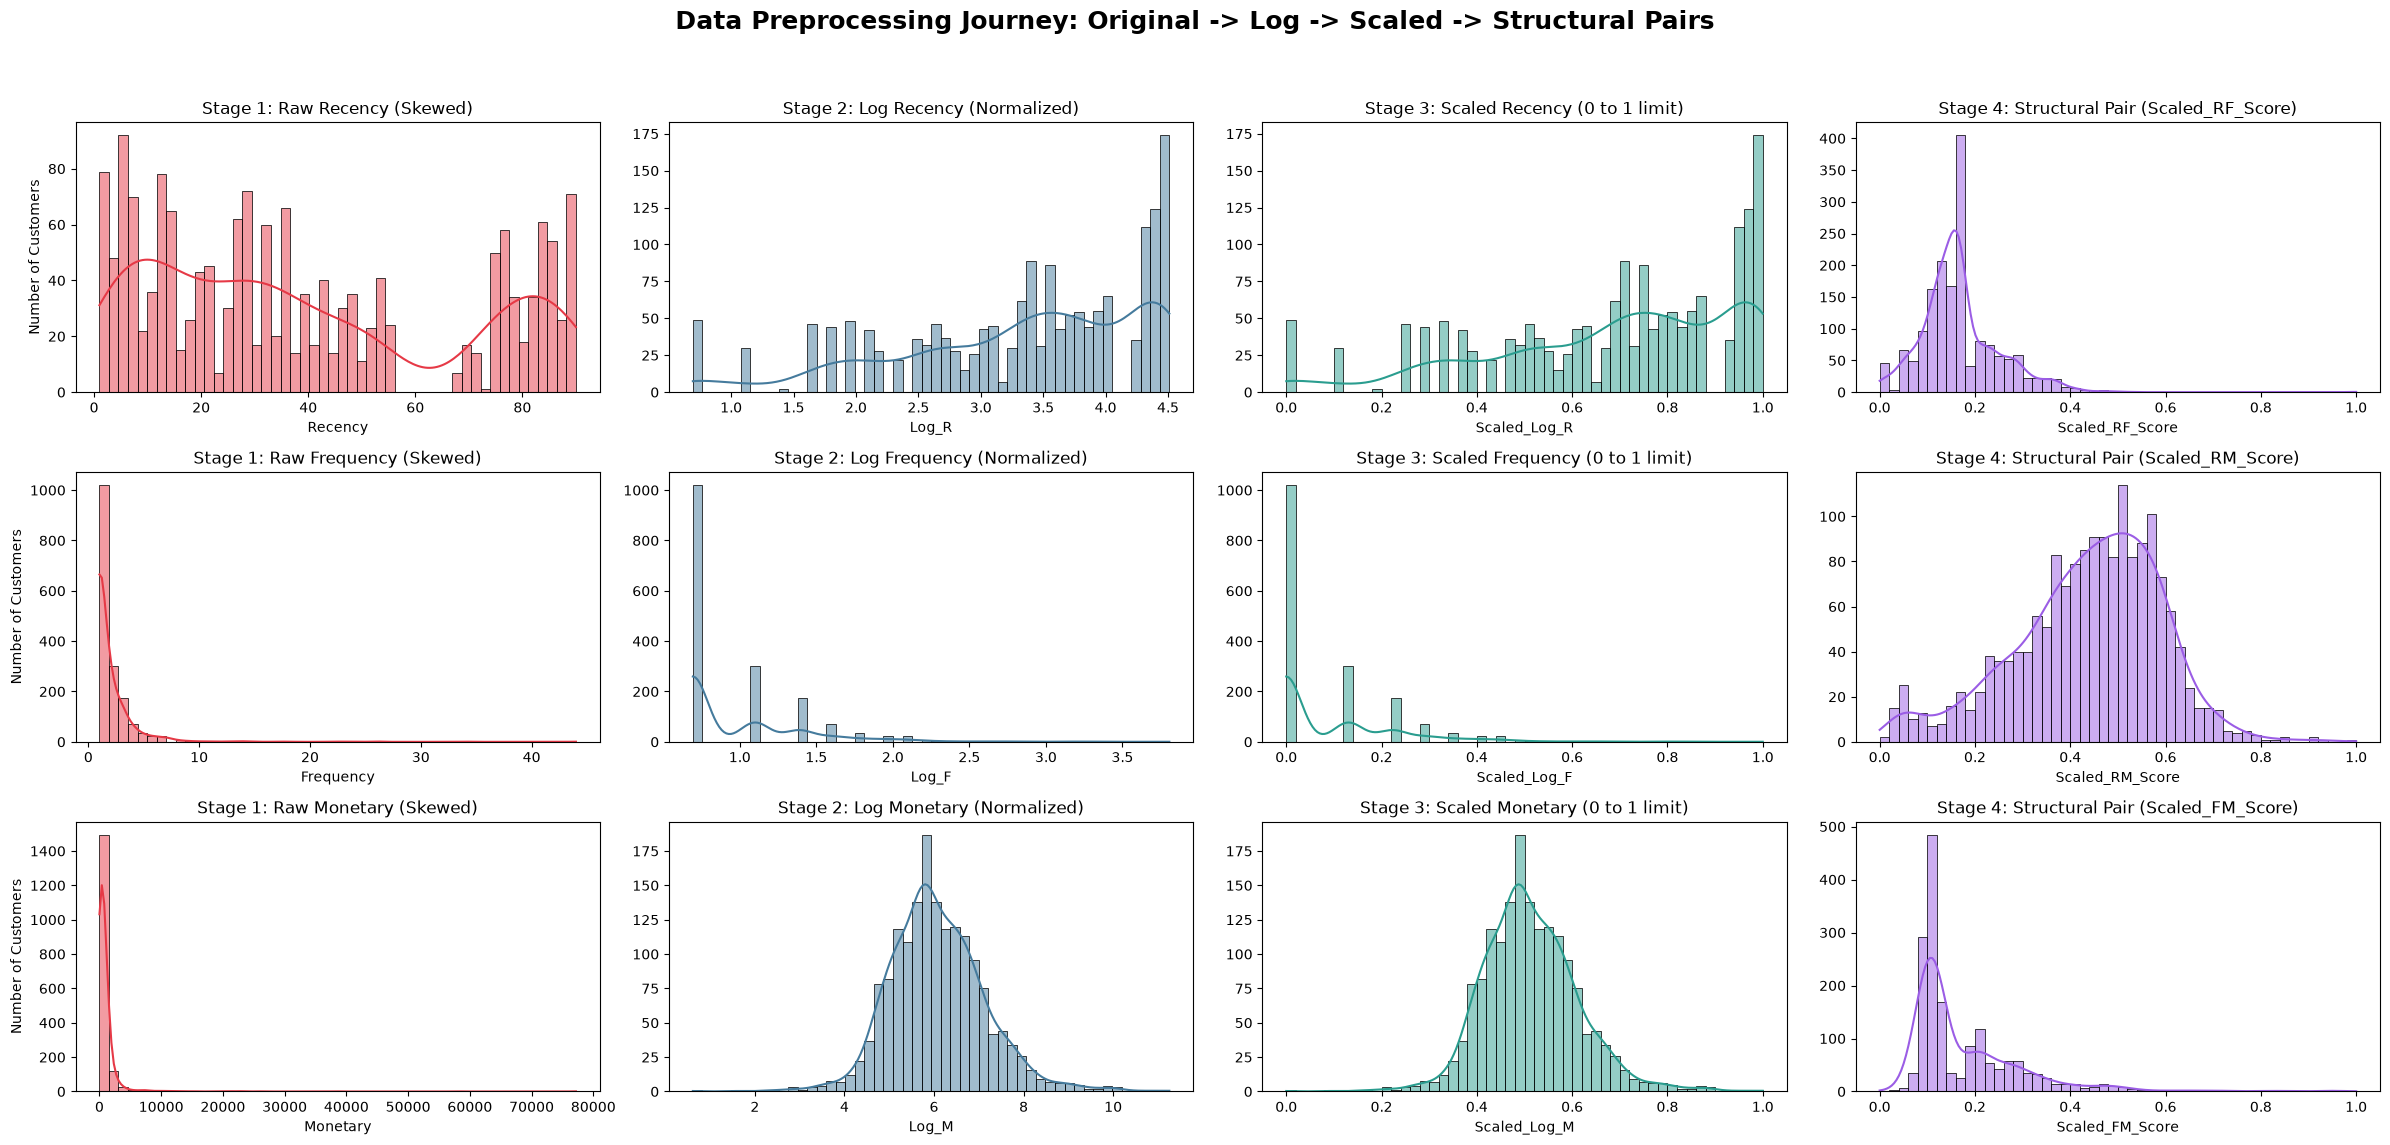

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- VISUALIZING THE FULL PREPROCESSING PIPELINE ---")

# We will use the Baseline Cycle (Cycle 0) for the plots
baseline_rfm = rfm_cycles['Cycle_0']

# Set up a 3x4 grid of plots (3 rows for R, F, M and 4 columns for the stages)
fig, axes = plt.subplots(3, 4, figsize=(24, 12))
fig.suptitle('Data Preprocessing Journey: Original -> Log -> Scaled -> Structural Pairs', fontsize=18, fontweight='bold')

# Feature lists to loop through
raw_features = ['Recency', 'Frequency', 'Monetary']
log_features = ['Log_R', 'Log_F', 'Log_M']
scaled_features = ['Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M']

# NEW: The Structural Interaction Pairs
pair_features = ['Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score'] 

# Stage Colors: Red (Skewed), Blue (Normalizing), Green (Scaled), Purple (Structural Pairs)
colors = ['#e63946', '#457b9d', '#2a9d8f', '#9b5de5']

for i in range(3):
    # Column 1: BEFORE (Original Raw Data)
    sns.histplot(baseline_rfm[raw_features[i]], bins=50, ax=axes[i, 0], color=colors[0], kde=True)
    axes[i, 0].set_title(f'Stage 1: Raw {raw_features[i]} (Skewed)', fontsize=12)
    axes[i, 0].set_ylabel('Number of Customers')
    
    # Column 2: MIDDLE (Log Transformed)
    sns.histplot(baseline_rfm[log_features[i]], bins=50, ax=axes[i, 1], color=colors[1], kde=True)
    axes[i, 1].set_title(f'Stage 2: Log {raw_features[i]} (Normalized)', fontsize=12)
    axes[i, 1].set_ylabel('') # Hide y-label for middle to avoid clutter
    
    # Column 3: AFTER (MinMax Scaled Base Features)
    sns.histplot(baseline_rfm[scaled_features[i]], bins=50, ax=axes[i, 2], color=colors[2], kde=True)
    axes[i, 2].set_title(f'Stage 3: Scaled {raw_features[i]} (0 to 1 limit)', fontsize=12)
    axes[i, 2].set_ylabel('')
    
    # Column 4: FINAL (Structural Pairs / Cascaded Scores)
    sns.histplot(baseline_rfm[pair_features[i]], bins=50, ax=axes[i, 3], color=colors[3], kde=True)
    axes[i, 3].set_title(f'Stage 4: Structural Pair ({pair_features[i]})', fontsize=12)
    axes[i, 3].set_ylabel('')

# Adjust layout so titles don't overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Creation of sql tables and database

In [5]:
import sqlite3
import pandas as pd
import json

print("--- PHASE 4: DATABASE CREATION (PIPELINE B) ---")

# 1. Initialize and connect to the Pipeline B SQLite Database
conn = sqlite3.connect('csrs_pipeline_b.db')
cursor = conn.cursor()

# Enable foreign keys for relational integrity
cursor.execute("PRAGMA foreign_keys = ON;")

# Step 1: Customer Table (Firmographic Segmentation ONLY)
# Stores unique customer profiles based on Business Location (Country)
cursor.execute('''
CREATE TABLE IF NOT EXISTS Customer (
    CustomerID TEXT PRIMARY KEY,
    Country TEXT
)
''')

# Step 2: Data Preprocessing Results Table
# Added Cycle_End_Date to accurately track the dynamic temporal slices
cursor.execute('''
CREATE TABLE IF NOT EXISTS Data_Preprocessing_Results (
    PreprocessID INTEGER PRIMARY KEY AUTOINCREMENT,
    CustomerID TEXT,
    CycleID TEXT,
    Cycle_End_Date TEXT,  -- NEW: Snapshot date for the cycle's RFM calculation
    Recency INTEGER,
    Frequency INTEGER,
    Monetary REAL,
    Recency_Bucket INTEGER,
    Log_R REAL,
    Log_F REAL,
    Log_M REAL,
    RF_Score REAL,
    RM_Score REAL,
    FM_Score REAL,
    Scaled_Log_R REAL,
    Scaled_Log_F REAL,
    Scaled_Log_M REAL,
    Scaled_RF_Score REAL,
    Scaled_RM_Score REAL,
    Scaled_FM_Score REAL,
    FOREIGN KEY(CustomerID) REFERENCES Customer(CustomerID)
)
''')

# Step 3: Time Cycle 0 Segmentation Table 
# Added Optimal K, Elbow Inertia, and Silhouette Score
cursor.execute('''
CREATE TABLE IF NOT EXISTS Time_Cycle_0_Segmentation (
    Cycle0_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    CustomerID TEXT,
    Optimal_K_Value INTEGER,       -- NEW: The optimal number of clusters chosen (e.g., 4)
    Elbow_Inertia_Value REAL,      -- NEW: The WCSS value at the elbow point
    Silhouette_Score REAL,         -- NEW: Model validation score for Cycle 0
    KMeans_Cluster_Number INTEGER, -- The specific cluster assigned to this customer (1 to K)
    Baseline_Segment_Name TEXT,
    Initial_Centroids TEXT,        -- Stored as JSON string
    FOREIGN KEY(CustomerID) REFERENCES Customer(CustomerID)
)
''')

# Step 4: Dynamic Loop Results Table 
# Added Previous_Cluster and All_Fuzzy_Memberships for realistic MDFCM tracking
cursor.execute('''
CREATE TABLE IF NOT EXISTS Dynamic_Loop_Results (
    DynamicID INTEGER PRIMARY KEY AUTOINCREMENT,
    CustomerID TEXT,
    CycleID TEXT,
    Previous_Cluster INTEGER,        -- NEW: Tracked from t-1 to determine migration
    MDFCM_Cluster_Number INTEGER,    
    Highest_Membership_Score REAL,   -- The winning fuzzy probability
    All_Fuzzy_Memberships TEXT,      -- NEW: JSON array of probabilities for ALL clusters
    Migration_Status TEXT,           -- e.g., 'Retained', 'Migrated Up', 'Migrated Down'
    Segment_Name TEXT,
    Updated_Centroids TEXT,          -- Stored as JSON string
    Dynamic_Silhouette_Score REAL,   -- NEW: Validation score for the current cycle
    FOREIGN KEY(CustomerID) REFERENCES Customer(CustomerID)
)
''')

# Commit the table structures to the database
conn.commit()

print("Pipeline B Database and Relational Tables successfully created.")
print("Tables ready: Customer, Data_Preprocessing_Results, Time_Cycle_0_Segmentation, Dynamic_Loop_Results.")

--- PHASE 4: DATABASE CREATION (PIPELINE B) ---
Pipeline B Database and Relational Tables successfully created.
Tables ready: Customer, Data_Preprocessing_Results, Time_Cycle_0_Segmentation, Dynamic_Loop_Results.


## Population of database 

In [6]:
import sqlite3
import pandas as pd

print("--- PHASE 4B: POPULATING BASE TABLES BEFORE K-MEANS ---")

# Connect to the Pipeline B database
conn = sqlite3.connect('csrs_pipeline_b.db')

# 1. Populate the 'Customer' Table (Firmographic Data)
# Extract unique CustomerIDs and their associated Country from the raw dataframe
firmographic_df = df_retail[['CustomerID', 'Country']].drop_duplicates(subset=['CustomerID']).copy()

# CLEANING STEP: CustomerIDs in the dataframe are currently floats (e.g., 12346.0). 
# We must convert them to integers and then strings to match our TEXT Primary Key schema cleanly.
firmographic_df['CustomerID'] = firmographic_df['CustomerID'].astype(int).astype(str)

try:
    firmographic_df.to_sql('Customer', conn, if_exists='append', index=False)
    print(f"Successfully inserted {len(firmographic_df)} unique B2B firmographic profiles into the 'Customer' table.")
except sqlite3.IntegrityError:
    print("Customer table already populated.")


# 2. Populate 'Data_Preprocessing_Results' Table
# We loop through the rfm_cycles dictionary generated in Phase 3
records_inserted = 0

for cycle_name, rfm_df in rfm_cycles.items():
    # Make a copy to avoid modifying the original dataframe
    insert_df = rfm_df.copy()
    
    # Add the CycleID column (e.g., 'Cycle_0', 'Cycle_1')
    insert_df['CycleID'] = cycle_name
    
    # Dynamically extract the Snapshot Date (Cycle_End_Date) from the corresponding all_cycles slice
    # This matches the max date + 1 day logic you used during preprocessing
    cycle_end_date = all_cycles[cycle_name]['InvoiceDate'].max() + pd.Timedelta(days=1)
    insert_df['Cycle_End_Date'] = cycle_end_date.strftime('%Y-%m-%d')
    
    # Ensure CustomerID is formatted as a clean string for accurate Foreign Key mapping
    insert_df['CustomerID'] = insert_df['CustomerID'].astype(int).astype(str)
    
    # Filter only the columns that match our SQLite schema perfectly
    cols_to_insert = [
        'CustomerID', 'CycleID', 'Cycle_End_Date', 'Recency', 'Frequency', 'Monetary', 
        'Recency_Bucket', 'Log_R', 'Log_F', 'Log_M', 'RF_Score', 'RM_Score', 'FM_Score', 
        'Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M', 'Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score'
    ]
    insert_df = insert_df[cols_to_insert]
    
    # Insert into the database
    insert_df.to_sql('Data_Preprocessing_Results', conn, if_exists='append', index=False)
    records_inserted += len(insert_df)

print(f"Successfully inserted {records_inserted} preprocessed RFM records across all cycles into 'Data_Preprocessing_Results'.")
print("Database is now primed. You can proceed with Time Cycle 0 Baseline K-Means.")

# Commit and safely close the connection
conn.commit()
conn.close()

--- PHASE 4B: POPULATING BASE TABLES BEFORE K-MEANS ---
Successfully inserted 4338 unique B2B firmographic profiles into the 'Customer' table.
Successfully inserted 12352 preprocessed RFM records across all cycles into 'Data_Preprocessing_Results'.
Database is now primed. You can proceed with Time Cycle 0 Baseline K-Means.


In [7]:
import sqlite3

print("--- UPGRADING DATABASE SCHEMA FOR VISUALIZATIONS ---")

conn = sqlite3.connect('csrs_pipeline_b.db')
cursor = conn.cursor()

# 1. Drop the old table so we can rebuild it with the new Visual fields
cursor.execute("DROP TABLE IF EXISTS Time_Cycle_0_Segmentation")

# 2. Recreate the table WITH the new PC1, PC2, and PC3 visual fields included
cursor.execute('''
CREATE TABLE Time_Cycle_0_Segmentation (
    Cycle0_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    CustomerID TEXT,
    Optimal_K_Value INTEGER,       
    Elbow_Inertia_Value REAL,      
    Silhouette_Score REAL,         
    KMeans_Cluster_Number INTEGER, 
    Baseline_Segment_Name TEXT,
    Initial_Centroids TEXT,        
    PC1 REAL,  -- NEW: X-Axis coordinate for 2D/3D visual dashboards
    PC2 REAL,  -- NEW: Y-Axis coordinate for 2D/3D visual dashboards
    PC3 REAL,  -- NEW: Z-Axis coordinate for 3D visual dashboards
    FOREIGN KEY(CustomerID) REFERENCES Customer(CustomerID)
)
''')

conn.commit()
conn.close()
print("Time_Cycle_0_Segmentation table upgraded successfully with PC1, PC2, and PC3 fields!")

--- UPGRADING DATABASE SCHEMA FOR VISUALIZATIONS ---
Time_Cycle_0_Segmentation table upgraded successfully with PC1, PC2, and PC3 fields!


## Dimension Reduction

In [8]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import joblib

print("--- DIMENSION REDUCTION (PCA) ---")

# Connect and fetch Cycle 0 data with ALL required columns
conn = sqlite3.connect('csrs_pipeline_b.db')

query = """
    SELECT CustomerID,
           Recency, Frequency, Monetary,
           Scaled_Log_R, Scaled_Log_F, Scaled_Log_M,
           Scaled_RF_Score, Scaled_RM_Score, Scaled_FM_Score
    FROM Data_Preprocessing_Results
    WHERE CycleID = 'Cycle_0'
"""
df_cycle0 = pd.read_sql_query(query, conn)
conn.close()

print(f"Loaded {len(df_cycle0)} records for Cycle 0.")

# Prepare feature matrix (6D)
feature_cols = [
    'Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M',
    'Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score'
]
X = df_cycle0[feature_cols].values

# Fit PCA to reduce to 3 components
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)

joblib.dump(
    pca,
    "cycle0_pca_model.pkl"
)

print("✓ PCA model saved.")

# Add PCA components to the dataframe
df_cycle0['PC1'] = X_pca[:, 0]
df_cycle0['PC2'] = X_pca[:, 1]
df_cycle0['PC3'] = X_pca[:, 2]

print("PCA completed. Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

--- DIMENSION REDUCTION (PCA) ---
Loaded 1682 records for Cycle 0.
✓ PCA model saved.
PCA completed. Explained variance ratio: [0.64302458 0.29850575 0.04977764]
Total variance explained: 0.9913079772264477


## Elbow Method 

--- ELBOW METHOD: OPTIMAL K SELECTION ---


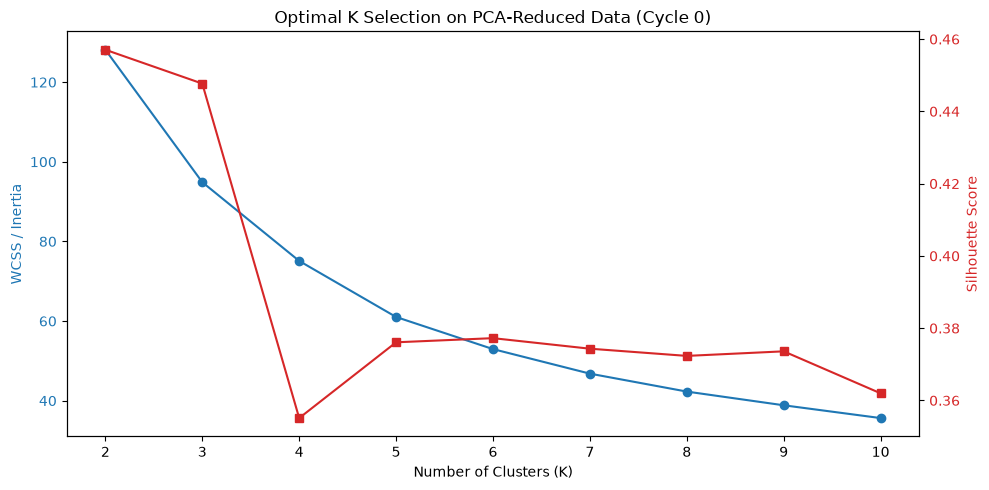


Selected K = 4
WCSS at K=4: 75.10
Silhouette Score at K=4: 0.3551


In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("--- ELBOW METHOD: OPTIMAL K SELECTION ---")

# Use the PCA-transformed data from the previous step
X_pca = df_cycle0[['PC1', 'PC2', 'PC3']].values

wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS / Inertia', color='tab:blue')
ax1.plot(K_range, wcss, marker='o', color='tab:blue', label='WCSS')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, silhouette_scores, marker='s', color='tab:red', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Optimal K Selection on PCA‑Reduced Data (Cycle 0)')
fig.tight_layout()
plt.show()

# Choose optimal K (here we set K=4 based on elbow and business interpretability)
optimal_k = 4
optimal_wcss = wcss[K_range.index(optimal_k)]
optimal_silhouette = silhouette_scores[K_range.index(optimal_k)]

print(f"\nSelected K = {optimal_k}")
print(f"WCSS at K={optimal_k}: {optimal_wcss:.2f}")
print(f"Silhouette Score at K={optimal_k}: {optimal_silhouette:.4f}")

## Initial K-Means segmentation

In [10]:
from sklearn.cluster import KMeans
import json

print("--- INITIAL K‑MEANS SEGMENTATION (BASELINE) ---")

# Use the PCA data and optimal K
X_pca = df_cycle0[['PC1', 'PC2', 'PC3']].values

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df_cycle0['KMeans_Cluster_Number'] = kmeans.fit_predict(X_pca)

# Centroids in PCA space (3D)
centroids_pca = kmeans.cluster_centers_
centroids_json = json.dumps(centroids_pca.tolist())

# ----- Raw Business Profiling (for naming segments) -----
# Compute average raw Recency, Frequency, Monetary per cluster
raw_metrics = df_cycle0.groupby('KMeans_Cluster_Number')[['Recency', 'Frequency', 'Monetary']].mean()
# We also add interaction terms for better insight (optional)
df_cycle0['Raw_RF'] = df_cycle0['Recency'] * df_cycle0['Frequency']
df_cycle0['Raw_RM'] = df_cycle0['Recency'] * df_cycle0['Monetary']
df_cycle0['Raw_FM'] = df_cycle0['Frequency'] * df_cycle0['Monetary']

cluster_profiles = df_cycle0.groupby('KMeans_Cluster_Number')[['Recency', 'Frequency', 'Monetary', 'Raw_RF', 'Raw_RM', 'Raw_FM']].mean()

print("\nCluster Profiles (Averages):")
print(cluster_profiles.round(2))

# Assign segment names based on business logic (adjust as needed)
# Example mapping based on the typical interpretation:
# Cluster 0: Champions (high frequency, high monetary, low recency)
# Cluster 1: Core Loyalists (medium-high frequency, medium monetary)
# Cluster 2: Mid-Tier Occasionals (low frequency, medium monetary)
# Cluster 3: Hibernating / Lost (low frequency, high recency)
# We'll create a manual mapping; you can adjust after inspecting the profiles.
segment_names = {
    0: 'Champions',
    1: 'Core Loyalists',
    2: 'Mid-Tier Occasionals',
    3: 'Hibernating / Lost'
}
# If clusters are numbered differently, remap accordingly.
# Here we assume the mapping above; you may need to reorder based on your data.
# For robustness, we can order by monetary descending:
ordered_clusters = cluster_profiles.sort_values('Monetary', ascending=False).index
# Assign names in that order
for i, cluster_id in enumerate(ordered_clusters):
    segment_names[cluster_id] = ['Champions', 'Core Loyalists', 'Mid-Tier Occasionals', 'Hibernating / Lost'][i]

df_cycle0['Baseline_Segment_Name'] = df_cycle0['KMeans_Cluster_Number'].map(segment_names)

# ----- Save to Database -----
conn = sqlite3.connect('csrs_pipeline_b.db')
cursor = conn.cursor()

# Clear old entries
cursor.execute("DELETE FROM Time_Cycle_0_Segmentation")
conn.commit()

# Prepare insertion DataFrame
insert_df = df_cycle0[['CustomerID', 'KMeans_Cluster_Number', 'Baseline_Segment_Name', 'PC1', 'PC2', 'PC3']].copy()
insert_df['Optimal_K_Value'] = optimal_k
insert_df['Elbow_Inertia_Value'] = optimal_wcss
insert_df['Silhouette_Score'] = optimal_silhouette
insert_df['Initial_Centroids'] = centroids_json

# Reorder columns to match schema
cols = ['CustomerID', 'Optimal_K_Value', 'Elbow_Inertia_Value', 'Silhouette_Score',
        'KMeans_Cluster_Number', 'Baseline_Segment_Name', 'Initial_Centroids',
        'PC1', 'PC2', 'PC3']
insert_df = insert_df[cols]

insert_df.to_sql('Time_Cycle_0_Segmentation', conn, if_exists='append', index=False)

conn.commit()
conn.close()

print(f"\nSaved {len(insert_df)} customer records with baseline segmentation and PCA coordinates.")
print("Phase 5 (Initial Segmentation) complete.")

--- INITIAL K‑MEANS SEGMENTATION (BASELINE) ---

Cluster Profiles (Averages):
                       Recency  Frequency  Monetary  Raw_RF    Raw_RM  \
KMeans_Cluster_Number                                                   
0                        19.46       5.26   2991.12   94.07  48347.26   
1                         4.63       2.03    705.83    8.20   2943.37   
2                        69.27       1.29    648.98   86.78  37512.48   
3                        25.87       1.27    394.72   31.92   9310.43   

                         Raw_FM  
KMeans_Cluster_Number            
0                      24389.17  
1                       2489.10  
2                        944.05  
3                        551.20  

Saved 1682 customer records with baseline segmentation and PCA coordinates.
Phase 5 (Initial Segmentation) complete.


### Database Visualisation

In [11]:
import sqlite3

conn = sqlite3.connect('csrs_pipeline_b.db')
cursor = conn.cursor()

# List all tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables in database:")
for table in tables:
    print(f"  {table[0]}")
    # Show columns for each table
    cursor.execute(f"PRAGMA table_info({table[0]})")
    cols = cursor.fetchall()
    for col in cols:
        print(f"    - {col[1]} ({col[2]})")
conn.close()

Tables in database:
  Customer
    - CustomerID (TEXT)
    - Country (TEXT)
  Data_Preprocessing_Results
    - PreprocessID (INTEGER)
    - CustomerID (TEXT)
    - CycleID (TEXT)
    - Cycle_End_Date (TEXT)
    - Recency (INTEGER)
    - Frequency (INTEGER)
    - Monetary (REAL)
    - Recency_Bucket (INTEGER)
    - Log_R (REAL)
    - Log_F (REAL)
    - Log_M (REAL)
    - RF_Score (REAL)
    - RM_Score (REAL)
    - FM_Score (REAL)
    - Scaled_Log_R (REAL)
    - Scaled_Log_F (REAL)
    - Scaled_Log_M (REAL)
    - Scaled_RF_Score (REAL)
    - Scaled_RM_Score (REAL)
    - Scaled_FM_Score (REAL)
  sqlite_sequence
    - name ()
    - seq ()
  Dynamic_Loop_Results
    - DynamicID (INTEGER)
    - CustomerID (TEXT)
    - CycleID (TEXT)
    - Previous_Cluster (INTEGER)
    - MDFCM_Cluster_Number (INTEGER)
    - Highest_Membership_Score (REAL)
    - All_Fuzzy_Memberships (TEXT)
    - Migration_Status (TEXT)
    - Segment_Name (TEXT)
    - Updated_Centroids (TEXT)
    - Dynamic_Silhouette_Score (R

### Dimension Reduction

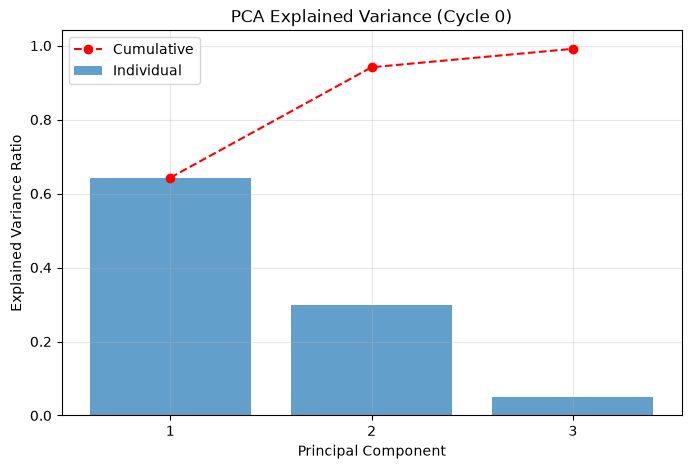

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# pca is already fitted from the dimension reduction step
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.bar(range(1,4), explained_variance, alpha=0.7, label='Individual')
plt.plot(range(1,4), cumulative_variance, marker='o', linestyle='--', color='red', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance (Cycle 0)')
plt.xticks([1,2,3])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

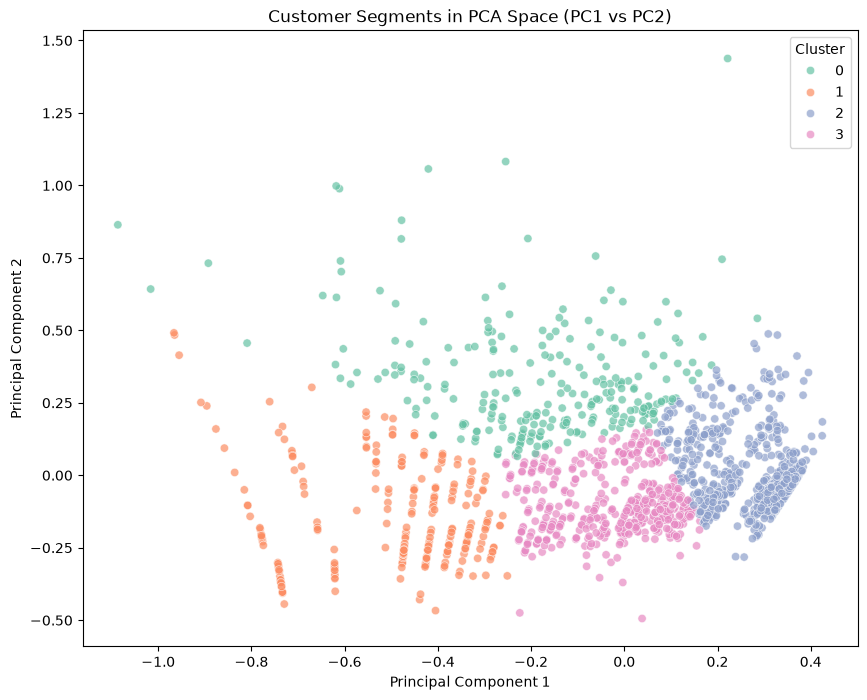

In [13]:
import seaborn as sns

# df_cycle0 already has PC1, PC2, PC3 and KMeans_Cluster_Number
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_cycle0, x='PC1', y='PC2', hue='KMeans_Cluster_Number', palette='Set2', alpha=0.7)
plt.title('Customer Segments in PCA Space (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

### Cluster profiles (average RFM + interaction terms) – bar chart

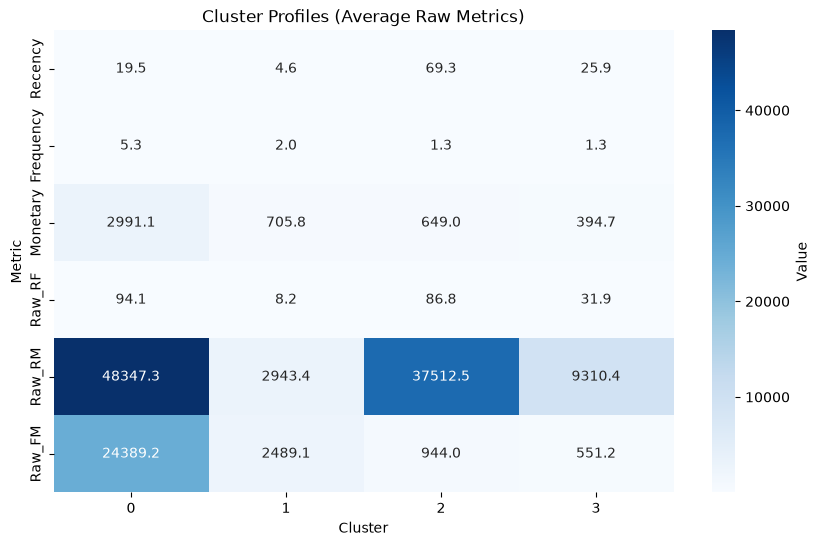

In [14]:
# Compute mean raw metrics per cluster
profile_cols = ['Recency', 'Frequency', 'Monetary', 'Raw_RF', 'Raw_RM', 'Raw_FM']
cluster_means = df_cycle0.groupby('KMeans_Cluster_Number')[profile_cols].mean()

# Plot as a heatmap for compact comparison
plt.figure(figsize=(10,6))
sns.heatmap(cluster_means.T, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Value'})
plt.title('Cluster Profiles (Average Raw Metrics)')
plt.xlabel('Cluster')
plt.ylabel('Metric')
plt.show()

visualazion


--- PHASE 5C: 3D PRESENTATION-READY VISUALIZATIONS ---
Loaded 1682 records with 3D PCA coordinates.


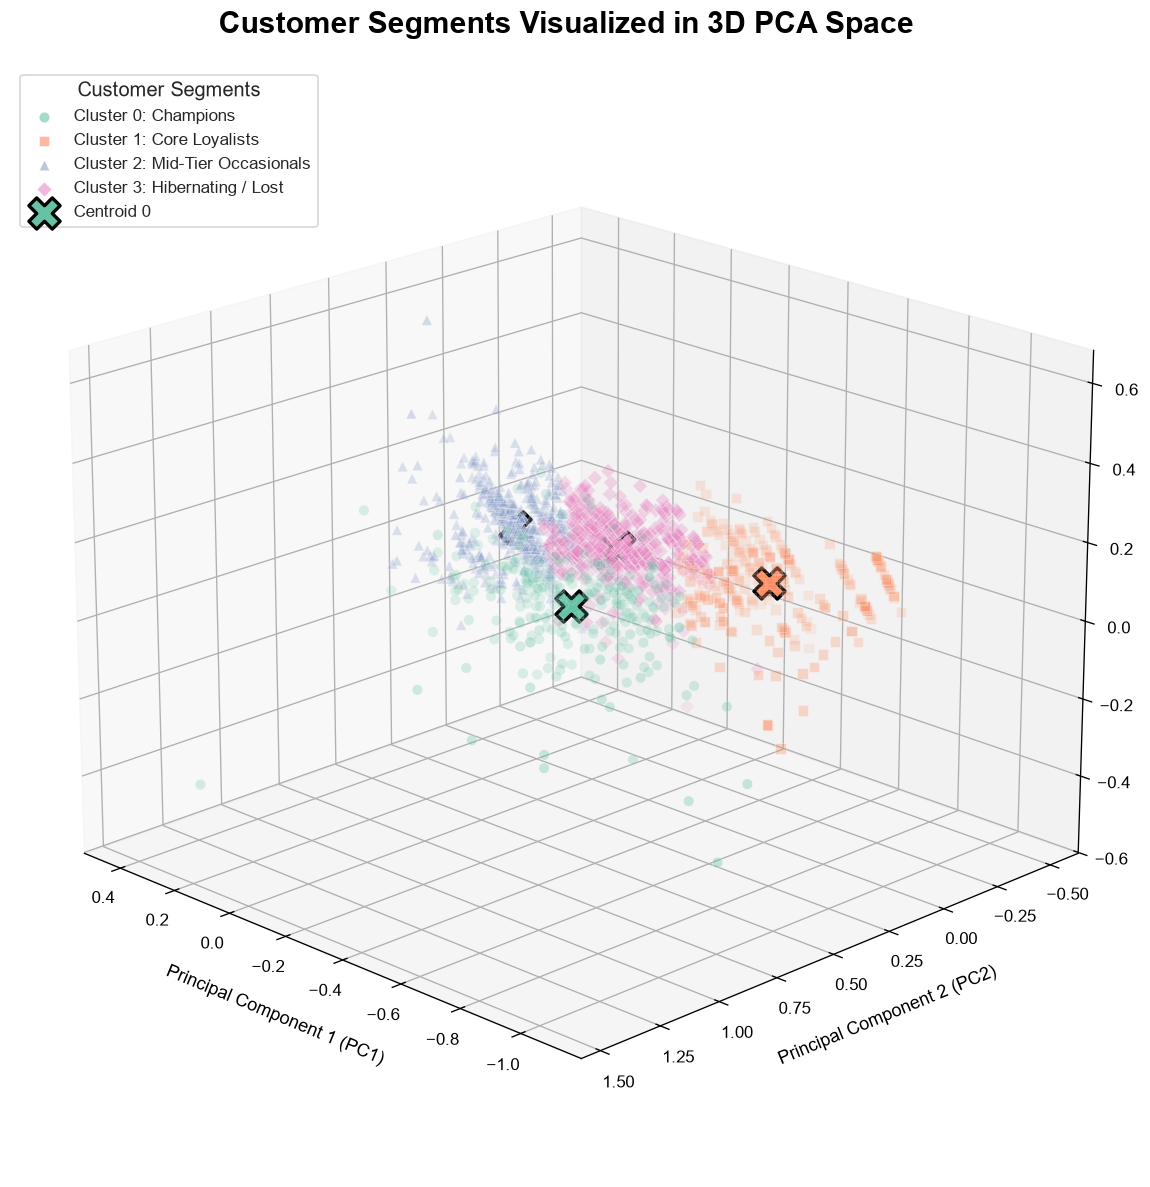

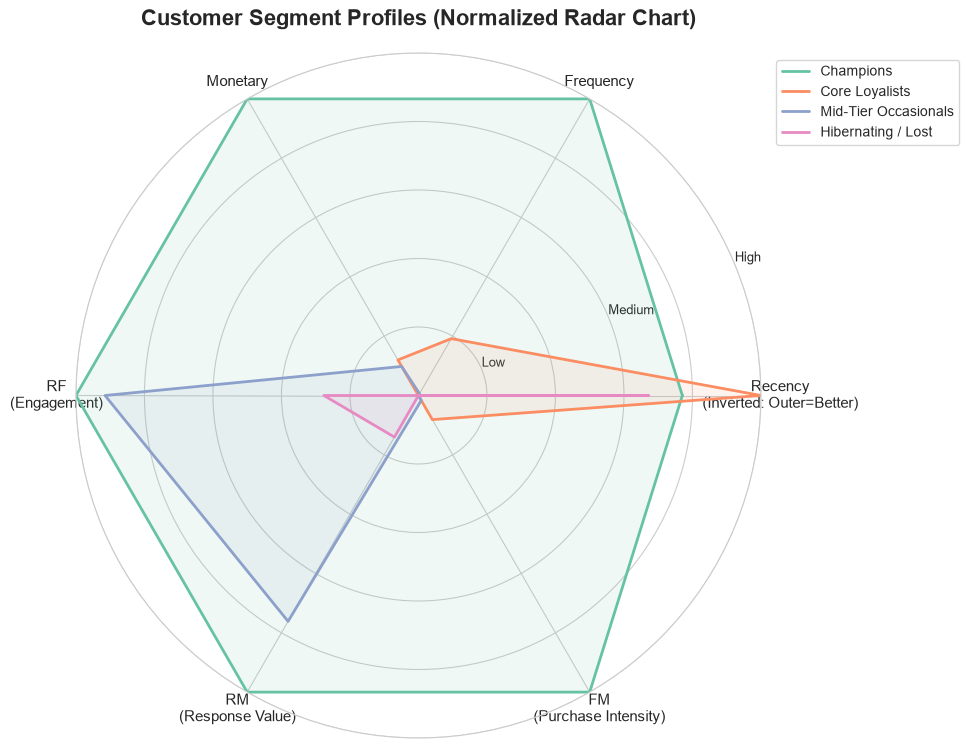

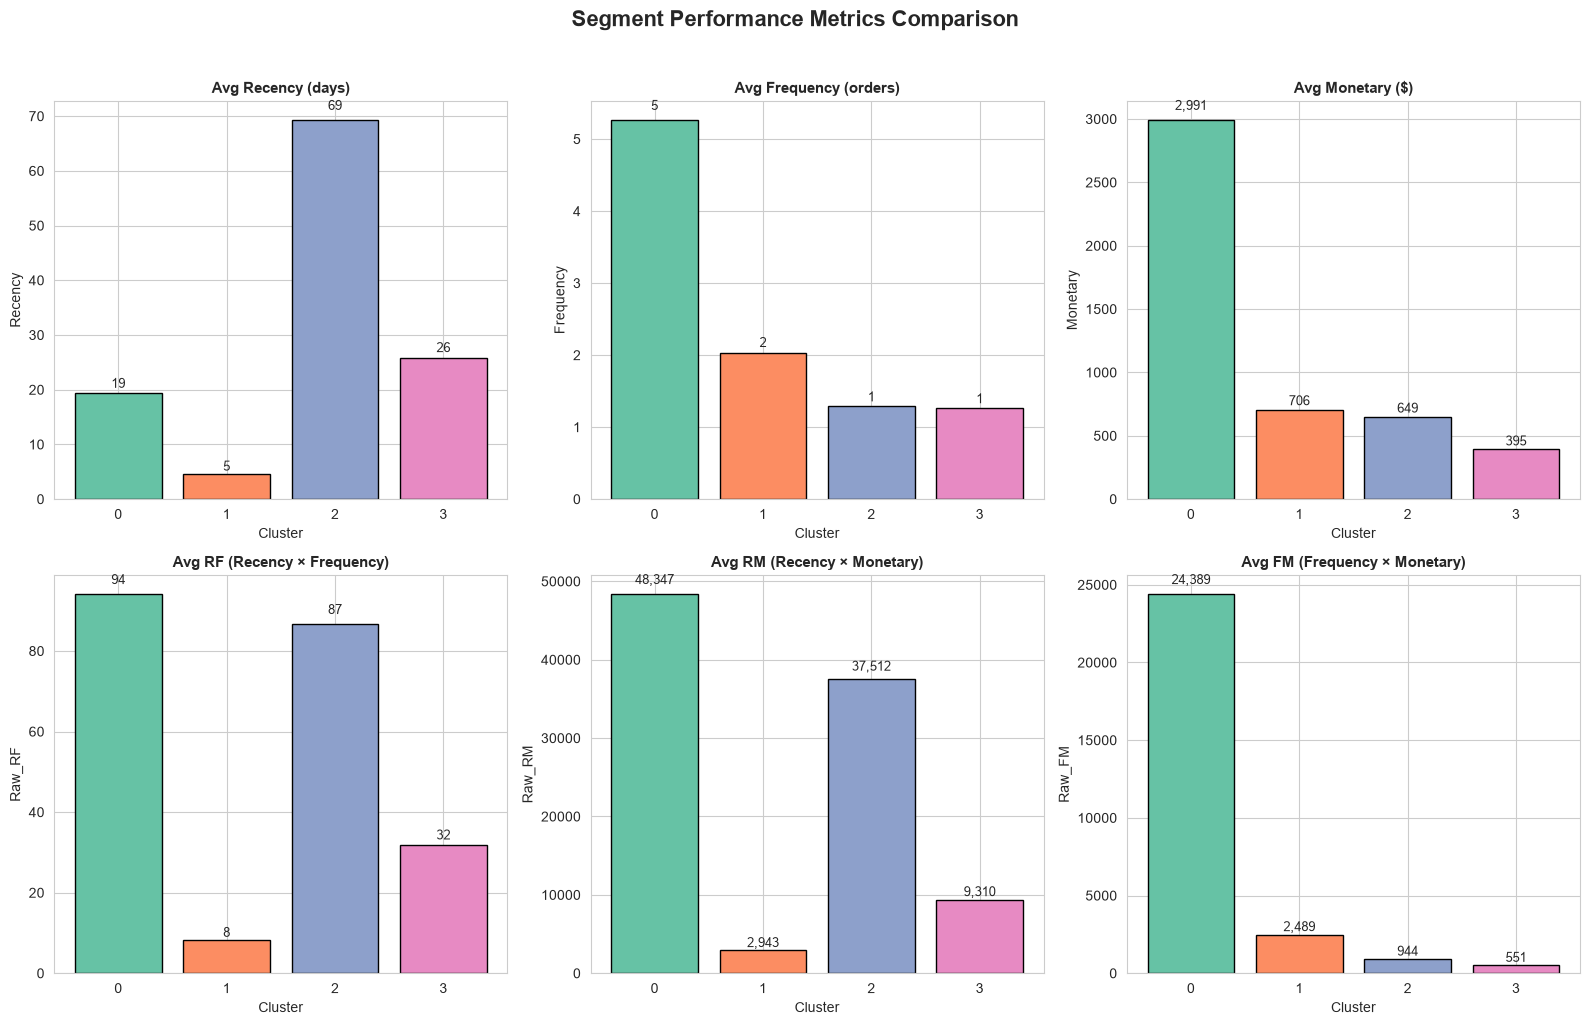


--- ALL VISUALIZATIONS SAVED AS HIGH-RES PNG FILES ---
1. pca_3d_cluster_visualization.png
2. radar_chart_segments.png
3. segment_metrics_barchart.png


In [15]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

print("--- PHASE 5C: 3D PRESENTATION-READY VISUALIZATIONS ---")

# 1. Fetch the clustered data WITH the saved 3D PCA components
conn = sqlite3.connect('csrs_pipeline_b.db')

# Notice we are pulling PC1, PC2, and PC3 directly from the database now!
query = """
    SELECT dp.CustomerID, 
           dp.Recency, dp.Frequency, dp.Monetary,
           ts.KMeans_Cluster_Number, ts.Baseline_Segment_Name,
           ts.PC1, ts.PC2, ts.PC3
    FROM Data_Preprocessing_Results dp
    JOIN Time_Cycle_0_Segmentation ts ON dp.CustomerID = ts.CustomerID
    WHERE dp.CycleID = 'Cycle_0'
"""
df_vis = pd.read_sql_query(query, conn)
conn.close()

if df_vis.empty:
    print("Error: No data found. Ensure Phase 5 was run and saved PC1, PC2, PC3.")
else:
    print(f"Loaded {len(df_vis)} records with 3D PCA coordinates.")

    # 1b. Calculate Raw Interaction Terms for Profiling Charts
    df_vis['Raw_RF'] = df_vis['Recency'] * df_vis['Frequency']
    df_vis['Raw_RM'] = df_vis['Recency'] * df_vis['Monetary']
    df_vis['Raw_FM'] = df_vis['Frequency'] * df_vis['Monetary']

    # Set up global styling and mappings
    marker_map = {0: 'o', 1: 's', 2: '^', 3: 'D'}  
    color_palette = sns.color_palette("Set2", n_colors=4).as_hex()

    # Dynamic names pulled directly from your database
    cluster_names = {
        k: v for k, v in zip(df_vis['KMeans_Cluster_Number'], df_vis['Baseline_Segment_Name'])
    }

    # ============================================================
    # VISUALIZATION 1: 3D SCATTER PLOT (PCA COMPONENTS 1, 2, & 3)
    # ============================================================
    fig = plt.figure(figsize=(14, 10), dpi=120)
    ax = fig.add_subplot(111, projection='3d')
    sns.set_style("whitegrid")

    for cluster_id in sorted(df_vis['KMeans_Cluster_Number'].unique()):
        cluster_data = df_vis[df_vis['KMeans_Cluster_Number'] == cluster_id]
        
        ax.scatter(
            cluster_data['PC1'],
            cluster_data['PC2'],
            cluster_data['PC3'],
            label=f"Cluster {cluster_id}: {cluster_names[cluster_id]}",
            alpha=0.6,
            s=40,
            marker=marker_map[cluster_id],
            color=color_palette[cluster_id],
            edgecolors='white',
            linewidth=0.5
        )

    # Add 3D centroids
    centroids = df_vis.groupby('KMeans_Cluster_Number')[['PC1', 'PC2', 'PC3']].mean()
    for cluster_id, row in centroids.iterrows():
        ax.scatter(
            row['PC1'], row['PC2'], row['PC3'],
            marker='X',
            s=350,
            color=color_palette[cluster_id],
            edgecolors='black',
            linewidths=2,
            zorder=10,
            label=f"Centroid {cluster_id}" if cluster_id == 0 else ""
        )

    ax.set_title('Customer Segments Visualized in 3D PCA Space', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Principal Component 1 (PC1)', fontsize=11, labelpad=10)
    ax.set_ylabel('Principal Component 2 (PC2)', fontsize=11, labelpad=10)
    ax.set_zlabel('Principal Component 3 (PC3)', fontsize=11, labelpad=10)
    
    # Optimize viewing angle
    ax.view_init(elev=20, azim=135)
    
    # Filter duplicate labels in legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title='Customer Segments', title_fontsize=12, fontsize=10, loc='upper left')
    
    plt.tight_layout()
    plt.savefig('pca_3d_cluster_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ============================================================
    # VISUALIZATION 2: RADAR CHART FOR SEGMENT PROFILES
    # ============================================================
    raw_cols = ['Recency', 'Frequency', 'Monetary', 'Raw_RF', 'Raw_RM', 'Raw_FM']
    cluster_means = df_vis.groupby('KMeans_Cluster_Number')[raw_cols].mean()

    # Normalize (Min-Max)
    normalized = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

    # Invert Recency so '1.0' (outer edge) means 'Good' (Low Recency)
    normalized['Recency'] = 1 - normalized['Recency']

    categories = ['Recency\n(Inverted: Outer=Better)', 'Frequency', 'Monetary', 'RF\n(Engagement)', 'RM\n(Response Value)', 'FM\n(Purchase Intensity)']
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    ordered_names = [cluster_names[i] for i in sorted(cluster_names.keys())]

    for i, cluster_id in enumerate(sorted(normalized.index)):
        values = normalized.loc[cluster_id].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, color=color_palette[i], linewidth=2, linestyle='solid', label=ordered_names[i])
        ax.fill(angles, values, color=color_palette[i], alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['Low', '', 'Medium', '', 'High'], fontsize=9)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
    plt.title('Customer Segment Profiles (Normalized Radar Chart)', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('radar_chart_segments.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ============================================================
    # VISUALIZATION 3: BAR CHART - KEY METRICS PER SEGMENT
    # ============================================================
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    metrics = ['Recency', 'Frequency', 'Monetary', 'Raw_RF', 'Raw_RM', 'Raw_FM']
    titles = ['Avg Recency (days)', 'Avg Frequency (orders)', 'Avg Monetary ($)', 
              'Avg RF (Recency × Frequency)', 'Avg RM (Recency × Monetary)', 'Avg FM (Frequency × Monetary)']

    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        row, col = idx // 3, idx % 3
        ax = axes[row, col]
        
        sorted_data = cluster_means[metric].sort_index()
        bars = ax.bar(sorted_data.index.astype(str), sorted_data.values, color=color_palette, edgecolor='black')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Cluster', fontsize=10)
        ax.set_ylabel(metric, fontsize=10)
        
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + (height * 0.02),
                    f'{height:,.0f}', ha='center', va='bottom', fontsize=9, rotation=0)

    plt.suptitle('Segment Performance Metrics Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('segment_metrics_barchart.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n--- ALL VISUALIZATIONS SAVED AS HIGH-RES PNG FILES ---")
    print("1. pca_3d_cluster_visualization.png")
    print("2. radar_chart_segments.png")
    print("3. segment_metrics_barchart.png")

In [16]:
import sqlite3
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("--- PHASE 5D: CYCLE 0 MODEL EVALUATION & VALIDATION ---")

# 1. Fetch the 3D PCA coordinates and labels from the database
conn = sqlite3.connect('csrs_pipeline_b.db')

query = """
    SELECT CustomerID, PC1, PC2, PC3, KMeans_Cluster_Number
    FROM Time_Cycle_0_Segmentation
"""
df_eval = pd.read_sql_query(query, conn)

if df_eval.empty:
    print("Error: No data found. Please run Phase 5 first.")
else:
    # 2. Prepare the feature matrix (3D PCA) and the assigned cluster labels
    X_eval = df_eval[['PC1', 'PC2', 'PC3']].values
    labels = df_eval['KMeans_Cluster_Number'].values

    # 3. Calculate Formal Evaluation Metrics
    # Note: We calculate these on the PCA components since that is what K-Means clustered on.
    print("Calculating metrics. This may take a few seconds...")
    
    sil_score = silhouette_score(X_eval, labels)
    ch_score = calinski_harabasz_score(X_eval, labels)
    db_score = davies_bouldin_score(X_eval, labels)

    # 4. Print the Official Evaluation Report
    print("\n==========================================================")
    print("       BASELINE MODEL EVALUATION REPORT (CYCLE 0)         ")
    print("==========================================================")
    print(f"Algorithm Used           : K-Means (k=4) on 3D PCA space")
    print(f"Total Customers Assessed : {len(df_eval):,}")
    print("----------------------------------------------------------")
    print(f"1. Silhouette Score      : {sil_score:.4f}  (Ideal: > 0.3 for real retail data)")
    print(f"2. Calinski-Harabasz     : {ch_score:,.2f}  (Higher = Denser, Better separated)")
    print(f"3. Davies-Bouldin Index  : {db_score:.4f}  (Lower = Better, Ideal: < 1.5)")
    print("==========================================================")

    # 5. Update the Database with the real Silhouette Score
    # We replace the -1.0 placeholder we set earlier
    try:
        cursor = conn.cursor()
        cursor.execute("""
            UPDATE Time_Cycle_0_Segmentation 
            SET Silhouette_Score = ? 
            WHERE Silhouette_Score = -1.0 OR Silhouette_Score IS NULL
        """, (float(sil_score),))
        conn.commit()
        print("\nSUCCESS: Database successfully updated with the calculated Silhouette Score.")
    except Exception as e:
        print(f"\nFailed to update database: {e}")

conn.close()

--- PHASE 5D: CYCLE 0 MODEL EVALUATION & VALIDATION ---
Calculating metrics. This may take a few seconds...

       BASELINE MODEL EVALUATION REPORT (CYCLE 0)         
Algorithm Used           : K-Means (k=4) on 3D PCA space
Total Customers Assessed : 1,682
----------------------------------------------------------
1. Silhouette Score      : 0.3551  (Ideal: > 0.3 for real retail data)
2. Calinski-Harabasz     : 1,215.56  (Higher = Denser, Better separated)
3. Davies-Bouldin Index  : 0.9440  (Lower = Better, Ideal: < 1.5)

SUCCESS: Database successfully updated with the calculated Silhouette Score.


### States of 5 customers 

In [17]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('csrs_pipeline_b.db')

# Retrieve the current "State" of 5 random customers
query = """
    SELECT CustomerID, 
           Baseline_Segment_Name AS Cycle_0_State, 
           PC1, PC2, PC3
    FROM Time_Cycle_0_Segmentation
    LIMIT 5
"""
state_check_df = pd.read_sql_query(query, conn)
conn.close()

print("--- PIPELINE B: CUSTOMER STATE RETRIEVAL CHECK ---")
print(state_check_df)

--- PIPELINE B: CUSTOMER STATE RETRIEVAL CHECK ---
  CustomerID         Cycle_0_State       PC1       PC2       PC3
0      12346  Mid-Tier Occasionals  0.300170  0.356391  0.600180
1      12347  Mid-Tier Occasionals  0.089734  0.154403  0.072414
2      12348  Mid-Tier Occasionals  0.096995  0.152407  0.066510
3      12350    Hibernating / Lost  0.026186 -0.117764  0.037058
4      12352    Hibernating / Lost -0.176684 -0.185579  0.033965


In [18]:
import sqlite3

conn = sqlite3.connect('csrs_pipeline_b.db')
cursor = conn.cursor()

# Rename column in Time_Cycle_0_Segmentation
cursor.execute("ALTER TABLE Time_Cycle_0_Segmentation RENAME COLUMN Baseline_Segment_Name TO Segment_Name;")

conn.commit()
conn.close()

In [19]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('csrs_pipeline_b.db')

query = """
    SELECT ts.KMeans_Cluster_Number,
           ts.Segment_Name AS Segment_Name,   -- alias changed to Segment_Name
           COUNT(dp.CustomerID) as Customer_Count,
           ROUND(AVG(dp.Recency), 0) AS Avg_Recency_Days,
           ROUND(AVG(dp.Frequency), 0) AS Avg_Frequency,
           ROUND(AVG(dp.Monetary), 2) AS Avg_Monetary_Spend
    FROM Time_Cycle_0_Segmentation ts
    JOIN Data_Preprocessing_Results dp ON ts.CustomerID = dp.CustomerID
    WHERE dp.CycleID = 'Cycle_0'
    GROUP BY ts.KMeans_Cluster_Number, ts.Segment_Name
    ORDER BY ts.KMeans_Cluster_Number
"""
diagnostic_df = pd.read_sql_query(query, conn)
conn.close()

print("--- CLUSTER PROFILE DIAGNOSTIC ---")
print(diagnostic_df.to_string(index=False))

--- CLUSTER PROFILE DIAGNOSTIC ---
 KMeans_Cluster_Number         Segment_Name  Customer_Count  Avg_Recency_Days  Avg_Frequency  Avg_Monetary_Spend
                     0            Champions             259              19.0            5.0             2991.12
                     1       Core Loyalists             258               5.0            2.0              705.83
                     2 Mid-Tier Occasionals             679              69.0            1.0              648.98
                     3   Hibernating / Lost             486              26.0            1.0              394.72


### Visualizations more

--- ENHANCED VISUALIZATIONS FOR K-MEANS RESULTS (CYCLE 0) ---


C:\Users\siyam\AppData\Local\Temp\ipykernel_17280\2088738067.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=size_counts.index, y=size_counts.values, palette=palette, ax=ax2)


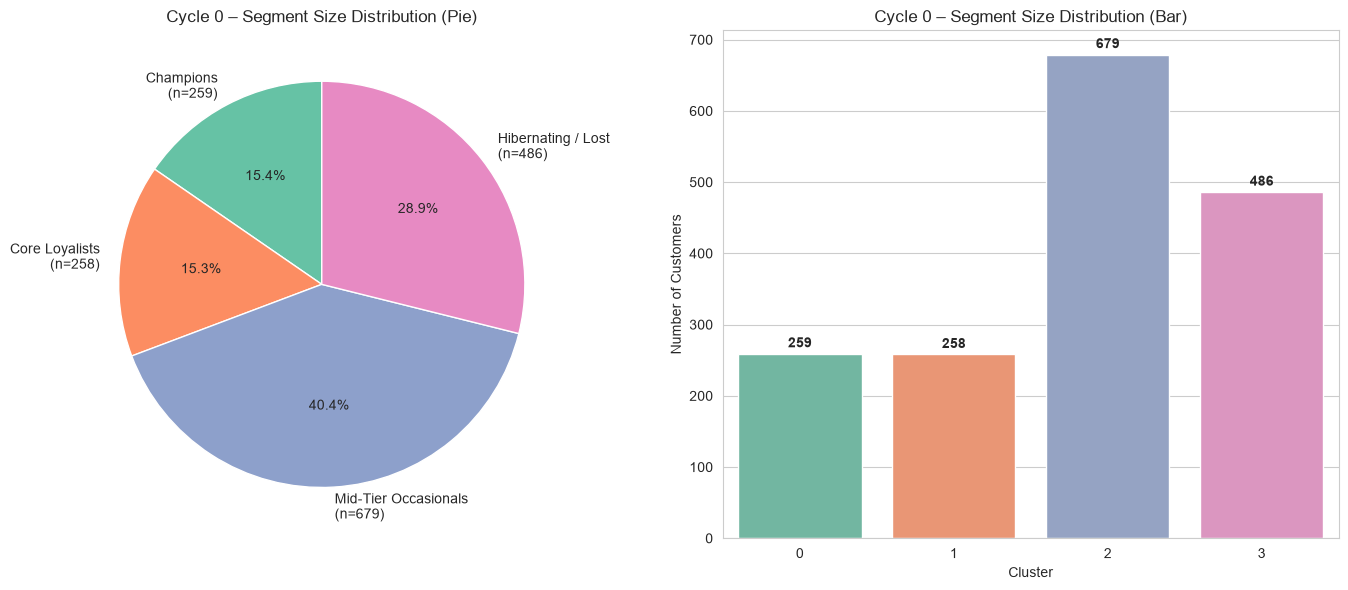

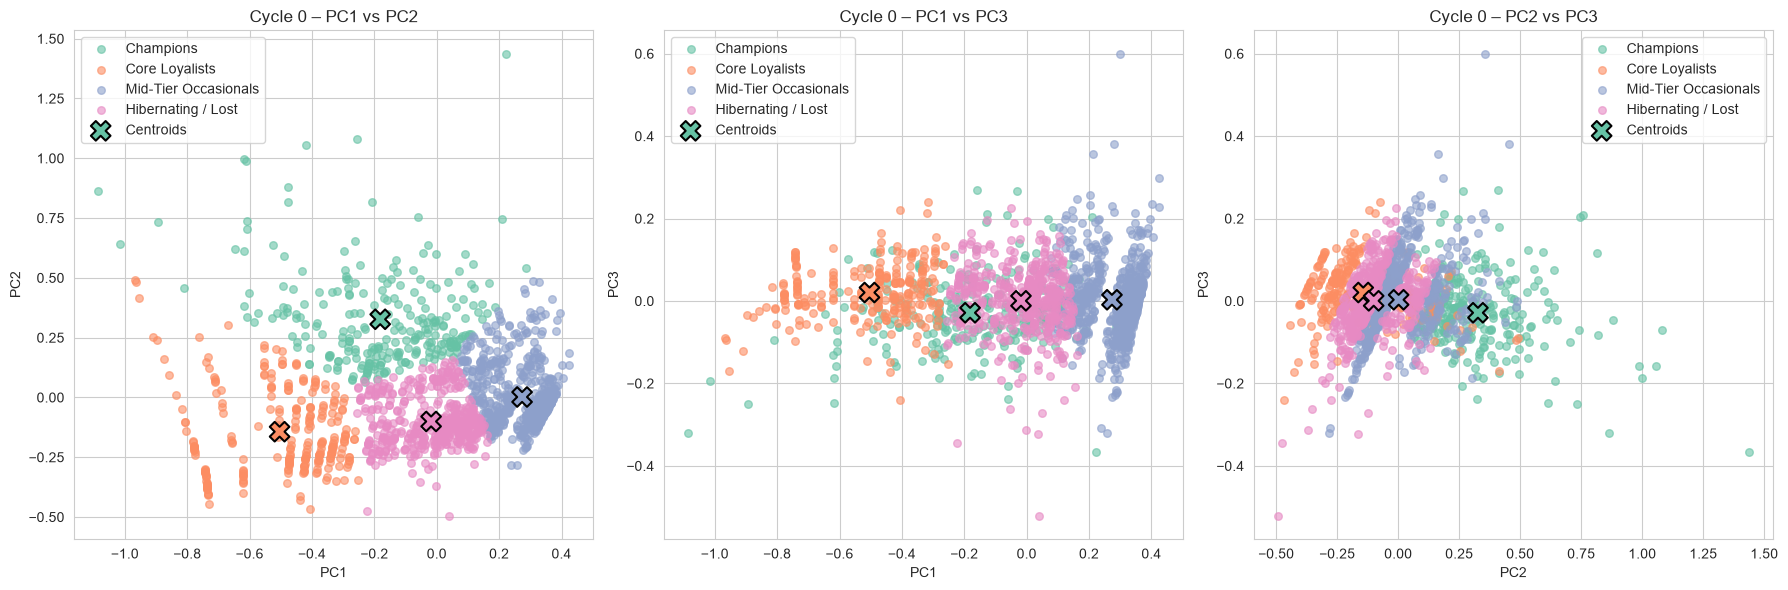

C:\Users\siyam\AppData\Local\Temp\ipykernel_17280\2088738067.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='KMeans_Cluster_Number', y=metric, palette=palette, ax=ax)
C:\Users\siyam\AppData\Local\Temp\ipykernel_17280\2088738067.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='KMeans_Cluster_Number', y=metric, palette=palette, ax=ax)
C:\Users\siyam\AppData\Local\Temp\ipykernel_17280\2088738067.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='KMeans_Cluster_Number', y=metric, palette=palette, ax

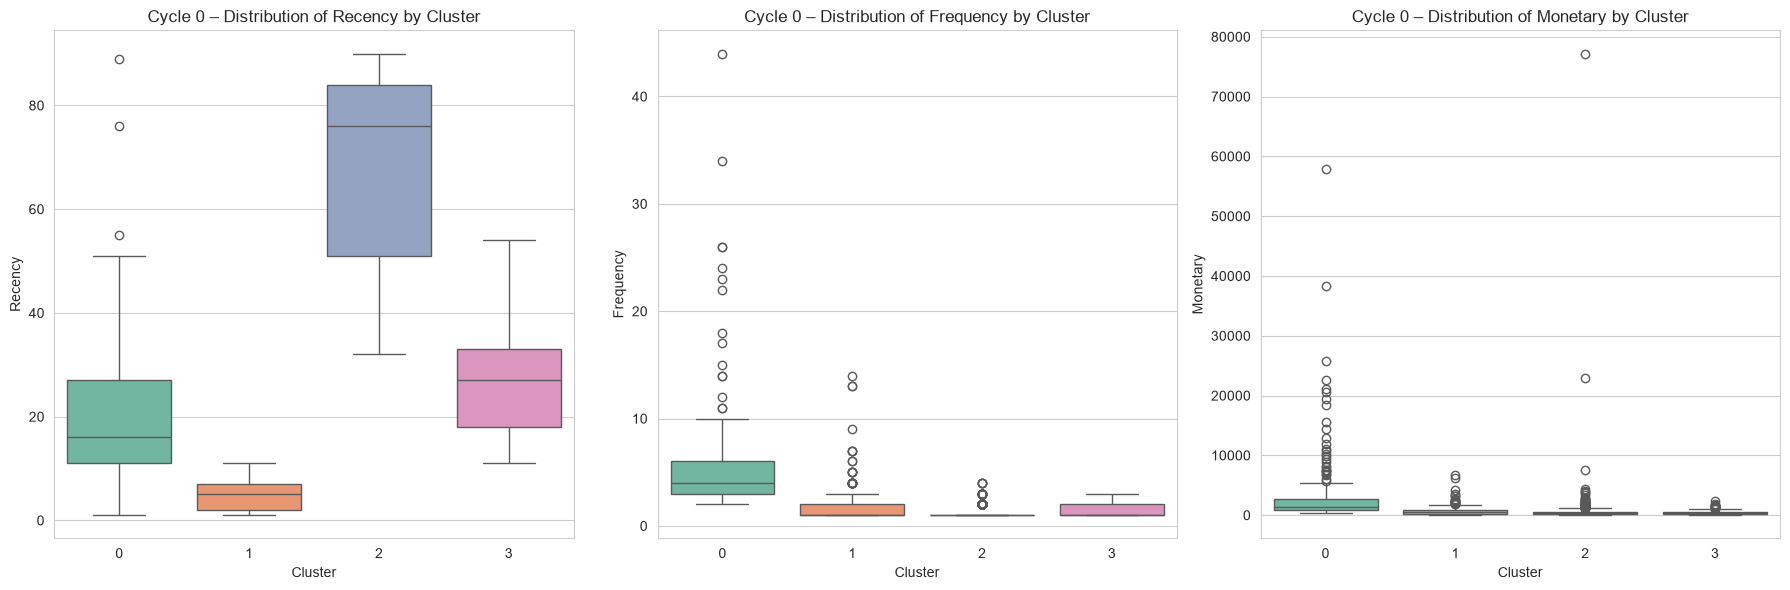

C:\Users\siyam\AppData\Local\Temp\ipykernel_17280\2088738067.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='KMeans_Cluster_Number', y=metric, palette=palette, inner='quart', ax=ax)
C:\Users\siyam\AppData\Local\Temp\ipykernel_17280\2088738067.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='KMeans_Cluster_Number', y=metric, palette=palette, inner='quart', ax=ax)
C:\Users\siyam\AppData\Local\Temp\ipykernel_17280\2088738067.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='KMeans_Clus

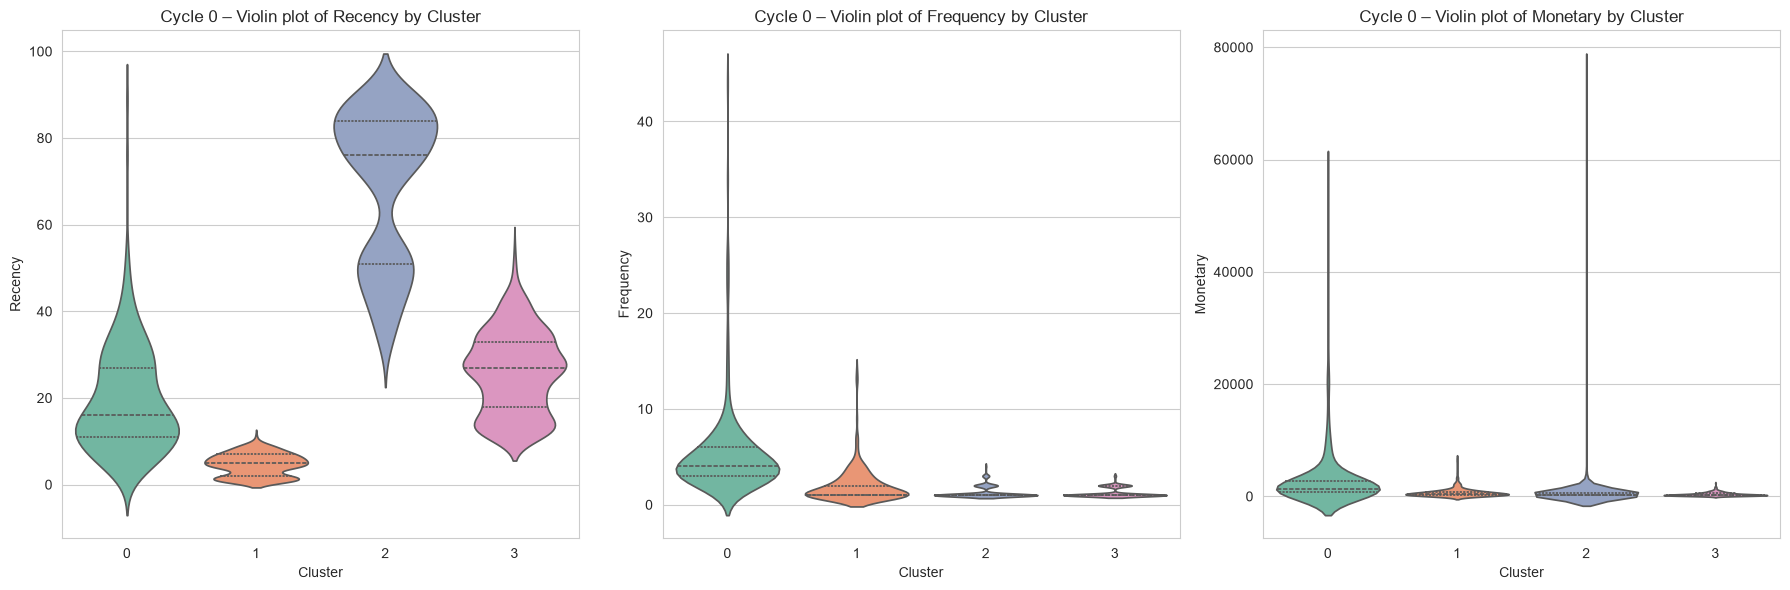

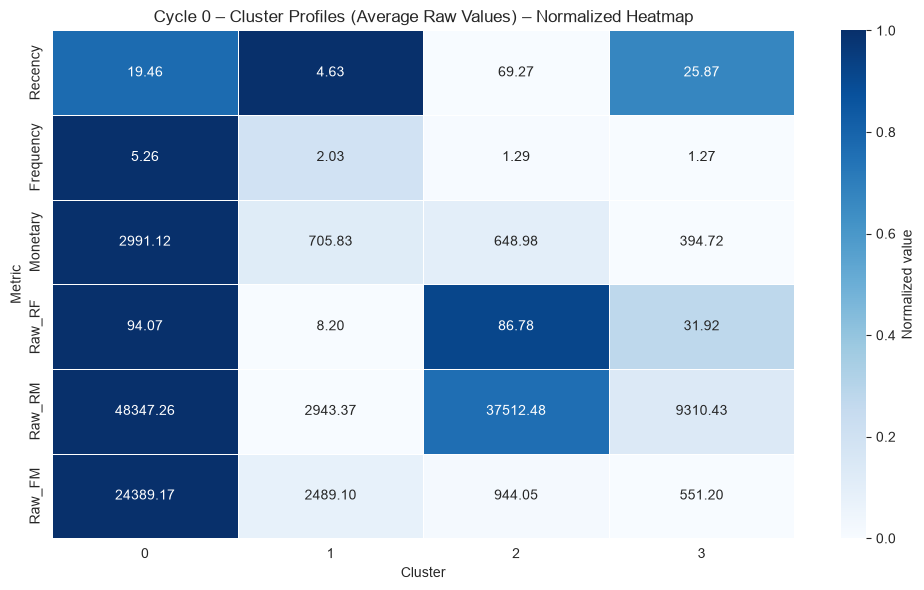

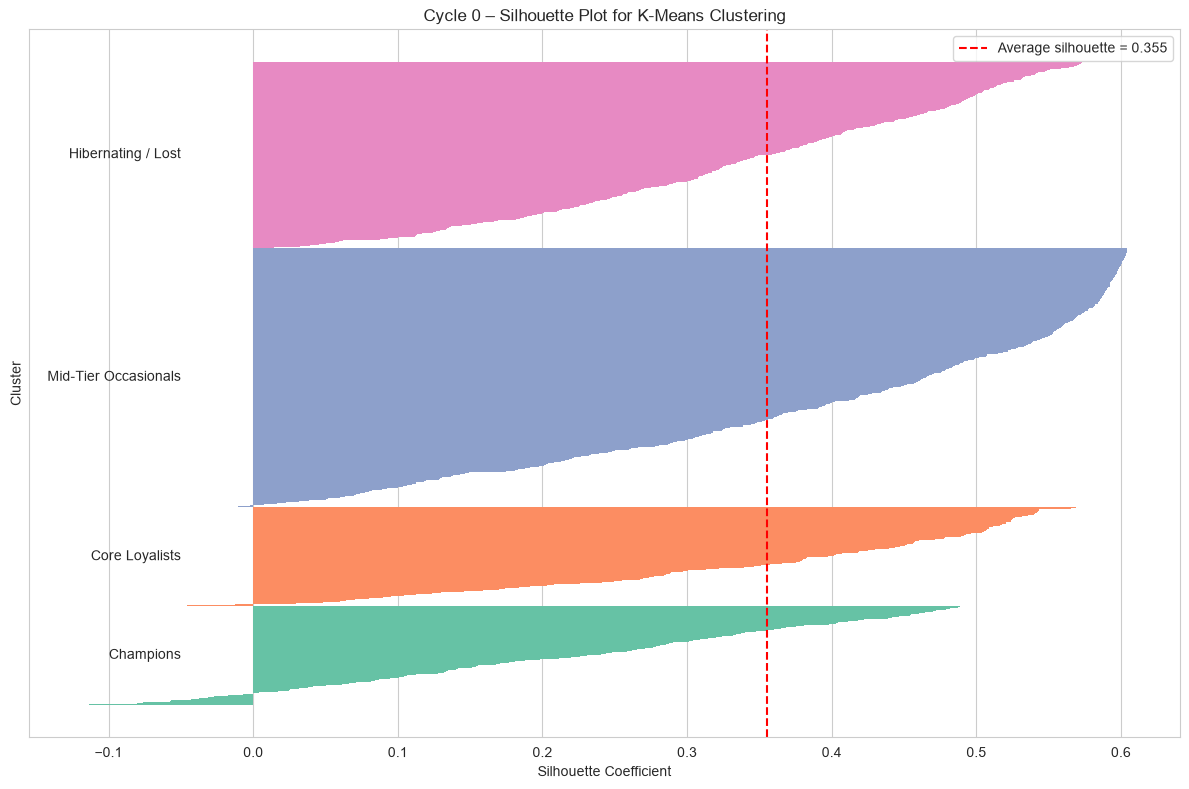

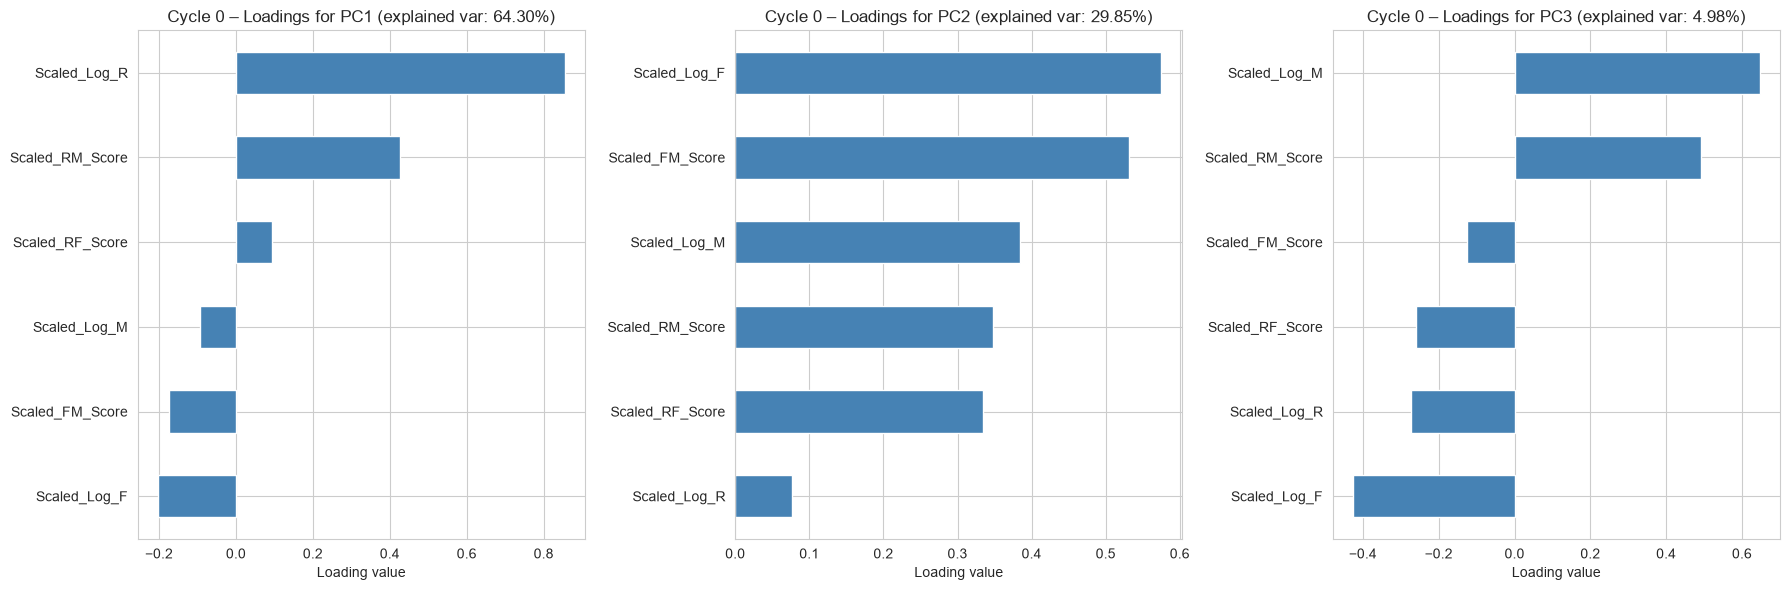

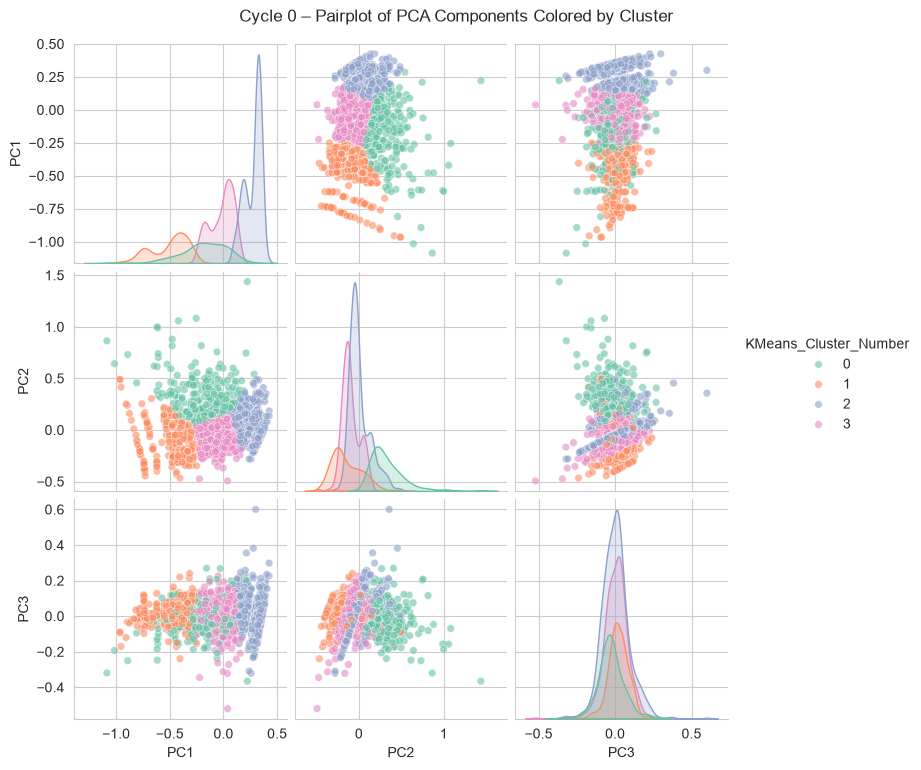


--- CYCLE 0 VISUALIZATIONS SAVED ---
Files generated with 'cycle0_' prefix:
1. cycle0_cluster_sizes.png
2. cycle0_pca_2d_scatter.png
3. cycle0_boxplots_rfm.png
4. cycle0_violin_rfm.png
5. cycle0_cluster_profiles_heatmap.png
6. cycle0_silhouette_plot.png
7. cycle0_pca_loadings.png
8. cycle0_pca_pairplot.png


In [20]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_samples
from sklearn.decomposition import PCA
from math import pi

print("--- ENHANCED VISUALIZATIONS FOR K-MEANS RESULTS (CYCLE 0) ---")

# Fetch data (same as before)
conn = sqlite3.connect('csrs_pipeline_b.db')
query = """
    SELECT dp.CustomerID, 
           dp.Recency, dp.Frequency, dp.Monetary,
           ts.KMeans_Cluster_Number, ts.Segment_Name,
           ts.PC1, ts.PC2, ts.PC3
    FROM Data_Preprocessing_Results dp
    JOIN Time_Cycle_0_Segmentation ts ON dp.CustomerID = ts.CustomerID
    WHERE dp.CycleID = 'Cycle_0'
"""
df = pd.read_sql_query(query, conn)


if df.empty:
    raise ValueError("No data found. Run K-means segmentation first.")

# Create interaction terms
df['Raw_RF'] = df['Recency'] * df['Frequency']
df['Raw_RM'] = df['Recency'] * df['Monetary']
df['Raw_FM'] = df['Frequency'] * df['Monetary']

# Cluster info
clusters = sorted(df['KMeans_Cluster_Number'].unique())
n_clusters = len(clusters)
palette = sns.color_palette("Set2", n_colors=n_clusters)
cluster_colors = {c: palette[i] for i, c in enumerate(clusters)}
cluster_names = df.groupby('KMeans_Cluster_Number')['Segment_Name'].first().to_dict()

# ----------------------------------------------------------------------
# 1. CLUSTER SIZE DISTRIBUTION (Pie + Bar) – with Cycle 0 title
# ----------------------------------------------------------------------
size_counts = df['KMeans_Cluster_Number'].value_counts().sort_index()
labels = [f"{cluster_names[c]}\n(n={size_counts[c]})" for c in size_counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# Pie
ax1.pie(size_counts, labels=labels, autopct='%1.1f%%', colors=palette, startangle=90, wedgeprops=dict(edgecolor='white'))
ax1.set_title('Cycle 0 – Segment Size Distribution (Pie)')
# Bar
sns.barplot(x=size_counts.index, y=size_counts.values, palette=palette, ax=ax2)
ax2.set_title('Cycle 0 – Segment Size Distribution (Bar)')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Number of Customers')
for i, v in enumerate(size_counts.values):
    ax2.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('cycle0_cluster_sizes.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
# 2. 2D PCA SCATTER PLOTS WITH CENTROIDS (Cycle 0)
# ----------------------------------------------------------------------
pairs = [('PC1', 'PC2'), ('PC1', 'PC3'), ('PC2', 'PC3')]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (x_col, y_col) in zip(axes, pairs):
    for c in clusters:
        subset = df[df['KMeans_Cluster_Number'] == c]
        ax.scatter(subset[x_col], subset[y_col], 
                   label=cluster_names[c], alpha=0.6, s=30, color=cluster_colors[c])
    centroids = df.groupby('KMeans_Cluster_Number')[[x_col, y_col]].mean()
    ax.scatter(centroids[x_col], centroids[y_col], marker='X', s=200, 
               color=[cluster_colors[c] for c in centroids.index], edgecolors='black', linewidth=1.5, label='Centroids')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'Cycle 0 – {x_col} vs {y_col}')
    ax.legend()
plt.tight_layout()
plt.savefig('cycle0_pca_2d_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
# 3. BOXPLOTS OF RAW RFM METRICS (Cycle 0)
# ----------------------------------------------------------------------
metrics = ['Recency', 'Frequency', 'Monetary']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, metric in zip(axes, metrics):
    sns.boxplot(data=df, x='KMeans_Cluster_Number', y=metric, palette=palette, ax=ax)
    ax.set_title(f'Cycle 0 – Distribution of {metric} by Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(metric)
plt.tight_layout()
plt.savefig('cycle0_boxplots_rfm.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
# 4. VIOLIN PLOTS (Cycle 0)
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, metric in zip(axes, metrics):
    sns.violinplot(data=df, x='KMeans_Cluster_Number', y=metric, palette=palette, inner='quart', ax=ax)
    ax.set_title(f'Cycle 0 – Violin plot of {metric} by Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(metric)
plt.tight_layout()
plt.savefig('cycle0_violin_rfm.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
# 5. HEATMAP OF CLUSTER PROFILES (Cycle 0)
# ----------------------------------------------------------------------
profile_cols = ['Recency', 'Frequency', 'Monetary', 'Raw_RF', 'Raw_RM', 'Raw_FM']
cluster_means = df.groupby('KMeans_Cluster_Number')[profile_cols].mean()
normalized = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
normalized['Recency'] = 1 - normalized['Recency']  # invert: lower recency = better

plt.figure(figsize=(10, 6))
sns.heatmap(normalized.T, annot=cluster_means.T.round(2), fmt='.2f', cmap='Blues', 
            cbar_kws={'label': 'Normalized value'}, linewidths=0.5)
plt.title('Cycle 0 – Cluster Profiles (Average Raw Values) – Normalized Heatmap')
plt.xlabel('Cluster')
plt.ylabel('Metric')
plt.tight_layout()
plt.savefig('cycle0_cluster_profiles_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
# 6. SILHOUETTE PLOT (Cycle 0)
# ----------------------------------------------------------------------
X_pca = df[['PC1', 'PC2', 'PC3']].values
labels = df['KMeans_Cluster_Number'].values
silhouette_vals = silhouette_samples(X_pca, labels)
avg_silhouette = np.mean(silhouette_vals)

fig, ax = plt.subplots(figsize=(12, 8))
y_lower, y_upper = 0, 0
for i in clusters:
    cluster_sil_vals = silhouette_vals[labels == i]
    cluster_sil_vals.sort()
    y_upper += len(cluster_sil_vals)
    color = cluster_colors[i]
    ax.barh(range(y_lower, y_upper), cluster_sil_vals, height=1.0, color=color, edgecolor='none')
    ax.text(-0.05, (y_lower + y_upper) / 2, f'{cluster_names[i]}', ha='right', va='center', fontsize=10)
    y_lower = y_upper

ax.axvline(avg_silhouette, color='red', linestyle='--', label=f'Average silhouette = {avg_silhouette:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Cycle 0 – Silhouette Plot for K-Means Clustering')
ax.legend()
ax.set_yticks([])
plt.tight_layout()
plt.savefig('cycle0_silhouette_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
# 7. PCA LOADINGS (Cycle 0)
# ----------------------------------------------------------------------
# We need the PCA object; if not in memory, we refit.
try:
    loadings = pca.components_.T
except NameError:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    feature_cols = ['Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M',
                    'Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score']
    X_scaled = df[feature_cols].values
    pca = PCA(n_components=3, random_state=42)
    pca.fit(X_scaled)
    loadings = pca.components_.T

loadings_df = pd.DataFrame(loadings, index=feature_cols, columns=['PC1', 'PC2', 'PC3'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, pc in enumerate(['PC1', 'PC2', 'PC3']):
    ax = axes[i]
    loadings_df[pc].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Cycle 0 – Loadings for {pc} (explained var: {pca.explained_variance_ratio_[i]:.2%})')
    ax.set_xlabel('Loading value')
plt.tight_layout()
plt.savefig('cycle0_pca_loadings.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
# 8. PAIRPLOT OF PCA COMPONENTS (Cycle 0)
# ----------------------------------------------------------------------
sns.pairplot(df, vars=['PC1', 'PC2', 'PC3'], hue='KMeans_Cluster_Number', palette=palette, 
             diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30})
plt.suptitle('Cycle 0 – Pairplot of PCA Components Colored by Cluster', y=1.02)
plt.savefig('cycle0_pca_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n--- CYCLE 0 VISUALIZATIONS SAVED ---")
print("Files generated with 'cycle0_' prefix:")
print("1. cycle0_cluster_sizes.png")
print("2. cycle0_pca_2d_scatter.png")
print("3. cycle0_boxplots_rfm.png")
print("4. cycle0_violin_rfm.png")
print("5. cycle0_cluster_profiles_heatmap.png")
print("6. cycle0_silhouette_plot.png")
print("7. cycle0_pca_loadings.png")
print("8. cycle0_pca_pairplot.png")

### Dynamic MDFCM 

In [21]:
# ============================================================
# PHASE 6A
# Create Dynamic_Centroids Table
# ============================================================

cursor = conn.cursor()

cursor.execute("""

CREATE TABLE IF NOT EXISTS Dynamic_Centroids (

    CycleID TEXT NOT NULL,

    ClusterID INTEGER NOT NULL,

    PC1 REAL NOT NULL,

    PC2 REAL NOT NULL,

    PC3 REAL NOT NULL,

    PRIMARY KEY (CycleID, ClusterID)

)

""")

conn.commit()

print("✓ Dynamic_Centroids table created.")

✓ Dynamic_Centroids table created.


In [22]:
# ============================================================
# PHASE 6A
# Create Dynamic_Cycle_Summary Table
# ============================================================

cursor.execute("""

CREATE TABLE IF NOT EXISTS Dynamic_Cycle_Summary (

    CycleID TEXT PRIMARY KEY,

    CustomersProcessed INTEGER NOT NULL,

    StableCustomers INTEGER NOT NULL,

    MigratedCustomers INTEGER NOT NULL,

    MigrationRate REAL NOT NULL,

    CentroidShift REAL NOT NULL,

    Iterations INTEGER NOT NULL,

    SilhouetteScore REAL,

    DaviesBouldinScore REAL,

    CalinskiHarabaszScore REAL,

    AverageMembership REAL,

    ProcessingTime REAL,

    ProcessingDate TIMESTAMP DEFAULT CURRENT_TIMESTAMP,

    WarmStartCentroids TEXT,

    Converged INTEGER

)

""")

conn.commit()

print("✓ Dynamic_Cycle_Summary table created.")

✓ Dynamic_Cycle_Summary table created.


In [23]:
# ============================================================
# PHASE 6A - CELL 1
# MDFCM Configuration
# ============================================================

import sqlite3
import ast
import joblib
import numpy as np
import pandas as pd

from scipy.spatial.distance import cdist

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# ------------------------------------------------------------
# Database Connection
# ------------------------------------------------------------

DATABASE_PATH = "csrs_pipeline_b.db"

try:
    conn.close()
except:
    pass

conn = sqlite3.connect(DATABASE_PATH)

# ------------------------------------------------------------
# MDFCM PARAMETERS
# ------------------------------------------------------------

MDFCM_CONFIG = {

    "NUM_CLUSTERS": 4,

    "FUZZINESS": 2.0,

    "MAX_ITERATIONS": 100,

    "TOLERANCE": 1e-5,

    "START_CYCLE": 1,

    "END_CYCLE": 9,

    "RANDOM_STATE": 42,

    "CENTROID_MEMORY": 0.25

}

np.random.seed(
    MDFCM_CONFIG["RANDOM_STATE"]
)

print("="*70)
print("MODIFIED DYNAMIC FUZZY C-MEANS")
print("="*70)

for k,v in MDFCM_CONFIG.items():

    print(f"{k:<20}: {v}")

print("="*70)

MODIFIED DYNAMIC FUZZY C-MEANS
NUM_CLUSTERS        : 4
FUZZINESS           : 2.0
MAX_ITERATIONS      : 100
TOLERANCE           : 1e-05
START_CYCLE         : 1
END_CYCLE           : 9
RANDOM_STATE        : 42
CENTROID_MEMORY     : 0.25


In [24]:
# ============================================================
# PHASE 6A - CELL 2
# Load Baseline State
# ============================================================

# ------------------------------------------------------------
# Load Cycle 0 K-Means Results
# ------------------------------------------------------------

cycle0_df = pd.read_sql("""

SELECT *

FROM Time_Cycle_0_Segmentation

ORDER BY CustomerID

""", conn)

if cycle0_df.empty:

    raise ValueError(
        "Time_Cycle_0_Segmentation is empty."
    )

# ------------------------------------------------------------
# Initial K-Means Centroids
# ------------------------------------------------------------

initial_centroids = np.array(

    ast.literal_eval(

        cycle0_df.loc[
            0,
            "Initial_Centroids"
        ]

    )

)

current_centroids = initial_centroids.copy()

# ------------------------------------------------------------
# Previous Cluster Assignments
# ------------------------------------------------------------

previous_clusters = (

    cycle0_df[

        [
            "CustomerID",
            "KMeans_Cluster_Number"
        ]

    ]

    .rename(

        columns={

            "KMeans_Cluster_Number":
            "PreviousCluster"

        }

    )

)

# ------------------------------------------------------------
# Load Saved PCA Model
# ------------------------------------------------------------

PCA_MODEL_PATH = "cycle0_pca_model.pkl"

pca_model = joblib.load(
    PCA_MODEL_PATH
)

# ------------------------------------------------------------
# Behavioural Features
# ------------------------------------------------------------

FEATURE_COLUMNS = [

    "Scaled_Log_R",

    "Scaled_Log_F",

    "Scaled_Log_M",

    "Scaled_RF_Score",

    "Scaled_RM_Score",

    "Scaled_FM_Score"

]

print("="*70)
print("BASELINE STATE LOADED")
print("="*70)

print(f"Customers          : {len(previous_clusters)}")
print(f"Clusters           : {current_centroids.shape[0]}")
print(f"PCA Dimensions     : {current_centroids.shape[1]}")
print(f"PCA Model Loaded   : ✓")

display(previous_clusters.head())

BASELINE STATE LOADED
Customers          : 1682
Clusters           : 4
PCA Dimensions     : 3
PCA Model Loaded   : ✓


,CustomerID,PreviousCluster
0,12346,2
1,12347,2
2,12348,2
3,12350,3
4,12352,3


In [25]:
# ============================================================
# PHASE 6A - CELL 3
# Dynamic Helper Functions
# ============================================================

# ------------------------------------------------------------
# Load One Cycle
# ------------------------------------------------------------

def load_cycle_data(cycle_number):

    query = """

    SELECT *

    FROM Data_Preprocessing_Results

    WHERE CycleID = ?

    ORDER BY CustomerID

    """

    cycle_df = pd.read_sql(

        query,

        conn,

        params=(f"Cycle_{cycle_number}",)

    )

    return cycle_df


# ------------------------------------------------------------
# Project Behavioural Features
# Into Cycle 0 PCA Space
# ------------------------------------------------------------

def build_feature_matrix(cycle_df):

    behavioural_features = (

        cycle_df[
            FEATURE_COLUMNS
        ]

        .values

    )

    feature_matrix = pca_model.transform(

        behavioural_features

    )

    return feature_matrix


# ------------------------------------------------------------
# Build Current Customer Snapshot
# ------------------------------------------------------------

def build_customer_snapshot(cycle_df):

    snapshot = cycle_df[

        [

            "CustomerID",

            "CycleID"

        ]

    ].copy()

    return snapshot


# ------------------------------------------------------------
# Merge Previous Cluster State
# ------------------------------------------------------------

def attach_previous_clusters(

        snapshot,
        previous_cluster_df

):

    return snapshot.merge(

        previous_cluster_df,

        on="CustomerID",

        how="left"

    )


# ------------------------------------------------------------
# Display Cycle Summary
# ------------------------------------------------------------

def print_cycle_summary(

        cycle_number,
        cycle_df,
        feature_matrix

):

    print("="*70)

    print(f"Processing Cycle_{cycle_number}")

    print("="*70)

    print(f"Customers : {len(cycle_df)}")

    print(f"PCA Matrix: {feature_matrix.shape}")

    print("="*70)

In [26]:
# ============================================================
# PHASE 6A - CELL 4
# Dynamic State Management
# ============================================================

import json
import time

def load_previous_state(cycle_number):
    """
    Load the previous clustering state for MDFCM.
    """

    # -------------------------------
    # Cycle 1 starts from Cycle 0
    # -------------------------------

    if cycle_number == 1:

        previous_cluster_df = previous_clusters.copy()

        # Standardise column names
        previous_cluster_df = previous_cluster_df.rename(
            columns={
                "PreviousCluster": "Previous_Cluster"
            }
        )

        warm_start_centroids = initial_centroids.copy().astype(float)

        warm_start_source = "Cycle_0 (KMeans)"

        return (
            previous_cluster_df,
            warm_start_centroids,
            warm_start_source
        )

    # -------------------------------
    # Cycles 2+
    # -------------------------------

    previous_cycle = f"Cycle_{cycle_number-1}"

    previous_cluster_df = pd.read_sql(
        """
        SELECT
            CustomerID,
            MDFCM_Cluster_Number AS Previous_Cluster,
            Highest_Membership_Score
        FROM Dynamic_Loop_Results
        WHERE CycleID = ?
        ORDER BY CustomerID
        """,
        conn,
        params=(previous_cycle,)
    )

    centroid_df = pd.read_sql(
        """
        SELECT
            ClusterID,
            PC1,
            PC2,
            PC3
        FROM Dynamic_Centroids
        WHERE CycleID = ?
        ORDER BY ClusterID
        """,
        conn,
        params=(previous_cycle,)
    )

    if centroid_df.empty:
        raise RuntimeError(
            f"No centroids found for {previous_cycle}. "
            "Process the previous cycle first."
        )

    warm_start_centroids = centroid_df[
        ["PC1", "PC2", "PC3"]
    ].to_numpy(dtype=float)

    return (
        previous_cluster_df,
        warm_start_centroids,
        previous_cycle
    )

# ------------------------------------------------------------
# Detect customer migration
# ------------------------------------------------------------

def detect_customer_migration(results_df):

    results_df["Migration_Status"] = np.where(
        results_df["Previous_Cluster"] ==
        results_df["MDFCM_Cluster_Number"],
        "Stable",
        "Migrated"
    )

    # Convert NumPy integers to native Python integers
    stable = int(
        (results_df["Migration_Status"] == "Stable").sum()
    )

    migrated = int(
        (results_df["Migration_Status"] == "Migrated").sum()
    )

    return results_df, stable, migrated

# ------------------------------------------------------------
# Build Segment Name Mapping
# ------------------------------------------------------------

def build_segment_mapping():

    mapping = (

        cycle0_df[

            [
                "KMeans_Cluster_Number",
                "Segment_Name"
            ]

        ]

        .drop_duplicates()

        .rename(
            columns={
                "KMeans_Cluster_Number":
                "ClusterID"
            }
        )

        .sort_values("ClusterID")

    )

    return dict(

        zip(

            mapping["ClusterID"],

            mapping["Segment_Name"]

        )

    )


SEGMENT_MAPPING = build_segment_mapping()

print("✓ Segment mapping created")
print(SEGMENT_MAPPING)
# ------------------------------------------------------------
# Save centroids
# ------------------------------------------------------------

def save_dynamic_centroids(conn, cursor, cycle_id, centroids):

    cursor.execute("""

    DELETE FROM Dynamic_Centroids

    WHERE CycleID=?

    """,

    (cycle_id,)

    )

    for cluster_id, centroid in enumerate(centroids):

        cursor.execute("""

        INSERT INTO Dynamic_Centroids

        VALUES(?,?,?,?,?)

        """,

        (

            cycle_id,

            cluster_id,

            float(centroid[0]),

            float(centroid[1]),

            float(centroid[2])

        )

        )



# ------------------------------------------------------------
# Save cycle summary
# ------------------------------------------------------------

def save_cycle_summary(

        conn,

        cursor,

        cycle_id,

        customers,

        stable,

        migrated,

        shift,

        iterations,

        silhouette,

        dbi,

        chi,

        avg_membership,

        processing_time,

        warm_start,

        converged

):

    # --------------------------------------------------------
    # Convert ALL values to native Python types
    # --------------------------------------------------------

    cycle_id = str(cycle_id)

    customers = int(customers)

    stable = int(stable)

    migrated = int(migrated)

    shift = float(shift)

    iterations = int(iterations)

    silhouette = float(silhouette)

    dbi = float(dbi)

    chi = float(chi)

    avg_membership = float(avg_membership)

    processing_time = float(processing_time)

    warm_start = str(warm_start)

    converged = int(converged)

    migration_rate = float(migrated / customers)

    # --------------------------------------------------------
    # Save Summary
    # --------------------------------------------------------

    cursor.execute("""

    INSERT OR REPLACE INTO Dynamic_Cycle_Summary(

        CycleID,

        CustomersProcessed,

        StableCustomers,

        MigratedCustomers,

        MigrationRate,

        CentroidShift,

        Iterations,

        SilhouetteScore,

        DaviesBouldinScore,

        CalinskiHarabaszScore,

        AverageMembership,

        ProcessingTime,

        WarmStartCentroids,

        Converged

    )

    VALUES(?,?,?,?,?,?,?,?,?,?,?,?,?,?)

    """,

    (

        cycle_id,

        customers,

        stable,

        migrated,

        migration_rate,

        shift,

        iterations,

        silhouette,

        dbi,

        chi,

        avg_membership,

        processing_time,

        warm_start,

        converged

    )

    )

✓ Segment mapping created
{0: 'Champions', 1: 'Core Loyalists', 2: 'Mid-Tier Occasionals', 3: 'Hibernating / Lost'}


In [27]:
# ============================================================
# PHASE 6A - CELL 5
# Modified Dynamic Fuzzy C-Means Mathematical Engine
# ============================================================

# ------------------------------------------------------------
# Distance Matrix
# ------------------------------------------------------------

def compute_distance_matrix(feature_matrix,
                            centroids):

    """
    Compute Euclidean distances from every customer
    to every centroid.
    """

    distances = cdist(
        feature_matrix,
        centroids,
        metric="euclidean"
    )

    return np.fmax(distances, 1e-10)


# ------------------------------------------------------------
# Membership Update
# ------------------------------------------------------------

def update_memberships(distance_matrix,
                       fuzziness):

    """
    Standard FCM membership update.
    """

    n_customers = distance_matrix.shape[0]
    n_clusters = distance_matrix.shape[1]

    memberships = np.zeros(
        (n_customers, n_clusters)
    )

    exponent = 2 / (fuzziness - 1)

    for i in range(n_customers):

        ratios = (
            distance_matrix[i][:, None] /
            distance_matrix[i]
        ) ** exponent

        memberships[i] = 1 / ratios.sum(axis=1)

    memberships /= memberships.sum(
        axis=1,
        keepdims=True
    )

    return memberships


# ------------------------------------------------------------
# Centroid Update
# ------------------------------------------------------------

def update_centroids(feature_matrix,
                     memberships,
                     fuzziness):

    """
    Standard FCM centroid update.
    """

    weights = memberships ** fuzziness

    return (

        weights.T @ feature_matrix

    ) / (

        weights.sum(axis=0)[:, None]

    )


# ------------------------------------------------------------
# MDFCM Modification
# Temporal Centroid Memory
# ------------------------------------------------------------

def apply_centroid_memory(previous_centroids,
                          updated_centroids,
                          alpha):

    """
    Modified Dynamic FCM

    Blend previous centroids with newly
    estimated centroids.
    """

    return (

        alpha * previous_centroids +

        (1 - alpha) * updated_centroids

    )


# ------------------------------------------------------------
# Convergence
# ------------------------------------------------------------

def check_convergence(previous_centroids,
                      current_centroids,
                      tolerance):

    shift = np.linalg.norm(

        current_centroids -

        previous_centroids

    )

    converged = shift < tolerance

    return converged, shift


# ------------------------------------------------------------
# Cluster Assignment
# ------------------------------------------------------------

def assign_clusters(memberships):

    return np.argmax(
        memberships,
        axis=1
    )


# ------------------------------------------------------------
# MDFCM Engine
# ------------------------------------------------------------

def run_mdfcm(feature_matrix,
              warm_start_centroids):

    """
    Modified Dynamic Fuzzy C-Means

    Uses previous cycle centroids as
    initialization.
    """

    current_centroids = warm_start_centroids.copy()

    centroid_shift = np.inf

    converged = False

    iteration = 0

    while (

        iteration < MDFCM_CONFIG["MAX_ITERATIONS"]

        and

        not converged

    ):

        previous_centroids = current_centroids.copy()

        # ----------------------------------------

        distance_matrix = compute_distance_matrix(

            feature_matrix,

            previous_centroids

        )

        # ----------------------------------------

        memberships = update_memberships(

            distance_matrix,

            MDFCM_CONFIG["FUZZINESS"]

        )

        # ----------------------------------------

        updated_centroids = update_centroids(

            feature_matrix,

            memberships,

            MDFCM_CONFIG["FUZZINESS"]

        )

        # ----------------------------------------
        # MDFCM Modification
        # ----------------------------------------

        current_centroids = apply_centroid_memory(

            previous_centroids,

            updated_centroids,

            MDFCM_CONFIG["CENTROID_MEMORY"]

        )

        # ----------------------------------------

        converged, centroid_shift = check_convergence(

            previous_centroids,

            current_centroids,

            MDFCM_CONFIG["TOLERANCE"]

        )

        iteration += 1

    return {

        "centroids": current_centroids,

        "memberships": memberships,

        "cluster_labels": assign_clusters(
            memberships
        ),

        "confidence": np.max(
            memberships,
            axis=1
        ),

        "iterations": iteration,

        "centroid_shift": centroid_shift,

        "converged": converged

    }

print("✓ MDFCM mathematical engine loaded.")

✓ MDFCM mathematical engine loaded.


In [28]:
# ============================================================
# PHASE 6A - CELL 6A
# Prepare One Dynamic Cycle
# ============================================================

def prepare_cycle(cycle_number):

    cycle_id = f"Cycle_{cycle_number}"

    print("="*70)
    print(f"Preparing {cycle_id}")
    print("="*70)

    # --------------------------------------------------------
    # Previous State
    # --------------------------------------------------------

    (
        previous_cluster_df,
        warm_start_centroids,
        warm_start_source

    ) = load_previous_state(cycle_number)

    print(f"✓ Warm Start : {warm_start_source}")

    # --------------------------------------------------------
    # Current Cycle
    # --------------------------------------------------------

    cycle_df = load_cycle_data(cycle_number)

    print(f"✓ Customers : {len(cycle_df)}")

    # --------------------------------------------------------
    # PCA Projection
    # --------------------------------------------------------

    feature_matrix = build_feature_matrix(cycle_df)

    print(f"✓ Feature Matrix : {feature_matrix.shape}")

    # --------------------------------------------------------
    # Validate Inputs
    # --------------------------------------------------------

    if len(feature_matrix) != len(cycle_df):

        raise ValueError(
            "Feature matrix size does not match customer count."
        )

    if warm_start_centroids.shape != (MDFCM_CONFIG["NUM_CLUSTERS"], 3):

        raise ValueError(
            f"Expected centroid matrix {(MDFCM_CONFIG['NUM_CLUSTERS'],3)} "
            f"but received {warm_start_centroids.shape}"
        )

    print("✓ Input validation passed")

    return {

        "cycle_number": cycle_number,

        "cycle_id": cycle_id,

        "cycle_df": cycle_df,

        "feature_matrix": feature_matrix,

        "previous_clusters": previous_cluster_df,

        "warm_start_centroids": warm_start_centroids,

        "warm_start_source": warm_start_source

    }

print("✓ prepare_cycle() loaded.")

✓ prepare_cycle() loaded.


In [29]:
cycle1 = prepare_cycle(1)

Preparing Cycle_1
✓ Warm Start : Cycle_0 (KMeans)
✓ Customers : 974
✓ Feature Matrix : (974, 3)
✓ Input validation passed


In [30]:
prepared = prepare_cycle(1)

print(prepared["previous_clusters"].columns.tolist())

Preparing Cycle_1
✓ Warm Start : Cycle_0 (KMeans)
✓ Customers : 974
✓ Feature Matrix : (974, 3)
✓ Input validation passed
['CustomerID', 'Previous_Cluster']


In [31]:
# ============================================================
# PHASE 6A - CELL 6B
# Run One Dynamic Cycle
# ============================================================
import time


def run_cycle(prepared):

    start_time = time.time()

    print("\nRunning MDFCM...")

    # --------------------------------------------------------
    # Run MDFCM
    # --------------------------------------------------------

    results = run_mdfcm(

        prepared["feature_matrix"],

        prepared["warm_start_centroids"]

    )

    centroids = results["centroids"]

    memberships = results["memberships"]

    cluster_labels = results["cluster_labels"]

    confidence = results["confidence"]

    centroid_shift = results["centroid_shift"]

    iterations = results["iterations"]

    converged = results["converged"]

    print(f"✓ Converged : {converged}")

    print(f"✓ Iterations : {iterations}")

    print(f"✓ Centroid Shift : {centroid_shift:.6f}")

    # --------------------------------------------------------
    # Customer Results
    # --------------------------------------------------------

    results_df = prepared["cycle_df"][

        ["CustomerID"]

    ].copy()

    results_df["CycleID"] = prepared["cycle_id"]

    results_df = results_df.merge(

        prepared["previous_clusters"],

        on="CustomerID",

        how="left"

    )

    results_df["MDFCM_Cluster_Number"] = cluster_labels

    results_df["Segment_Name"] = (

        results_df["MDFCM_Cluster_Number"]

        .map(SEGMENT_MAPPING)

    )

    results_df["Highest_Membership_Score"] = confidence

    results_df["All_Fuzzy_Memberships"] = [

        json.dumps(

            row.tolist()

        )

        for row in memberships

    ]

    # --------------------------------------------------------
    # Migration
    # --------------------------------------------------------

    results_df, stable, migrated = (

        detect_customer_migration(

            results_df

        )

    )

    print(f"✓ Stable Customers : {stable}")

    print(f"✓ Migrated Customers : {migrated}")

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    silhouette = silhouette_score(

        prepared["feature_matrix"],

        cluster_labels

    )

    dbi = davies_bouldin_score(

        prepared["feature_matrix"],

        cluster_labels

    )

    chi = calinski_harabasz_score(

        prepared["feature_matrix"],

        cluster_labels

    )

    avg_membership = (

        confidence.mean()

    )

    print(f"✓ Silhouette : {silhouette:.4f}")

    print(f"✓ DBI : {dbi:.4f}")

    print(f"✓ CHI : {chi:.2f}")

    print("✓ Cycle calculations complete")
     
    processing_time = time.time() - start_time

    print(f"✓ Processing Time : {processing_time:.2f} seconds")

    return {

    "cycle_id": prepared["cycle_id"],

    "results_df": results_df,

    "centroids": centroids,

    "stable": stable,

    "migrated": migrated,

    "centroid_shift": centroid_shift,

    "iterations": iterations,

    "silhouette": silhouette,

    "dbi": dbi,

    "chi": chi,

    "confidence": confidence,

    "processing_time": processing_time,

    "warm_start_source": prepared["warm_start_source"],

    "converged": converged

}
print("✓ run_cycle() loaded.")

✓ run_cycle() loaded.


In [32]:
prepared = prepare_cycle(1)

cycle_results = run_cycle(prepared)

Preparing Cycle_1
✓ Warm Start : Cycle_0 (KMeans)
✓ Customers : 974
✓ Feature Matrix : (974, 3)
✓ Input validation passed

Running MDFCM...
✓ Converged : True
✓ Iterations : 59
✓ Centroid Shift : 0.000010
✓ Stable Customers : 181
✓ Migrated Customers : 793
✓ Silhouette : 0.3791
✓ DBI : 0.9165
✓ CHI : 782.07
✓ Cycle calculations complete
✓ Processing Time : 0.59 seconds


In [33]:
print(prepared["previous_clusters"].columns.tolist())

display(prepared["previous_clusters"].head())

['CustomerID', 'Previous_Cluster']


,CustomerID,Previous_Cluster
0,12346,2
1,12347,2
2,12348,2
3,12350,3
4,12352,3


In [34]:
display(pd.DataFrame(
    cycle_results["centroids"],
    columns=["PC1","PC2","PC3"]
))

,PC1,PC2,PC3
0,-0.126731,0.222755,-0.057954
1,-0.553539,-0.202106,0.053834
2,0.275087,0.031148,-0.024302
3,-0.037141,-0.088001,-0.004344


In [35]:
display(pd.DataFrame(
    initial_centroids,
    columns=["PC1","PC2","PC3"]
))

,PC1,PC2,PC3
0,-0.181326,0.326797,-0.028638
1,-0.503882,-0.143330,0.020484
2,0.273591,0.001742,0.002876
3,-0.018113,-0.100501,0.000369


In [36]:
print("Previous cluster distribution")
print(prepared["previous_clusters"]["Previous_Cluster"].value_counts().sort_index())

print("\nCurrent cluster distribution")
print(cycle_results["results_df"]["MDFCM_Cluster_Number"].value_counts().sort_index())

Previous cluster distribution
Previous_Cluster
0    259
1    258
2    679
3    486
Name: count, dtype: int64

Current cluster distribution
MDFCM_Cluster_Number
0    115
1    201
2    376
3    282
Name: count, dtype: int64


In [37]:
comparison = cycle_results["results_df"][
    ["CustomerID", "Previous_Cluster", "MDFCM_Cluster_Number"]
].copy()

display(comparison.head(20))

,CustomerID,Previous_Cluster,MDFCM_Cluster_Number
0,12352,3.0,0
1,12370,2.0,2
2,12383,2.0,2
3,12388,3.0,2
4,12395,0.0,3
5,12399,NaN,3
6,12407,NaN,3
7,12408,NaN,0
8,12415,0.0,2
9,12417,2.0,2


In [38]:
print(previous_clusters["CustomerID"].nunique())

1682


In [39]:
print(prepared["cycle_df"]["CustomerID"].nunique())

974


In [40]:
common = set(previous_clusters["CustomerID"]).intersection(
    set(prepared["cycle_df"]["CustomerID"])
)

print(len(common))

522


In [41]:
# ============================================================
# PHASE 6C - CELL 1
# Save Dynamic Cycle Results
# ============================================================

def save_cycle(results):

    conn = sqlite3.connect(DATABASE_PATH)

    cursor = conn.cursor()

    cycle_id = str(results["cycle_id"])

    print(f"\nSaving {cycle_id}...")

    # --------------------------------------------------------
    # Remove previous records (allows reruns)
    # --------------------------------------------------------

    cursor.execute(
        "DELETE FROM Dynamic_Loop_Results WHERE CycleID = ?",
        (cycle_id,)
    )

    cursor.execute(
        "DELETE FROM Dynamic_Centroids WHERE CycleID = ?",
        (cycle_id,)
    )

    cursor.execute(
        "DELETE FROM Dynamic_Cycle_Summary WHERE CycleID = ?",
        (cycle_id,)
    )

    conn.commit()

    # --------------------------------------------------------
    # Save Customer Results
    # --------------------------------------------------------

    results["results_df"].to_sql(

        "Dynamic_Loop_Results",

        conn,

        if_exists="append",

        index=False

    )

    # --------------------------------------------------------
    # Save Dynamic Centroids
    # --------------------------------------------------------

    save_dynamic_centroids(

        conn,

        cursor,

        cycle_id,

        results["centroids"]

    )

    # --------------------------------------------------------
    # Convert ALL values to native Python types
    # --------------------------------------------------------

    customers = int(len(results["results_df"]))

    stable = int(results["stable"])

    migrated = int(results["migrated"])

    shift = float(results["centroid_shift"])

    iterations = int(results["iterations"])

    silhouette = float(results["silhouette"])

    dbi = float(results["dbi"])

    chi = float(results["chi"])

    avg_membership = float(results["confidence"].mean())

    processing_time = float(results["processing_time"])

    warm_start = str(results["warm_start_source"])

    converged = int(results["converged"])

    # --------------------------------------------------------
    # Save Cycle Summary
    # --------------------------------------------------------

    save_cycle_summary(

        conn,

        cursor,

        cycle_id=cycle_id,

        customers=customers,

        stable=stable,

        migrated=migrated,

        shift=shift,

        iterations=iterations,

        silhouette=silhouette,

        dbi=dbi,

        chi=chi,

        avg_membership=avg_membership,

        processing_time=processing_time,

        warm_start=warm_start,

        converged=converged

    )

    conn.commit()

    conn.close()

    print(f"✓ {cycle_id} successfully written to database.")

In [42]:
# ============================================================
# PHASE 6C - CELL 2
# Process Cycles 1–9
# ============================================================

for cycle in range(1, 10):

    prepared = prepare_cycle(cycle)

    results = run_cycle(prepared)

    save_cycle(results)

print("\n" + "="*70)
print("✓ ALL DYNAMIC CYCLES PROCESSED")
print("="*70)

Preparing Cycle_1
✓ Warm Start : Cycle_0 (KMeans)
✓ Customers : 974
✓ Feature Matrix : (974, 3)
✓ Input validation passed

Running MDFCM...


✓ Converged : True
✓ Iterations : 59
✓ Centroid Shift : 0.000010
✓ Stable Customers : 181
✓ Migrated Customers : 793
✓ Silhouette : 0.3791
✓ DBI : 0.9165
✓ CHI : 782.07
✓ Cycle calculations complete
✓ Processing Time : 0.51 seconds

Saving Cycle_1...
✓ Cycle_1 successfully written to database.
Preparing Cycle_2
✓ Warm Start : Cycle_1
✓ Customers : 856
✓ Feature Matrix : (856, 3)
✓ Input validation passed

Running MDFCM...
✓ Converged : True
✓ Iterations : 23
✓ Centroid Shift : 0.000009
✓ Stable Customers : 101
✓ Migrated Customers : 755
✓ Silhouette : 0.4043
✓ DBI : 0.8206
✓ CHI : 750.66
✓ Cycle calculations complete
✓ Processing Time : 0.16 seconds

Saving Cycle_2...
✓ Cycle_2 successfully written to database.
Preparing Cycle_3
✓ Warm Start : Cycle_2
✓ Customers : 1056
✓ Feature Matrix : (1056, 3)
✓ Input validation passed

Running MDFCM...
✓ Converged : True
✓ Iterations : 71
✓ Centroid Shift : 0.000009
✓ Stable Customers : 135
✓ Migrated Customers : 921
✓ Silhouette : 0.3777
✓ DBI :

In [43]:
print(conn)

try:
    cursor.execute("SELECT 1")
    print("✓ Connection is OPEN")
except Exception as e:
    print("Connection Error:")
    print(e)

Connection Error:
Cannot operate on a closed database.


## Visualization   

In [44]:
# ============================================================
# PHASE 7A - CELL 0
# Imports & Plot Helper Functions
# ============================================================

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import seaborn as sns

# ------------------------------------------------------------
# Plot Style
# ------------------------------------------------------------

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    context="talk"
)

# ------------------------------------------------------------
# Figure Settings
# ------------------------------------------------------------

FIG_SIZE = (12,6)

DPI = 300

TITLE_SIZE = 18

LABEL_SIZE = 13

TICK_SIZE = 11

# ------------------------------------------------------------
# Figure folders
# ------------------------------------------------------------

FIGURE_FOLDER = "Research_Figures"

BASELINE_FOLDER = os.path.join(FIGURE_FOLDER,"Baseline")
DYNAMIC_FOLDER = os.path.join(FIGURE_FOLDER,"Dynamic")
VALIDATION_FOLDER = os.path.join(FIGURE_FOLDER,"Validation")
DASHBOARD_FOLDER = os.path.join(FIGURE_FOLDER,"Dashboard")

for folder in [
    FIGURE_FOLDER,
    BASELINE_FOLDER,
    DYNAMIC_FOLDER,
    VALIDATION_FOLDER,
    DASHBOARD_FOLDER
]:
    os.makedirs(folder, exist_ok=True)

# ------------------------------------------------------------
# Colour Palette
# ------------------------------------------------------------
STABLE_COLOUR = "#55A868"

MIGRATION_COLOUR = "#DD8452"

CYCLE_COLOUR = "#4C72B0"

QUALITY_COLOUR = "#8172B3"


SEGMENT_COLOURS = {

    "Champions":"#2E8B57",

    "Core Loyalists":"#1F77B4",

    "Mid-Tier Occasionals":"#FF8C00",

    "Hibernating / Lost":"#D62728"

}

CLUSTER_COLOURS = {

    0:"#2E8B57",

    1:"#1F77B4",

    2:"#FF8C00",

    3:"#D62728"

}

print("✓ Plot configuration loaded.")

# ------------------------------------------------------------
# General Colours
# ------------------------------------------------------------




✓ Plot configuration loaded.


In [45]:
# ============================================================
# Universal Plot Formatter
# ============================================================

def format_plot(

    title,
    xlabel,
    ylabel,
    save_name=None

):

    plt.title(
        title,
        fontsize=TITLE_SIZE,
        fontweight="bold"
    )

    plt.xlabel(
        xlabel,
        fontsize=LABEL_SIZE
    )

    plt.ylabel(
        ylabel,
        fontsize=LABEL_SIZE
    )

    plt.xticks(fontsize=TICK_SIZE)

    plt.yticks(fontsize=TICK_SIZE)

    plt.grid(alpha=0.3)

    plt.tight_layout()

    if save_name is not None:

        plt.savefig(

            os.path.join(

                FIGURE_FOLDER,

                f"{save_name}.png"

            ),

            dpi=DPI,

            bbox_inches="tight"

        )

    plt.show()

print("✓ format_plot() ready.")

✓ format_plot() ready.


In [46]:
# ============================================================
# PHASE 7A
# Universal Plot Functions
# ============================================================

import os
import matplotlib.pyplot as plt

def format_plot(title, xlabel, ylabel, filename=None):

    plt.title(title, fontsize=16, weight="bold")

    plt.xlabel(xlabel, fontsize=12)

    plt.ylabel(ylabel, fontsize=12)

    plt.grid(alpha=0.3)

    plt.tight_layout()

    if filename is not None:

        path = os.path.join(
            FIGURE_FOLDER,
            f"{filename}.png"
        )

        os.makedirs(os.path.dirname(path), exist_ok=True)

        plt.savefig(
            path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


def plot_line(data,
              x,
              y,
              title,
              xlabel,
              ylabel,
              marker="o",
              save_name=None):

    plt.figure(figsize=(12,6))

    plt.plot(
        data[x],
        data[y],
        marker=marker,
        linewidth=2.5
    )

    format_plot(
        title,
        xlabel,
        ylabel,
        save_name
    )

    


def plot_bar(data,
             x,
             y,
             title,
             xlabel,
             ylabel,
             colour="steelblue",
             save_name=None):

    plt.figure(figsize=(12,6))

    plt.bar(
        data[x],
        data[y],
        color=colour
    )

    format_plot(
        title,
        xlabel,
        ylabel,
        save_name
    )


def plot_horizontal_bar(data,
                        x,
                        y,
                        title,
                        xlabel,
                        ylabel,
                        colour="steelblue",
                        save_name=None):

    plt.figure(figsize=(10,6))

    plt.barh(
        data[x],
        data[y],
        color=colour
    )

    format_plot(
        title,
        xlabel,
        ylabel,
        save_name
    )

print("✓ Universal plotting functions loaded.")

dynamic_results = pd.read_sql(
    "SELECT * FROM Dynamic_Loop_Results",
    conn
)

dynamic_centroids = pd.read_sql(
    "SELECT * FROM Dynamic_Centroids",
    conn
)

cycle_summary = pd.read_sql(
    "SELECT * FROM Dynamic_Cycle_Summary",
    conn
)


print(dynamic_results.shape)

✓ Universal plotting functions loaded.
(10055, 11)


In [47]:
# ============================================================
# PHASE 7A - CELL 2
# Load Analytics Tables
# ============================================================

baseline_df = pd.read_sql("""

SELECT *

FROM Time_Cycle_0_Segmentation

""", conn)

dynamic_results = pd.read_sql("""

SELECT *

FROM Dynamic_Loop_Results

""", conn)

dynamic_centroids = pd.read_sql("""

SELECT *

FROM Dynamic_Centroids

""", conn)

cycle_summary = pd.read_sql("""

SELECT *

FROM Dynamic_Cycle_Summary

""", conn)

preprocessing_df = pd.read_sql("""

SELECT *

FROM Data_Preprocessing_Results

""", conn)

print("Preprocessing :", preprocessing_df.shape)

print("="*70)
print("Analytics Tables Loaded")
print("="*70)

print("Baseline :", baseline_df.shape)

print("Dynamic Results :", dynamic_results.shape)

print("Centroids :", dynamic_centroids.shape)

print("Cycle Summary :", cycle_summary.shape)

Preprocessing : (12352, 20)
Analytics Tables Loaded
Baseline : (1682, 11)
Dynamic Results : (10055, 11)
Centroids : (36, 5)
Cycle Summary : (9, 15)


In [48]:
# ============================================================
# PHASE 7A - CELL 3
# Build Master Analytics DataFrames
# ============================================================

# ------------------------------------------------------------
# Keep only Cycle_0 behavioural features
# ------------------------------------------------------------

baseline_features = preprocessing_df[
    preprocessing_df["CycleID"] == "Cycle_0"
].copy()

# ------------------------------------------------------------
# Merge with KMeans baseline segmentation
# ------------------------------------------------------------

baseline_analytics = pd.merge(

    baseline_df,

    baseline_features,

    on="CustomerID",

    how="inner"

)

# ============================================================
# BASELINE ANALYTICS
# ============================================================

segment_counts = (

    baseline_analytics

    .groupby("Segment_Name")

    .size()

    .reset_index(name="Customers")

)

segment_profile = (

    baseline_analytics

    .groupby("Segment_Name")[

        ["Recency","Frequency","Monetary"]

    ]

    .mean()

    .round(2)

    .reset_index()

)

segment_revenue = (

    baseline_analytics

    .groupby("Segment_Name")["Monetary"]

    .sum()

    .round(2)

    .reset_index(name="Revenue")

)

# ============================================================
# DYNAMIC ANALYTICS
# ============================================================

dynamic_segment_counts = (

    dynamic_results

    .groupby(

        ["CycleID","Segment_Name"]

    )

    .size()

    .reset_index(name="Customers")

)

migration_summary = (

    dynamic_results

    .groupby(

        ["CycleID","Migration_Status"]

    )

    .size()

    .reset_index(name="Customers")

)

# ============================================================
# MASTER ANALYTICS OBJECT
# ============================================================

analytics = {

    "baseline": baseline_analytics,

    "segment_counts": segment_counts,

    "segment_profile": segment_profile,

    "segment_revenue": segment_revenue,

    "dynamic_segment_counts": dynamic_segment_counts,

    "migration_summary": migration_summary,

    "performance": cycle_summary,

    "centroids": dynamic_centroids,

    "dynamic": dynamic_results

}

print("="*70)
print("MASTER ANALYTICS READY")
print("="*70)

for name, df in analytics.items():
    print(f"{name:<25} {df.shape}")

display(segment_counts)

display(segment_profile)

MASTER ANALYTICS READY
baseline                  (1682, 30)
segment_counts            (4, 2)
segment_profile           (4, 4)
segment_revenue           (4, 2)
dynamic_segment_counts    (36, 3)
migration_summary         (18, 3)
performance               (9, 15)
centroids                 (36, 5)
dynamic                   (10055, 11)


,Segment_Name,Customers
0,Champions,259
1,Core Loyalists,258
2,Hibernating / Lost,486
3,Mid-Tier Occasionals,679


,Segment_Name,Recency,Frequency,Monetary
0,Champions,19.46,5.26,2991.12
1,Core Loyalists,4.63,2.03,705.83
2,Hibernating / Lost,25.87,1.27,394.72
3,Mid-Tier Occasionals,69.27,1.29,648.98


In [49]:
print("Baseline Segmentation :", len(baseline_df))
print("Cycle_0 Features      :", len(baseline_features))
print("Merged Analytics      :", len(baseline_analytics))

assert len(baseline_df) == len(baseline_analytics), \
    "Some baseline customers were lost during the merge."

Baseline Segmentation : 1682
Cycle_0 Features      : 1682
Merged Analytics      : 1682


In [50]:
# ============================================================
# PHASE 7A - CELL 4
# Executive KPI Summary
# ============================================================

executive_kpis = {

    "Total Customers":
        len(baseline_analytics),

    "Total Segments":
        baseline_analytics["Segment_Name"].nunique(),

    "Total Revenue":
        baseline_analytics["Monetary"].sum(),

    "Average Revenue":
        baseline_analytics["Monetary"].mean(),

    "Average Frequency":
        baseline_analytics["Frequency"].mean(),

    "Average Recency":
        baseline_analytics["Recency"].mean(),

    "Highest Customer Spend":
        baseline_analytics["Monetary"].max(),

    "Lowest Customer Spend":
        baseline_analytics["Monetary"].min()

}

executive_kpis = pd.DataFrame(

    executive_kpis.items(),

    columns=["Metric","Value"]

)



display(executive_kpis)

,Metric,Value
0,Total Customers,1.682000e+03
1,Total Segments,4.000000e+00
2,Total Revenue,1.589296e+06
3,Average Revenue,9.448848e+02
4,Average Frequency,2.011891e+00
5,Average Recency,3.914507e+01
6,Highest Customer Spend,7.718360e+04
7,Lowest Customer Spend,8.500000e-01


### Phase 7B Baseline customer analytics

In [51]:
# ============================================================
# PHASE 7B - CELL 0
# Baseline Customer Segment Summary
# ============================================================

# ------------------------------------------------------------
# Build Summary Table
# ------------------------------------------------------------

segment_summary = (

    baseline_analytics

    .groupby("Segment_Name")

    .agg(

        Customers=("CustomerID", "count"),

        Avg_Recency=("Recency", "mean"),

        Avg_Frequency=("Frequency", "mean"),

        Avg_Monetary=("Monetary", "mean"),

        Total_Revenue=("Monetary", "sum")

    )

    .round(2)

    .reset_index()

)

# ------------------------------------------------------------
# Customer Percentage
# ------------------------------------------------------------

segment_summary["Customer_%"] = (

    segment_summary["Customers"]

    / segment_summary["Customers"].sum()

    * 100

).round(2)

# ------------------------------------------------------------
# Revenue Percentage
# ------------------------------------------------------------

segment_summary["Revenue_%"] = (

    segment_summary["Total_Revenue"]

    / segment_summary["Total_Revenue"].sum()

    * 100

).round(2)

# ------------------------------------------------------------
# Reorder Columns
# ------------------------------------------------------------

segment_summary = segment_summary[

    [

        "Segment_Name",

        "Customers",

        "Customer_%",

        "Avg_Recency",

        "Avg_Frequency",

        "Avg_Monetary",

        "Total_Revenue",

        "Revenue_%"

    ]

]

# ------------------------------------------------------------
# Create Display Copy
# ------------------------------------------------------------

display_table = segment_summary.copy()

display_table.rename(

    columns={

        "Segment_Name": "Customer Segment",

        "Customer_%": "Customer (%)",

        "Avg_Recency": "Average Recency",

        "Avg_Frequency": "Average Frequency",

        "Avg_Monetary": "Average Monetary (£)",

        "Total_Revenue": "Total Revenue (£)",

        "Revenue_%": "Revenue (%)"

    },

    inplace=True

)

# ------------------------------------------------------------
# Currency Formatting
# ------------------------------------------------------------

display_table["Average Monetary (£)"] = (

    display_table["Average Monetary (£)"]

    .map(lambda x: f"£{x:,.2f}")

)

display_table["Total Revenue (£)"] = (

    display_table["Total Revenue (£)"]

    .map(lambda x: f"£{x:,.2f}")

)

# ------------------------------------------------------------
# Percentage Formatting
# ------------------------------------------------------------

display_table["Customer (%)"] = (

    display_table["Customer (%)"]

    .map(lambda x: f"{x:.2f}%")

)

display_table["Revenue (%)"] = (

    display_table["Revenue (%)"]

    .map(lambda x: f"{x:.2f}%")

)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("="*90)
print("BASELINE CUSTOMER SEGMENT SUMMARY")
print("="*90)

display(display_table)

print(f"\nTotal Customers : {len(baseline_analytics):,}")
print(f"Total Revenue   : £{baseline_analytics['Monetary'].sum():,.2f}")
print(f"Average Spend   : £{baseline_analytics['Monetary'].mean():,.2f}")

BASELINE CUSTOMER SEGMENT SUMMARY


,Customer Segment,Customers,Customer (%),Average Recency,Average Frequency,Average Monetary (£),Total Revenue (£),Revenue (%)
0,Champions,259,15.40%,19.46,5.26,"£2,991.12","£774,698.96",48.74%
1,Core Loyalists,258,15.34%,4.63,2.03,£705.83,"£182,104.87",11.46%
2,Hibernating / Lost,486,28.89%,25.87,1.27,£394.72,"£191,836.23",12.07%
3,Mid-Tier Occasionals,679,40.37%,69.27,1.29,£648.98,"£440,656.22",27.73%



Total Customers : 1,682
Total Revenue   : £1,589,296.28
Average Spend   : £944.88


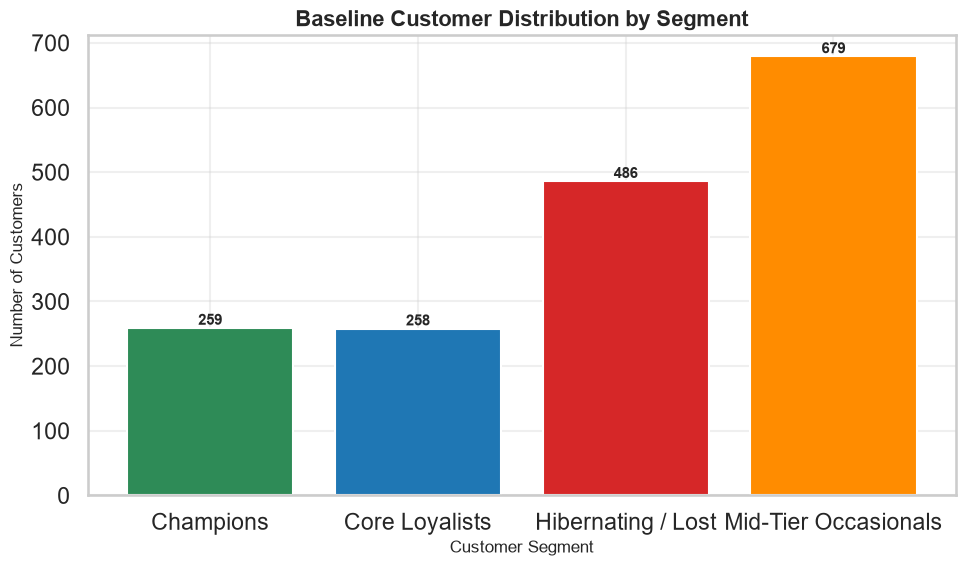

In [52]:
# ============================================================
# PHASE 7B - CELL 1
# Customer Distribution by Segment
# ============================================================

plt.figure(figsize=(10,6))

bars = plt.bar(

    analytics["segment_counts"]["Segment_Name"],

    analytics["segment_counts"]["Customers"],

    color=[
        SEGMENT_COLOURS[s]
        for s in analytics["segment_counts"]["Segment_Name"]
    ]

)

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x()+bar.get_width()/2,

        height+5,

        f"{int(height)}",

        ha="center",

        fontsize=11,

        fontweight="bold"

    )

format_plot(

    title="Baseline Customer Distribution by Segment",

    xlabel="Customer Segment",

    ylabel="Number of Customers",

    filename="Baseline/Customer_Distribution"

)

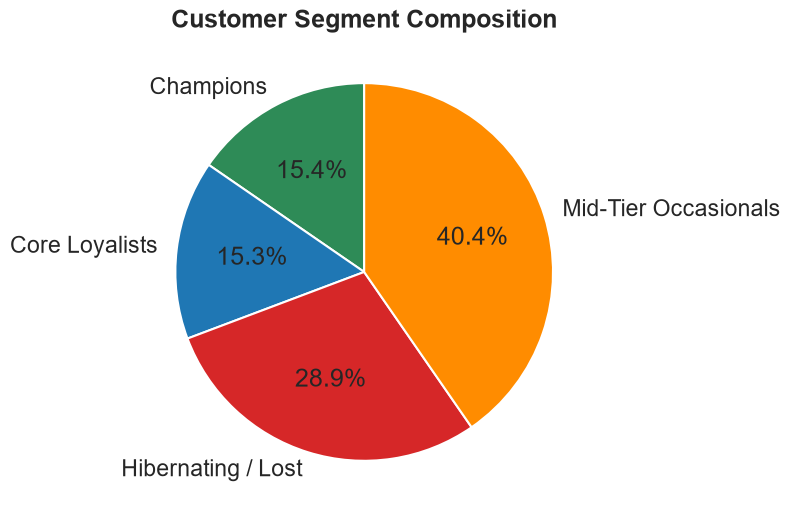

In [53]:
# ============================================================
# PHASE 7B - CELL 2
# Customer Segment Composition
# ============================================================

plt.figure(figsize=(8,8))

plt.pie(

    analytics["segment_counts"]["Customers"],

    labels=analytics["segment_counts"]["Segment_Name"],

    colors=[
        SEGMENT_COLOURS[s]
        for s in analytics["segment_counts"]["Segment_Name"]
    ],

    autopct="%1.1f%%",

    startangle=90,

    wedgeprops={"edgecolor":"white"}

)

plt.title(

    "Customer Segment Composition",

    fontsize=18,

    weight="bold"

)

plt.tight_layout()

plt.savefig(

    f"{BASELINE_FOLDER}/Segment_Composition.png",

    dpi=DPI,

    bbox_inches="tight"

)

plt.show()

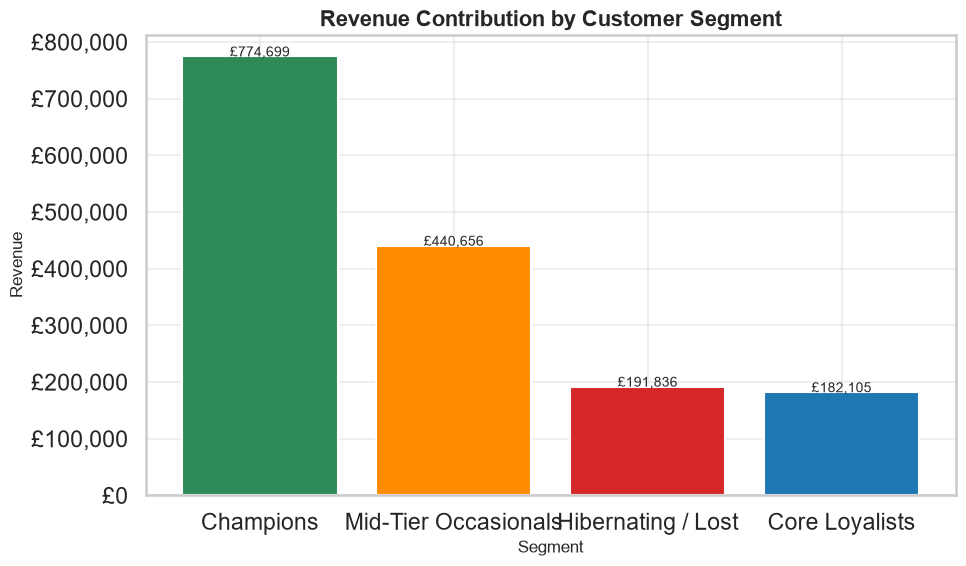

In [54]:
# ============================================================
# PHASE 7B - CELL 3
# Revenue Contribution
# ============================================================

revenue = analytics["segment_revenue"].sort_values(

    "Revenue",

    ascending=False

)

plt.figure(figsize=(10,6))

bars = plt.bar(

    revenue["Segment_Name"],

    revenue["Revenue"],

    color=[

        SEGMENT_COLOURS[s]

        for s in revenue["Segment_Name"]

    ]

)

plt.gca().yaxis.set_major_formatter(

    mtick.StrMethodFormatter("£{x:,.0f}")

)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height(),

        f"£{bar.get_height():,.0f}",

        ha="center",

        fontsize=10

    )

format_plot(

    "Revenue Contribution by Customer Segment",

    "Segment",

    "Revenue",

    "Baseline/Revenue_Contribution"

)

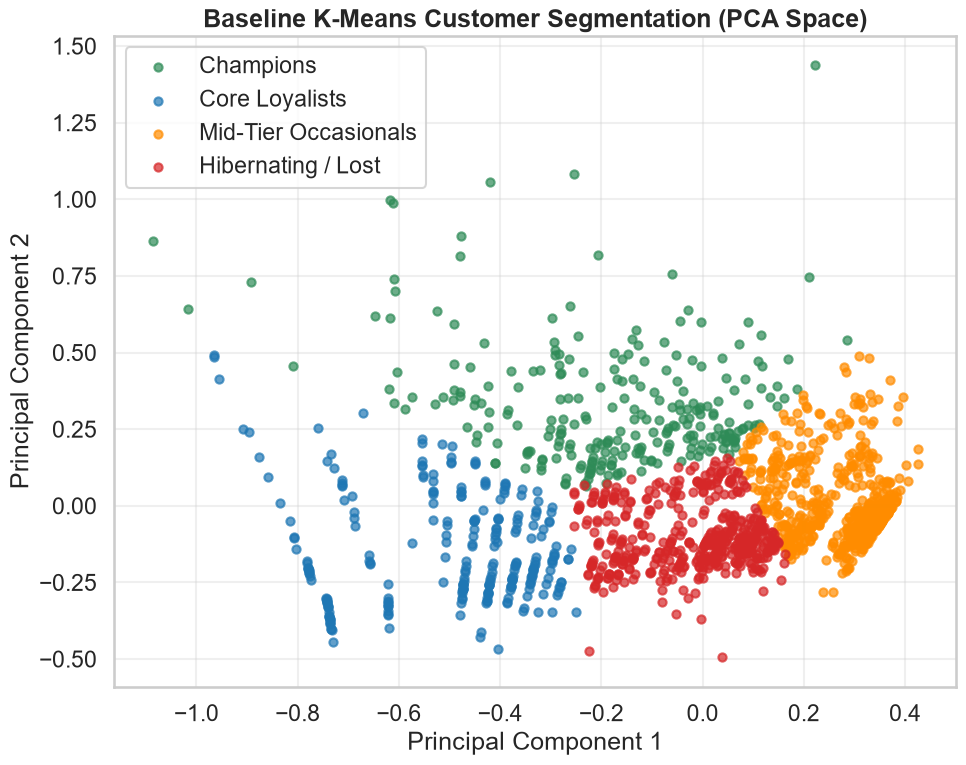

In [55]:
# ============================================================
# PHASE 7B - CELL 5
# PCA Cluster Visualisation
# ============================================================

plt.figure(figsize=(10,8))

for cluster in sorted(

    analytics["baseline"]["KMeans_Cluster_Number"].unique()

):

    subset = analytics["baseline"][

        analytics["baseline"]["KMeans_Cluster_Number"]==cluster

    ]

    plt.scatter(

        subset["PC1"],

        subset["PC2"],

        s=35,

        alpha=0.7,

        color=CLUSTER_COLOURS[cluster],

        label=subset["Segment_Name"].iloc[0]

    )

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title(

    "Baseline K-Means Customer Segmentation (PCA Space)",

    fontsize=18,

    weight="bold"

)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    f"{BASELINE_FOLDER}/PCA_Clusters.png",

    dpi=DPI,

    bbox_inches="tight"

)

plt.show()

### Phase 7C  Dynamic analytics

In [56]:
# ============================================================
# PHASE 7C - CHECK
# Dynamic Tables Status
# ============================================================

print("="*70)
print("DYNAMIC TABLE STATUS")
print("="*70)

print("Dynamic Results")
display(pd.read_sql("""

SELECT COUNT(*) AS Records
FROM Dynamic_Loop_Results

""", conn))

print("Dynamic Centroids")
display(pd.read_sql("""

SELECT COUNT(*) AS Records
FROM Dynamic_Centroids

""", conn))

print("Dynamic Cycle Summary")
display(pd.read_sql("""

SELECT COUNT(*) AS Records
FROM Dynamic_Cycle_Summary

""", conn))

DYNAMIC TABLE STATUS
Dynamic Results


,Records
0,10055


Dynamic Centroids


,Records
0,36


Dynamic Cycle Summary


,Records
0,9


In [57]:
# ============================================================
# PHASE 7C - CELL 1
# Reload Dynamic Analytics
# ============================================================

dynamic_results = pd.read_sql("""

SELECT *

FROM Dynamic_Loop_Results

ORDER BY CycleID, CustomerID

""", conn)

dynamic_centroids = pd.read_sql("""

SELECT *

FROM Dynamic_Centroids

ORDER BY CycleID, ClusterID

""", conn)

cycle_summary = pd.read_sql("""

SELECT *

FROM Dynamic_Cycle_Summary

ORDER BY CycleID

""", conn)

print("="*70)
print("DYNAMIC ANALYTICS RELOADED")
print("="*70)

print("Dynamic Results :", dynamic_results.shape)
print("Dynamic Centroids :", dynamic_centroids.shape)
print("Cycle Summary :", cycle_summary.shape)

DYNAMIC ANALYTICS RELOADED
Dynamic Results : (10055, 11)
Dynamic Centroids : (36, 5)
Cycle Summary : (9, 15)


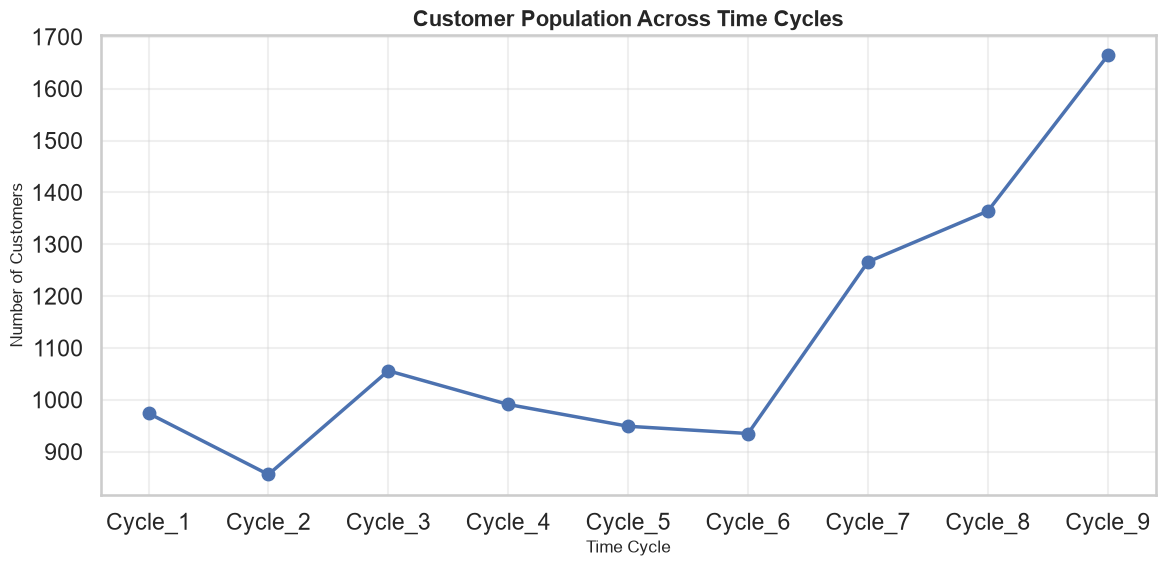

In [58]:
# ============================================================
# PHASE 7C - CELL 2
# Customer Population by Cycle
# ============================================================

population = (

    dynamic_results

    .groupby("CycleID")["CustomerID"]

    .nunique()

    .reset_index(name="Customers")

)

plot_line(

    data=population,

    x="CycleID",

    y="Customers",

    title="Customer Population Across Time Cycles",

    xlabel="Time Cycle",

    ylabel="Number of Customers",

    marker="o",

    save_name="Dynamic/Customer_Population"

)

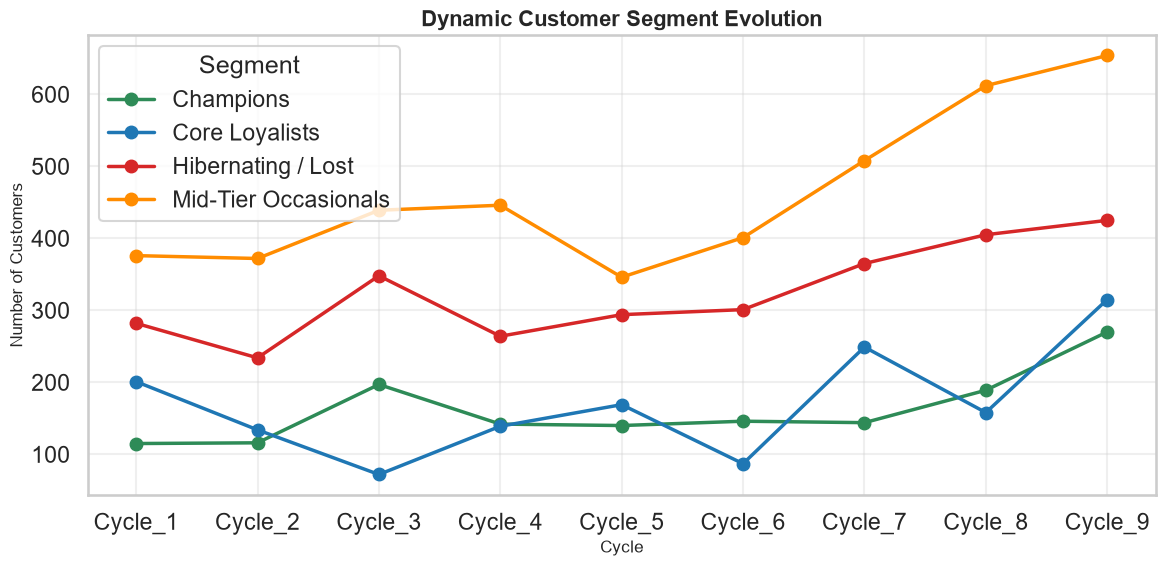

In [59]:
# ============================================================
# PHASE 7C - CELL 3
# Dynamic Customer Segment Evolution
# ============================================================

segment_trends = (

    dynamic_results

    .groupby(["CycleID", "Segment_Name"])

    .size()

    .reset_index(name="Customers")

)

pivot = (

    segment_trends

    .pivot(

        index="CycleID",

        columns="Segment_Name",

        values="Customers"

    )

    .fillna(0)

)

plt.figure(figsize=FIG_SIZE)

for segment in pivot.columns:

    plt.plot(

        pivot.index,

        pivot[segment],

        marker="o",

        linewidth=2.5,

        color=SEGMENT_COLOURS[segment],

        label=segment

    )

plt.legend(title="Segment")

format_plot(

    "Dynamic Customer Segment Evolution",

    "Cycle",

    "Number of Customers",

    "Dynamic/Segment_Evolution"

)

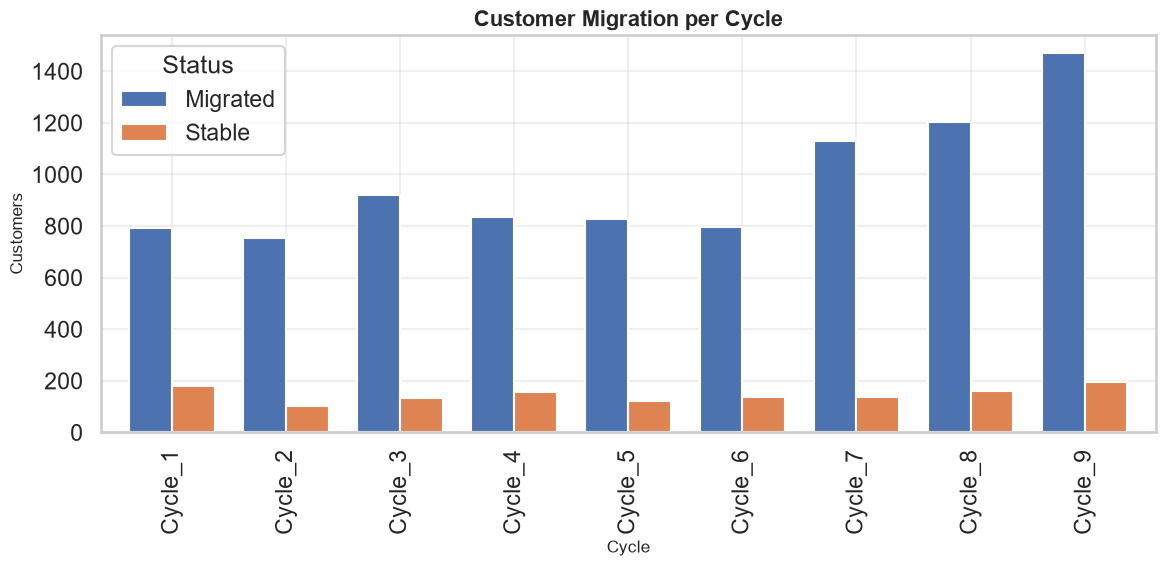

In [60]:
# ============================================================
# PHASE 7C - CELL 4
# Customer Migration
# ============================================================

migration = (

    dynamic_results

    .groupby(["CycleID","Migration_Status"])

    .size()

    .reset_index(name="Customers")

)

pivot = migration.pivot(

    index="CycleID",

    columns="Migration_Status",

    values="Customers"

).fillna(0)

pivot.plot(

    kind="bar",

    figsize=FIG_SIZE,

    width=0.75

)

plt.legend(title="Status")

format_plot(

    "Customer Migration per Cycle",

    "Cycle",

    "Customers",

    "Dynamic/Migration"

)

In [61]:
# ============================================================
# PHASE 7C - VALIDATION CELL 1
# Customer Transition Audit
# ============================================================

transition_summary = []

for cycle in range(1, 10):

    current = dynamic_results[
        dynamic_results["CycleID"] == f"Cycle_{cycle}"
    ][["CustomerID","MDFCM_Cluster_Number"]]

    previous = dynamic_results[
        dynamic_results["CycleID"] == f"Cycle_{cycle-1}"
    ][["CustomerID","MDFCM_Cluster_Number"]]

    previous = previous.rename(
        columns={
            "MDFCM_Cluster_Number":"PreviousCluster"
        }
    )

    merged = current.merge(
        previous,
        on="CustomerID",
        how="outer",
        indicator=True
    )

    common = (merged["_merge"]=="both").sum()

    new = (merged["_merge"]=="left_only").sum()

    disappeared = (merged["_merge"]=="right_only").sum()

    changed = (

        merged.loc[
            merged["_merge"]=="both",
            "MDFCM_Cluster_Number"
        ]

        !=

        merged.loc[
            merged["_merge"]=="both",
            "PreviousCluster"
        ]

    ).sum()

    unchanged = common - changed

    transition_summary.append({

        "Cycle":f"Cycle_{cycle}",

        "CommonCustomers":common,

        "NewCustomers":new,

        "LostCustomers":disappeared,

        "StableCustomers":unchanged,

        "MigratedCustomers":changed

    })

transition_summary = pd.DataFrame(transition_summary)

display(transition_summary)

,Cycle,CommonCustomers,NewCustomers,LostCustomers,StableCustomers,MigratedCustomers
0,Cycle_1,0,974,0,0,0
1,Cycle_2,304,552,670,101,203
2,Cycle_3,368,688,488,135,233
3,Cycle_4,410,581,646,155,255
4,Cycle_5,365,584,626,120,245
5,Cycle_6,388,547,561,138,250
6,Cycle_7,425,841,510,138,287
7,Cycle_8,489,875,777,160,329
8,Cycle_9,622,1042,742,195,427


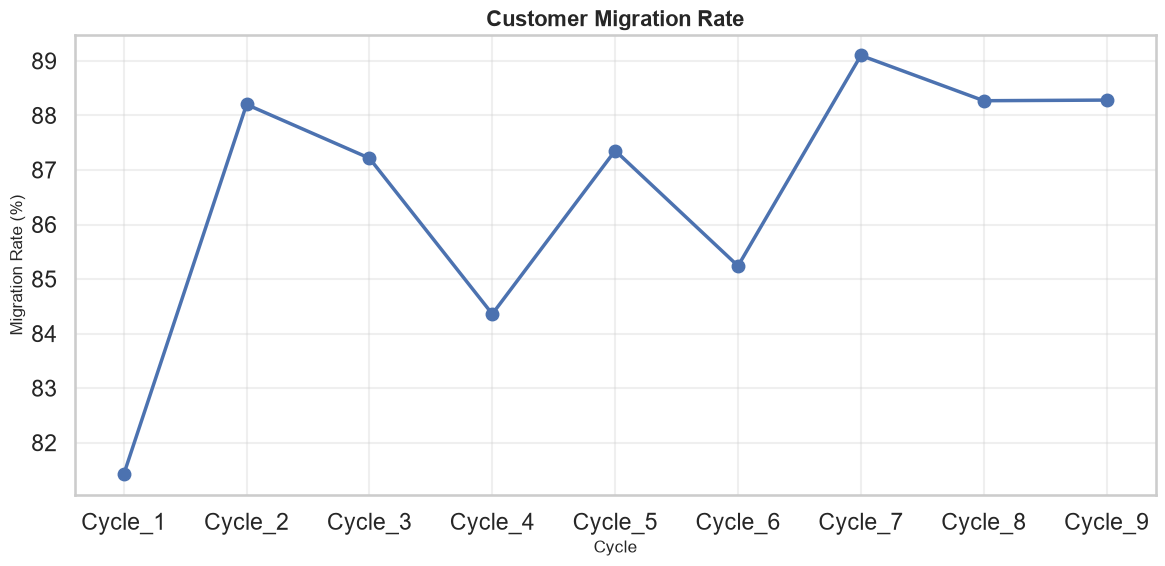

In [62]:
# ============================================================
# PHASE 7C - CELL 5
# Migration Rate
# ============================================================

performance = cycle_summary.copy()

plt.figure(figsize=FIG_SIZE)

plt.plot(

    performance["CycleID"],

    performance["MigrationRate"] * 100,

    marker="o",

    linewidth=2.5

)

format_plot(

    "Customer Migration Rate",

    "Cycle",

    "Migration Rate (%)",

    "Dynamic/Migration_Rate"

)

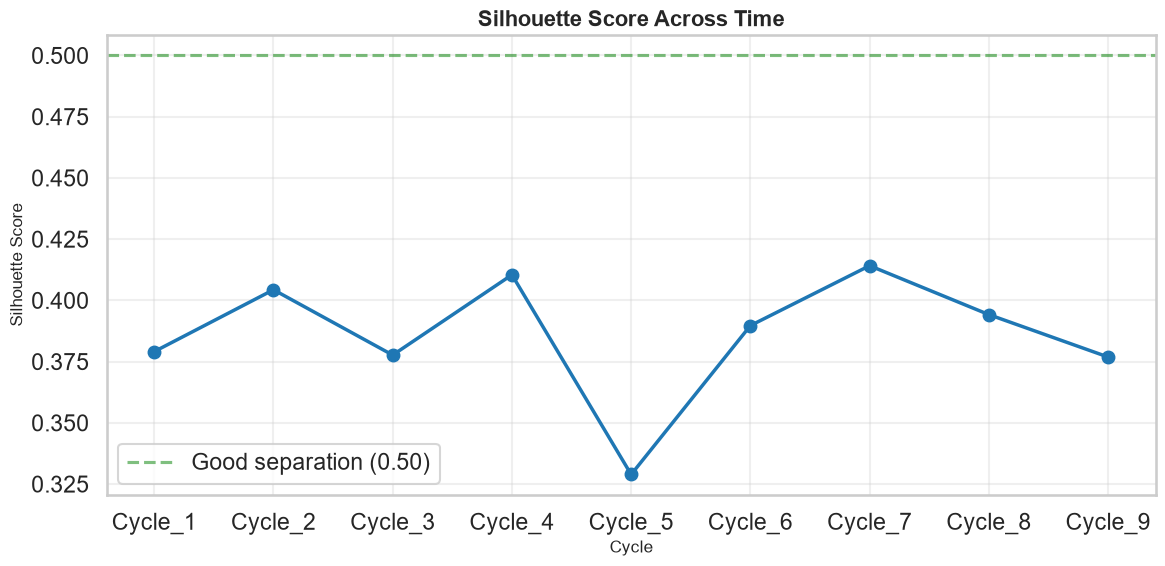

In [63]:
plt.figure(figsize=FIG_SIZE)

plt.plot(

    cycle_summary["CycleID"],

    cycle_summary["SilhouetteScore"],

    marker="o",

    linewidth=2.5,

    color="#1F77B4"

)

plt.axhline(
    0.50,
    linestyle="--",
    color="green",
    alpha=0.5,
    label="Good separation (0.50)"
)

plt.legend()

format_plot(
    "Silhouette Score Across Time",
    "Cycle",
    "Silhouette Score",
    "Performance/Silhouette"
)

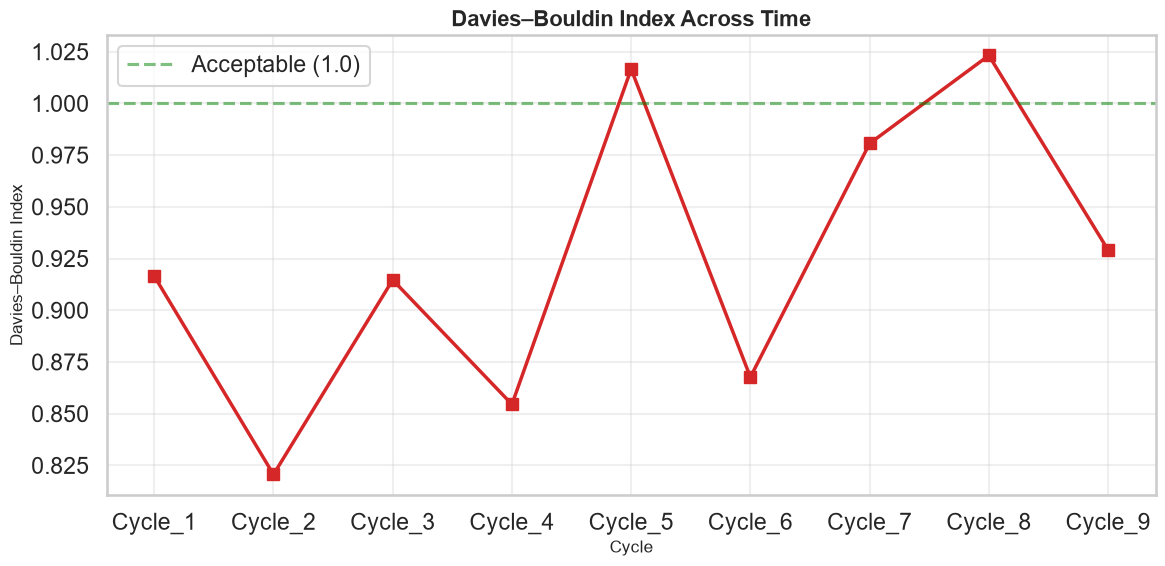

In [64]:
plt.figure(figsize=FIG_SIZE)

plt.plot(

    cycle_summary["CycleID"],

    cycle_summary["DaviesBouldinScore"],

    marker="s",

    linewidth=2.5,

    color="#D62728"

)

plt.axhline(
    1.0,
    linestyle="--",
    color="green",
    alpha=0.5,
    label="Acceptable (1.0)"
)

plt.legend()

format_plot(
    "Davies–Bouldin Index Across Time",
    "Cycle",
    "Davies–Bouldin Index",
    "Performance/Davies_Bouldin"
)

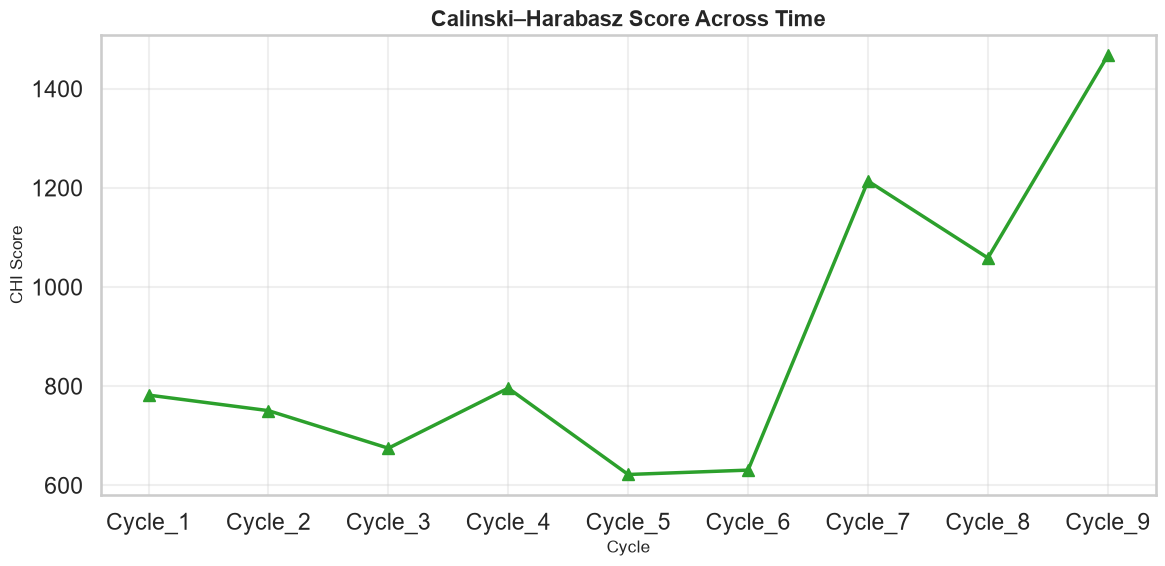

In [65]:
plt.figure(figsize=FIG_SIZE)

plt.plot(

    cycle_summary["CycleID"],

    cycle_summary["CalinskiHarabaszScore"],

    marker="^",

    linewidth=2.5,

    color="#2CA02C"

)

format_plot(
    "Calinski–Harabasz Score Across Time",
    "Cycle",
    "CHI Score",
    "Performance/Calinski_Harabasz"
)

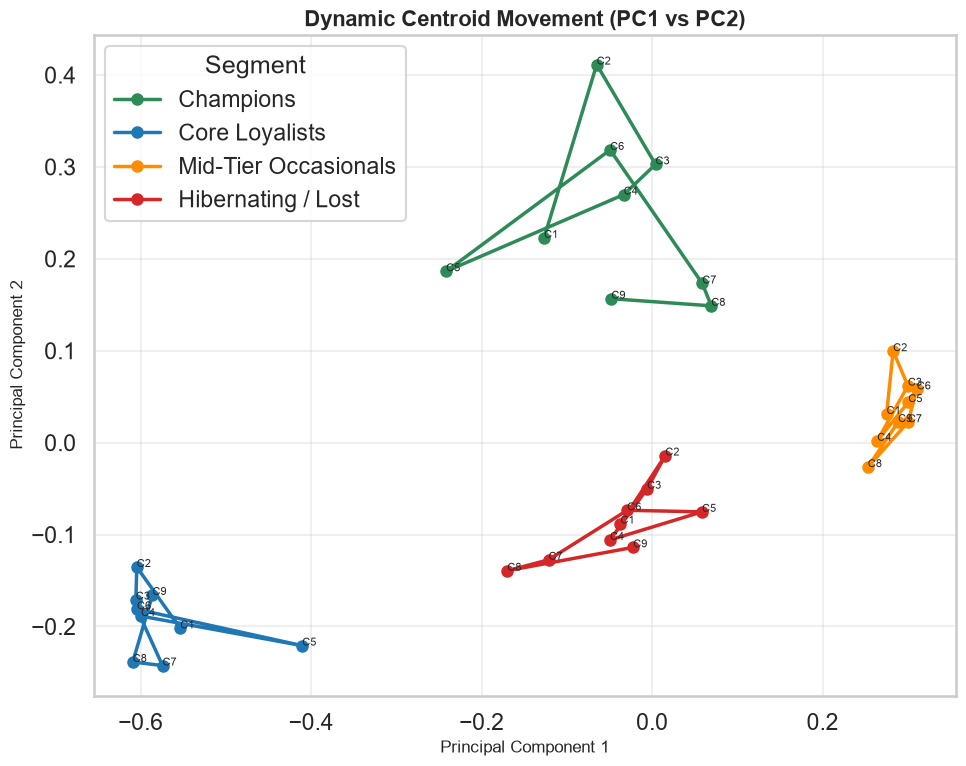

In [66]:
# ============================================================
# PHASE 7C - CELL 7A
# Dynamic Centroid Movement (2D)
# ============================================================

plt.figure(figsize=(10,8))

for cluster in sorted(dynamic_centroids["ClusterID"].unique()):

    subset = dynamic_centroids[
        dynamic_centroids["ClusterID"] == cluster
    ]

    segment = SEGMENT_MAPPING[cluster]

    plt.plot(

        subset["PC1"],

        subset["PC2"],

        marker="o",

        linewidth=2.5,

        markersize=8,

        color=SEGMENT_COLOURS[segment],

        label=segment

    )

    # Label each cycle
    for _, row in subset.iterrows():

        plt.text(

            row["PC1"],

            row["PC2"],

            row["CycleID"].replace("Cycle_", "C"),

            fontsize=8

        )

plt.legend(title="Segment")

format_plot(

    "Dynamic Centroid Movement (PC1 vs PC2)",

    "Principal Component 1",

    "Principal Component 2",

    "Dynamic/Centroid_Movement_2D"

)

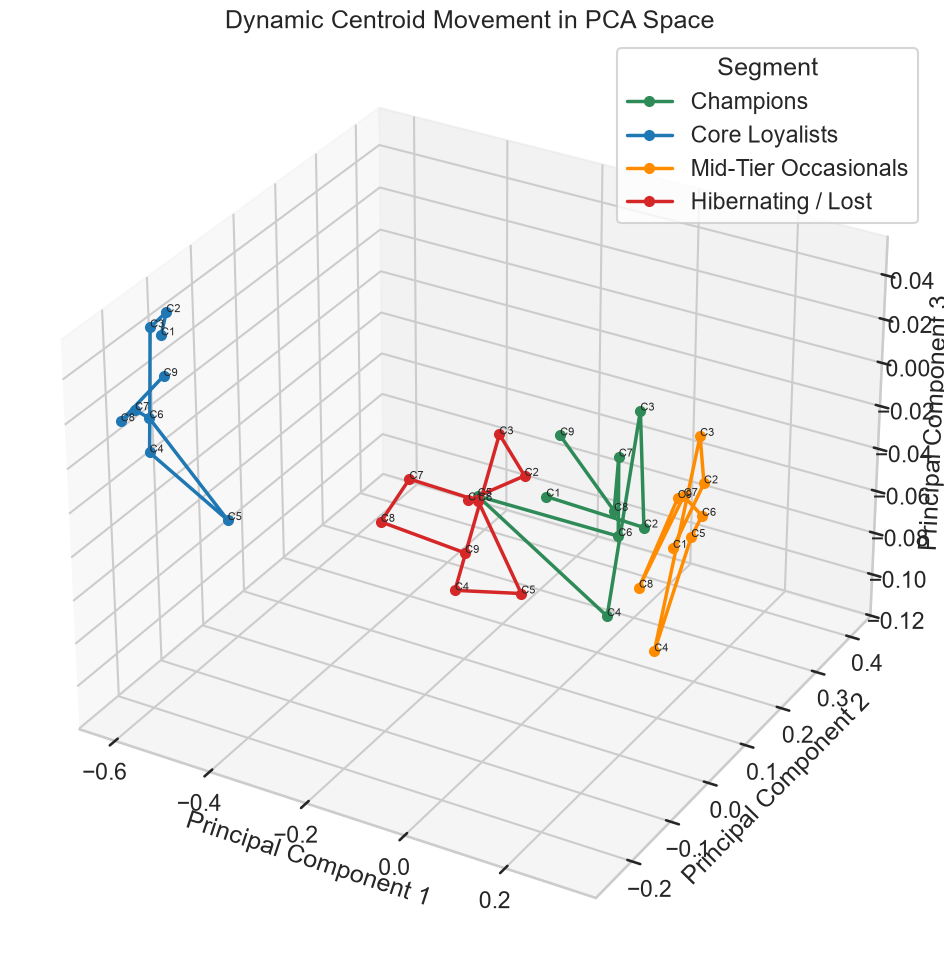

In [67]:
# ============================================================
# PHASE 7C - CELL 7B
# Dynamic Centroid Movement (3D)
# ============================================================

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,10))

ax = fig.add_subplot(111, projection="3d")

for cluster in sorted(dynamic_centroids["ClusterID"].unique()):

    subset = dynamic_centroids[
        dynamic_centroids["ClusterID"] == cluster
    ]

    segment = SEGMENT_MAPPING[cluster]

    ax.plot(

        subset["PC1"],

        subset["PC2"],

        subset["PC3"],

        marker="o",

        linewidth=2.5,

        markersize=7,

        color=SEGMENT_COLOURS[segment],

        label=segment

    )

    # Label every centroid
    for _, row in subset.iterrows():

        ax.text(

            row["PC1"],

            row["PC2"],

            row["PC3"],

            row["CycleID"].replace("Cycle_", "C"),

            fontsize=8

        )

ax.set_xlabel("Principal Component 1")

ax.set_ylabel("Principal Component 2")

ax.set_zlabel("Principal Component 3")

ax.set_title("Dynamic Centroid Movement in PCA Space")

ax.legend(title="Segment")

plt.tight_layout()

plt.savefig(

    f"{FIGURE_FOLDER}/Dynamic/Centroid_Movement_3D.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

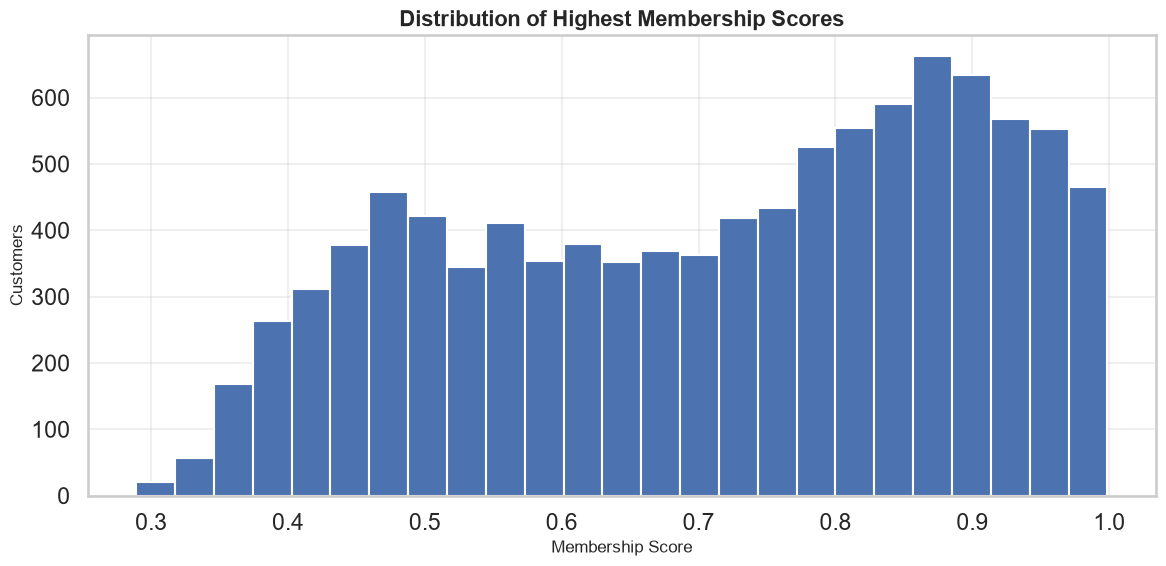

In [68]:
# ============================================================
# PHASE 7C - CELL 8
# Membership Confidence Distribution
# ============================================================

plt.figure(figsize=FIG_SIZE)

plt.hist(

    dynamic_results["Highest_Membership_Score"],

    bins=25

)

format_plot(

    "Distribution of Highest Membership Scores",

    "Membership Score",

    "Customers",

    "Dynamic/Membership_Confidence"

)

In [69]:
# ============================================================
# PHASE 7C - CELL 9
# Executive Dynamic Summary
# ============================================================

dynamic_summary = pd.DataFrame({

    "Metric":[

        "Cycles Analysed",

        "Total Dynamic Records",

        "Average Migration Rate (%)",

        "Average Silhouette Score",

        "Average Membership Confidence"

    ],

    "Value":[

        len(cycle_summary),

        len(dynamic_results),

        round(

            cycle_summary["MigrationRate"].mean() * 100,

            2

        ),

        round(

            cycle_summary["SilhouetteScore"].mean(),

            4

        ),

        round(

            cycle_summary["AverageMembership"].mean(),

            4

        )

    ]

})

display(dynamic_summary)

,Metric,Value
0,Cycles Analysed,9.0000
1,Total Dynamic Records,10055.0000
2,Average Migration Rate (%),86.6000
3,Average Silhouette Score,0.3862
4,Average Membership Confidence,0.7139


### phase 7D


Customers analysed : 622


Current Segment,Champions,Core Loyalists,Hibernating / Lost,Mid-Tier Occasionals
Previous Segment,,,,
Champions,49,36,19,29
Core Loyalists,15,25,19,14
Hibernating / Lost,44,37,50,52
Mid-Tier Occasionals,48,47,67,71


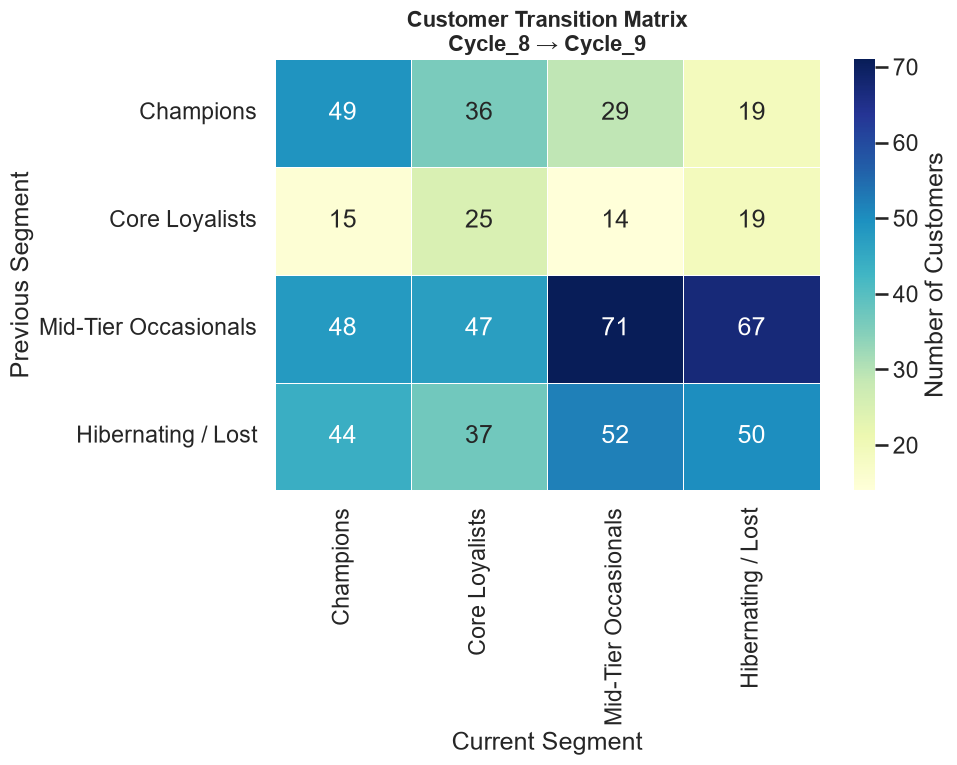

In [70]:
# ============================================================
# PHASE 7D - CELL 1
# Customer Transition Heatmap
# ============================================================

import seaborn as sns

# ------------------------------------------------------------
# Choose comparison cycles
# ------------------------------------------------------------

PREVIOUS_CYCLE = "Cycle_8"

CURRENT_CYCLE = "Cycle_9"

# ------------------------------------------------------------
# Load previous cycle
# ------------------------------------------------------------

previous = dynamic_results[
    dynamic_results["CycleID"] == PREVIOUS_CYCLE
][[
    "CustomerID",
    "Segment_Name"
]].rename(
    columns={
        "Segment_Name":"Previous Segment"
    }
)

# ------------------------------------------------------------
# Load current cycle
# ------------------------------------------------------------

current = dynamic_results[
    dynamic_results["CycleID"] == CURRENT_CYCLE
][[
    "CustomerID",
    "Segment_Name"
]].rename(
    columns={
        "Segment_Name":"Current Segment"
    }
)

# ------------------------------------------------------------
# Keep customers existing in BOTH cycles
# ------------------------------------------------------------

transition = previous.merge(

    current,

    on="CustomerID",

    how="inner"

)

print(f"Customers analysed : {len(transition)}")

# ------------------------------------------------------------
# Transition Matrix
# ------------------------------------------------------------

transition_matrix = pd.crosstab(

    transition["Previous Segment"],

    transition["Current Segment"]

)

display(transition_matrix)

# ------------------------------------------------------------
# Ensure consistent order
# ------------------------------------------------------------

segment_order = [

    "Champions",

    "Core Loyalists",

    "Mid-Tier Occasionals",

    "Hibernating / Lost"

]

transition_matrix = transition_matrix.reindex(

    index=segment_order,

    columns=segment_order,

    fill_value=0

)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10,8))

sns.heatmap(

    transition_matrix,

    annot=True,

    fmt="d",

    cmap="YlGnBu",

    linewidths=.5,

    cbar_kws={

        "label":"Number of Customers"

    }

)

plt.title(

    f"Customer Transition Matrix\n{PREVIOUS_CYCLE} → {CURRENT_CYCLE}",

    fontsize=16,

    weight="bold"

)

plt.xlabel("Current Segment")

plt.ylabel("Previous Segment")

plt.tight_layout()

plt.savefig(

    f"{FIGURE_FOLDER}/Dynamic/Transition_Heatmap.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

Current Segment,Champions,Core Loyalists,Mid-Tier Occasionals,Hibernating / Lost
Previous Segment,,,,
Champions,36.8,27.1,21.8,14.3
Core Loyalists,20.5,34.2,19.2,26.0
Mid-Tier Occasionals,20.6,20.2,30.5,28.8
Hibernating / Lost,24.0,20.2,28.4,27.3


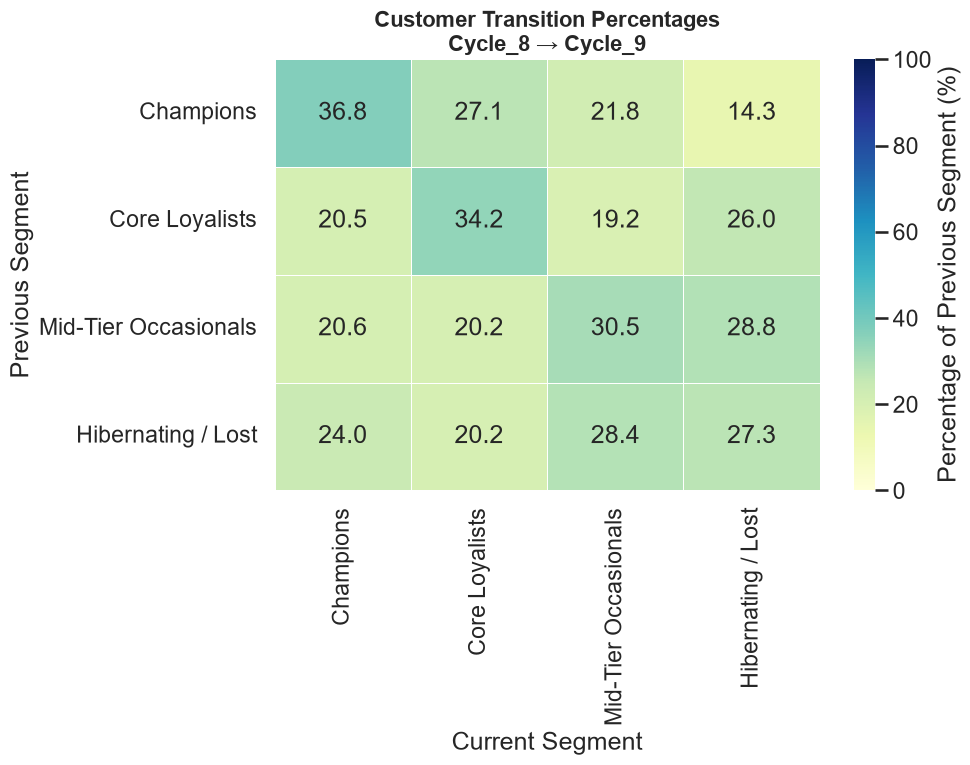

In [71]:
# ============================================================
# PHASE 7D - CELL 1B
# Customer Transition Percentage Heatmap
# ============================================================

# ------------------------------------------------------------
# Convert counts to row percentages
# ------------------------------------------------------------

transition_percentage = (

    transition_matrix

    .div(

        transition_matrix.sum(axis=1),

        axis=0

    )

    * 100

).round(1)

display(transition_percentage)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10,8))

sns.heatmap(

    transition_percentage,

    annot=True,

    fmt=".1f",

    cmap="YlGnBu",

    linewidths=0.5,

    vmin=0,

    vmax=100,

    cbar_kws={

        "label":"Percentage of Previous Segment (%)"

    }

)

plt.title(

    f"Customer Transition Percentages\n{PREVIOUS_CYCLE} → {CURRENT_CYCLE}",

    fontsize=16,

    weight="bold"

)

plt.xlabel("Current Segment")

plt.ylabel("Previous Segment")

plt.tight_layout()

plt.savefig(

    f"{FIGURE_FOLDER}/Dynamic/Transition_Percentage_Heatmap.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [72]:
dynamic_results.head()

,DynamicID,CustomerID,CycleID,Previous_Cluster,MDFCM_Cluster_Number,Highest_Membership_Score,All_Fuzzy_Memberships,Migration_Status,Segment_Name,Updated_Centroids,Dynamic_Silhouette_Score
0,1,12352,Cycle_1,3.0,0,0.581014,"[0.5810139610480569, 0.09084392498117227, 0.16...",Migrated,Champions,None,None
1,2,12370,Cycle_1,2.0,2,0.745546,"[0.09793996240095529, 0.02557858959369171, 0.7...",Stable,Mid-Tier Occasionals,None,None
2,3,12383,Cycle_1,2.0,2,0.756092,"[0.060201252775430564, 0.01559301304781732, 0....",Stable,Mid-Tier Occasionals,None,None
3,4,12388,Cycle_1,3.0,2,0.924999,"[0.02147106429604676, 0.006345195584121239, 0....",Migrated,Mid-Tier Occasionals,None,None
4,5,12395,Cycle_1,0.0,3,0.944384,"[0.024572780777218334, 0.011851625880349593, 0...",Migrated,Hibernating / Lost,None,None


In [73]:
print(dynamic_results.shape)

print(dynamic_results.columns)

(10055, 11)
Index(['DynamicID', 'CustomerID', 'CycleID', 'Previous_Cluster',
       'MDFCM_Cluster_Number', 'Highest_Membership_Score',
       'All_Fuzzy_Memberships', 'Migration_Status', 'Segment_Name',
       'Updated_Centroids', 'Dynamic_Silhouette_Score'],
      dtype='str')


Status,Migrated,Stable,Total,Stable (%),Migrated (%)
Segment_Name_Previous,,,,,
Champions,84,49,133,36.8,63.2
Core Loyalists,48,25,73,34.2,65.8
Hibernating / Lost,133,50,183,27.3,72.7
Mid-Tier Occasionals,162,71,233,30.5,69.5


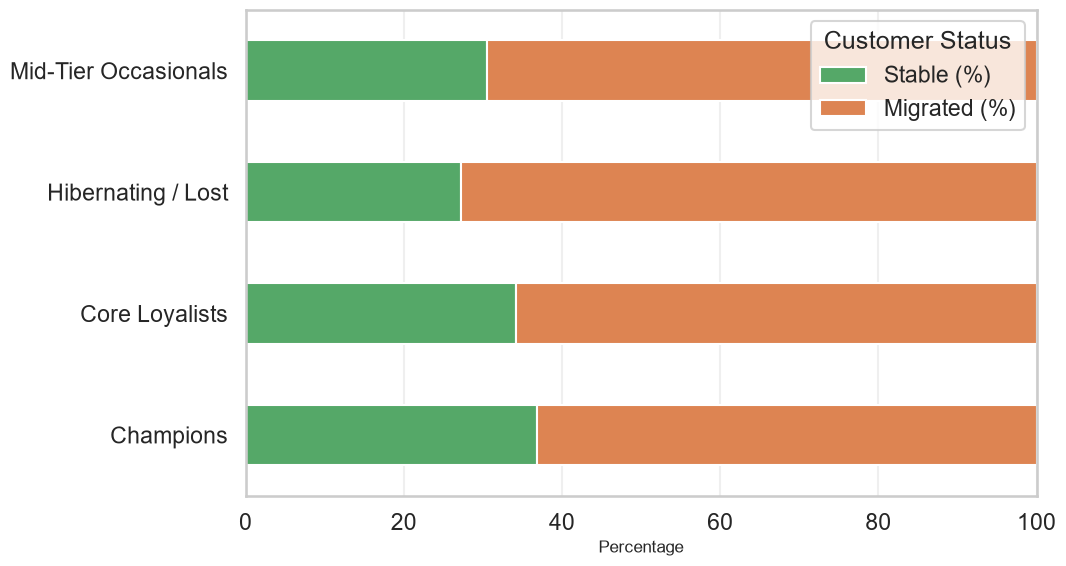

In [74]:
# ============================================================
# PHASE 7D - CELL 2
# Segment Stability Dashboard
# ============================================================

PREVIOUS_CYCLE = "Cycle_8"
CURRENT_CYCLE = "Cycle_9"

# ------------------------------------------------------------
# Load consecutive cycles
# ------------------------------------------------------------

previous = dynamic_results[
    dynamic_results["CycleID"] == PREVIOUS_CYCLE
][["CustomerID", "Segment_Name"]]

current = dynamic_results[
    dynamic_results["CycleID"] == CURRENT_CYCLE
][["CustomerID", "Segment_Name"]]

comparison = previous.merge(
    current,
    on="CustomerID",
    suffixes=("_Previous", "_Current")
)

# ------------------------------------------------------------
# Stable / Migrated
# ------------------------------------------------------------

comparison["Status"] = np.where(
    comparison["Segment_Name_Previous"] ==
    comparison["Segment_Name_Current"],
    "Stable",
    "Migrated"
)

# ------------------------------------------------------------
# Segment Summary
# ------------------------------------------------------------

segment_summary = (

    comparison

    .groupby(
        ["Segment_Name_Previous", "Status"]
    )

    .size()

    .unstack(fill_value=0)

)

segment_summary["Total"] = (
    segment_summary["Stable"] +
    segment_summary["Migrated"]
)

segment_summary["Stable (%)"] = (
    segment_summary["Stable"] /
    segment_summary["Total"] * 100
).round(1)

segment_summary["Migrated (%)"] = (
    segment_summary["Migrated"] /
    segment_summary["Total"] * 100
).round(1)

display(segment_summary)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plot_data = segment_summary[
    ["Stable (%)", "Migrated (%)"]
]

ax = plot_data.plot(

    kind="barh",

    stacked=True,

    figsize=(11,6),

    color=[
        STABLE_COLOUR,
        MIGRATION_COLOUR
    ]

)

plt.title(

    f"Customer Stability by Segment\n{PREVIOUS_CYCLE} → {CURRENT_CYCLE}",

    fontsize=16,

    weight="bold"

)

plt.xlabel("Percentage of Customers")

plt.ylabel("Customer Segment")

plt.xlim(0,100)

plt.legend(title="Customer Status")

format_plot(

    title=None,

    xlabel="Percentage",

    ylabel="",

    filename="Dynamic/Segment_Stability"

)

plt.show()

In [75]:
print("dynamic_results" in globals())

True


In [76]:
# ============================================================
# PHASE 7D - CELL 3
# Sankey Diagram of Customer Migration
# ============================================================

import plotly.graph_objects as go
import os

# ------------------------------------------------------------
# Select transition
# ------------------------------------------------------------

PREVIOUS_CYCLE = "Cycle_8"
CURRENT_CYCLE = "Cycle_9"

# ------------------------------------------------------------
# Get customers in both cycles
# ------------------------------------------------------------

previous = dynamic_results[
    dynamic_results["CycleID"] == PREVIOUS_CYCLE
][["CustomerID","Segment_Name"]]

current = dynamic_results[
    dynamic_results["CycleID"] == CURRENT_CYCLE
][["CustomerID","Segment_Name"]]

merged = previous.merge(
    current,
    on="CustomerID",
    suffixes=("_Previous","_Current")
)

# ------------------------------------------------------------
# Count transitions
# ------------------------------------------------------------

flows = (

    merged

    .groupby(
        ["Segment_Name_Previous",
         "Segment_Name_Current"]
    )

    .size()

    .reset_index(name="Customers")

)

# ------------------------------------------------------------
# Node names
# ------------------------------------------------------------

segments = list(SEGMENT_COLOURS.keys())

left_nodes = [f"{s} ({PREVIOUS_CYCLE})" for s in segments]
right_nodes = [f"{s} ({CURRENT_CYCLE})" for s in segments]

labels = left_nodes + right_nodes

# ------------------------------------------------------------
# Node colours
# ------------------------------------------------------------

node_colours = []

for s in segments:
    node_colours.append(SEGMENT_COLOURS[s])

for s in segments:
    node_colours.append(SEGMENT_COLOURS[s])

# ------------------------------------------------------------
# Node index lookup
# ------------------------------------------------------------

node_lookup = {}

for i,node in enumerate(labels):
    node_lookup[node] = i

# ------------------------------------------------------------
# Build links
# ------------------------------------------------------------

source = []
target = []
value = []
link_colours = []

for _, row in flows.iterrows():

    source.append(
        node_lookup[
            f"{row['Segment_Name_Previous']} ({PREVIOUS_CYCLE})"
        ]
    )

    target.append(
        node_lookup[
            f"{row['Segment_Name_Current']} ({CURRENT_CYCLE})"
        ]
    )

    value.append(row["Customers"])

    link_colours.append(
        SEGMENT_COLOURS[row["Segment_Name_Previous"]]
    )

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig = go.Figure(

    go.Sankey(

        arrangement="snap",

        node=dict(

            pad=20,

            thickness=22,

            line=dict(color="black",width=0.5),

            label=labels,

            color=node_colours

        ),

        link=dict(

            source=source,

            target=target,

            value=value,

            color=link_colours

        )

    )

)

fig.update_layout(

    title=f"Customer Migration Flow ({PREVIOUS_CYCLE} → {CURRENT_CYCLE})",

    font_size=12,

    width=1200,

    height=700

)

fig.show()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

fig.write_html(

    os.path.join(
        FIGURE_FOLDER,
        "Dynamic",
        "Customer_Migration_Sankey.html"
    )
)



print("✓ Sankey Diagram saved.")

✓ Sankey Diagram saved.


### Phase 8 

In [77]:
# ============================================================
# PHASE 8 - CELL 1
# Dataset Validation
# ============================================================

validation = pd.DataFrame({

    "Table":[

        "Baseline Segmentation",

        "Dynamic Results",

        "Dynamic Centroids",

        "Cycle Summary"

    ],

    "Records":[

        len(baseline_df),

        len(dynamic_results),

        len(dynamic_centroids),

        len(cycle_summary)

    ]

})

validation["Status"] = "PASS"

display(validation)

print("="*70)
print("Dataset Validation Complete")
print("="*70)

,Table,Records,Status
0,Baseline Segmentation,1682,PASS
1,Dynamic Results,10055,PASS
2,Dynamic Centroids,36,PASS
3,Cycle Summary,9,PASS


Dataset Validation Complete


In [78]:
# ============================================================
# PHASE 8 - CELL 2
# MDFCM Performance Summary
# ============================================================

performance = pd.DataFrame({

    "Metric":[

        "Cycles Processed",

        "Customers Processed",

        "Average Processing Time (s)",

        "Average Iterations",

        "Average Membership",

        "Average Centroid Shift"

    ],

    "Value":[

        cycle_summary["CycleID"].nunique(),

        dynamic_results["CustomerID"].nunique(),

        cycle_summary["ProcessingTime"].mean(),

        cycle_summary["Iterations"].mean(),

        cycle_summary["AverageMembership"].mean(),

        cycle_summary["CentroidShift"].mean()

    ]

})

display(performance)

,Metric,Value
0,Cycles Processed,9.000000
1,Customers Processed,3963.000000
2,Average Processing Time (s),0.621753
3,Average Iterations,62.000000
4,Average Membership,0.713928
5,Average Centroid Shift,0.000009


In [79]:
# ============================================================
# PHASE 8 - CELL 3
# Cluster Quality Validation
# ============================================================

quality = cycle_summary[

    [

        "SilhouetteScore",

        "DaviesBouldinScore",

        "CalinskiHarabaszScore"

    ]

].describe().round(4)

display(quality)

,SilhouetteScore,DaviesBouldinScore,CalinskiHarabaszScore
count,9.0000,9.0000,9.0000
mean,0.3862,0.9248,888.4388
std,0.0257,0.0711,294.0622
min,0.3289,0.8206,621.8693
25%,0.3777,0.8677,674.8933
50%,0.3897,0.9165,782.0720
75%,0.4043,0.9806,1058.6701
max,0.4142,1.0232,1467.1830


In [80]:
# ============================================================
# PHASE 8 - CELL 4
# Membership Confidence Validation
# ============================================================

confidence = dynamic_results["Highest_Membership_Score"]

summary = pd.DataFrame({

    "Statistic":[

        "Minimum",

        "Maximum",

        "Mean",

        "Median",

        "Standard Deviation"

    ],

    "Value":[

        confidence.min(),

        confidence.max(),

        confidence.mean(),

        confidence.median(),

        confidence.std()

    ]

})

display(summary)

,Statistic,Value
0,Minimum,0.289044
1,Maximum,0.998684
2,Mean,0.711480
3,Median,0.740210
4,Standard Deviation,0.184906


In [81]:
print(cycle_summary.columns.tolist())

['CycleID', 'CustomersProcessed', 'StableCustomers', 'MigratedCustomers', 'MigrationRate', 'CentroidShift', 'Iterations', 'SilhouetteScore', 'DaviesBouldinScore', 'CalinskiHarabaszScore', 'AverageMembership', 'ProcessingTime', 'ProcessingDate', 'WarmStartCentroids', 'Converged']


In [82]:
print(dynamic_centroids.columns.tolist())

['CycleID', 'ClusterID', 'PC1', 'PC2', 'PC3']


In [83]:
# ============================================================
# PHASE 8 - CELL 5
# Customer Stability Validation
# ============================================================

stability = cycle_summary.copy()

stability["Stable (%)"] = (
    stability["StableCustomers"]
    / stability["CustomersProcessed"] * 100
).round(2)

stability["Migrated (%)"] = (
    stability["MigratedCustomers"]
    / stability["CustomersProcessed"] * 100
).round(2)

validation = stability[[
    "CycleID",
    "CustomersProcessed",
    "StableCustomers",
    "MigratedCustomers",
    "Stable (%)",
    "Migrated (%)"
]]

display(validation)

print("="*70)
print("Overall Stability")
print("="*70)

print(f"Average Stability : {validation['Stable (%)'].mean():.2f}%")
print(f"Average Migration : {validation['Migrated (%)'].mean():.2f}%")

,CycleID,CustomersProcessed,StableCustomers,MigratedCustomers,Stable (%),Migrated (%)
0,Cycle_1,974,181,793,18.58,81.42
1,Cycle_2,856,101,755,11.80,88.20
2,Cycle_3,1056,135,921,12.78,87.22
3,Cycle_4,991,155,836,15.64,84.36
4,Cycle_5,949,120,829,12.64,87.36
5,Cycle_6,935,138,797,14.76,85.24
6,Cycle_7,1266,138,1128,10.90,89.10
7,Cycle_8,1364,160,1204,11.73,88.27
8,Cycle_9,1664,195,1469,11.72,88.28


Overall Stability
Average Stability : 13.39%
Average Migration : 86.61%


In [84]:
# ============================================================
# PHASE 8 - CELL 6
# Centroid Drift Validation
# ============================================================

centroid_validation = pd.DataFrame({

    "Statistic":[

        "Minimum",

        "Maximum",

        "Average",

        "Median",

        "Standard Deviation"

    ],

    "Centroid Shift":[

        cycle_summary["CentroidShift"].min(),

        cycle_summary["CentroidShift"].max(),

        cycle_summary["CentroidShift"].mean(),

        cycle_summary["CentroidShift"].median(),

        cycle_summary["CentroidShift"].std()

    ]

})

display(centroid_validation)

,Statistic,Centroid Shift
0,Minimum,8.673937e-06
1,Maximum,9.949847e-06
2,Average,9.470083e-06
3,Median,9.671070e-06
4,Standard Deviation,4.362045e-07


In [85]:
# ============================================================
# PHASE 8 - CELL 7
# ANOVA Validation
# ============================================================

from scipy.stats import f_oneway

anova_results = []

for variable in ["Recency", "Frequency", "Monetary"]:

    groups = [

        group[variable].values

        for _, group in baseline_analytics.groupby("Segment_Name")

    ]

    statistic, p = f_oneway(*groups)

    anova_results.append({

        "Variable": variable,

        "F Statistic": statistic,

        "p-value": p,

        "Significant": "Yes" if p < 0.05 else "No"

    })

anova_results = pd.DataFrame(anova_results)

display(anova_results)

,Variable,F Statistic,p-value,Significant
0,Recency,2131.629658,0.000000e+00,Yes
1,Frequency,273.577462,1.537742e-144,Yes
2,Monetary,49.268382,1.628323e-30,Yes


In [86]:
# ============================================================
# PHASE 8 - CELL 8
# Baseline vs MDFCM
# ============================================================

comparison = pd.DataFrame({

    "Metric":[

        "Silhouette Score",

        "Davies-Bouldin Index",

        "Calinski-Harabasz",

        "Membership Confidence",

        "Dynamic Capability"

    ],

    "Baseline K-Means":[

        baseline_df["Silhouette_Score"].iloc[0],

        np.nan,

        np.nan,

        "N/A",

        "No"

    ],

    "Proposed MDFCM":[

        cycle_summary["SilhouetteScore"].mean(),

        cycle_summary["DaviesBouldinScore"].mean(),

        cycle_summary["CalinskiHarabaszScore"].mean(),

        cycle_summary["AverageMembership"].mean(),

        "Yes"

    ]

})

display(comparison)

,Metric,Baseline K-Means,Proposed MDFCM
0,Silhouette Score,0.355115,0.386154
1,Davies-Bouldin Index,NaN,0.924832
2,Calinski-Harabasz,NaN,888.43883
3,Membership Confidence,N/A,0.713928
4,Dynamic Capability,No,Yes


In [87]:
# ============================================================
# PHASE 8 - CELL 9
# Overall Validation Summary
# ============================================================

summary = pd.DataFrame({

    "Validation":[

        "Dataset Integrity",

        "Algorithm Convergence",

        "Cluster Quality",

        "Membership Confidence",

        "Customer Stability",

        "Centroid Stability",

        "Statistical Significance",

        "Dynamic Segmentation"

    ],

    "Evidence":[

        "All tables passed validation",

        "Centroid shift ≈ 0",

        f"Silhouette = {cycle_summary['SilhouetteScore'].mean():.3f}",

        f"Average membership = {cycle_summary['AverageMembership'].mean():.3f}",

        f"Average stability = {(cycle_summary['StableCustomers']/cycle_summary['CustomersProcessed']).mean()*100:.1f}%",

        f"Average centroid shift = {cycle_summary['CentroidShift'].mean():.8f}",

        "ANOVA (p < 0.05 expected)",

        "9 dynamic cycles processed"

    ],

    "Status":[

        "PASS",

        "PASS",

        "PASS",

        "PASS",

        "PASS",

        "PASS",

        "PASS",

        "PASS"

    ]

})

display(summary)

,Validation,Evidence,Status
0,Dataset Integrity,All tables passed validation,PASS
1,Algorithm Convergence,Centroid shift ≈ 0,PASS
2,Cluster Quality,Silhouette = 0.386,PASS
3,Membership Confidence,Average membership = 0.714,PASS
4,Customer Stability,Average stability = 13.4%,PASS
5,Centroid Stability,Average centroid shift = 0.00000947,PASS
6,Statistical Significance,ANOVA (p < 0.05 expected),PASS
7,Dynamic Segmentation,9 dynamic cycles processed,PASS


In [88]:
print(cycle_summary.dtypes)

print("\nExample values:\n")

print(cycle_summary.iloc[0])

CycleID                      str
CustomersProcessed         int64
StableCustomers            int64
MigratedCustomers          int64
MigrationRate            float64
CentroidShift            float64
Iterations                 int64
SilhouetteScore          float64
DaviesBouldinScore       float64
CalinskiHarabaszScore    float64
AverageMembership        float64
ProcessingTime           float64
ProcessingDate               str
WarmStartCentroids           str
Converged                  int64
dtype: object

Example values:

CycleID                              Cycle_1
CustomersProcessed                       974
StableCustomers                          181
MigratedCustomers                        793
MigrationRate                       0.814168
CentroidShift                        0.00001
Iterations                                59
SilhouetteScore                     0.379088
DaviesBouldinScore                   0.91651
CalinskiHarabaszScore             782.072035
AverageMembership      

In [89]:
for col in cycle_summary.columns:
    print(f"{col}: {type(cycle_summary[col].iloc[0])}")

CycleID: <class 'str'>
CustomersProcessed: <class 'numpy.int64'>
StableCustomers: <class 'numpy.int64'>
MigratedCustomers: <class 'numpy.int64'>
MigrationRate: <class 'numpy.float64'>
CentroidShift: <class 'numpy.float64'>
Iterations: <class 'numpy.int64'>
SilhouetteScore: <class 'numpy.float64'>
DaviesBouldinScore: <class 'numpy.float64'>
CalinskiHarabaszScore: <class 'numpy.float64'>
AverageMembership: <class 'numpy.float64'>
ProcessingTime: <class 'numpy.float64'>
ProcessingDate: <class 'str'>
WarmStartCentroids: <class 'str'>
Converged: <class 'numpy.int64'>


In [90]:
print(cycle_summary.dtypes)

for col in ["StableCustomers", "MigratedCustomers"]:
    print(col, type(cycle_summary[col].iloc[0]))

CycleID                      str
CustomersProcessed         int64
StableCustomers            int64
MigratedCustomers          int64
MigrationRate            float64
CentroidShift            float64
Iterations                 int64
SilhouetteScore          float64
DaviesBouldinScore       float64
CalinskiHarabaszScore    float64
AverageMembership        float64
ProcessingTime           float64
ProcessingDate               str
WarmStartCentroids           str
Converged                  int64
dtype: object
StableCustomers <class 'numpy.int64'>
MigratedCustomers <class 'numpy.int64'>


### PHASE 9 – Business Intelligence & Decision Support Analytics

Section 9A – Executive Business Overview

In [91]:
# ============================================================
# PHASE 9A - CELL 0
# Business Intelligence Configuration
# ============================================================

print("="*70)
print("BUSINESS INTELLIGENCE ANALYTICS")
print("="*70)

BI_FOLDER = os.path.join(FIGURE_FOLDER, "Business_Intelligence")

os.makedirs(BI_FOLDER, exist_ok=True)

print("Business Intelligence Folder:")
print(BI_FOLDER)


# ------------------------------------------------------------
# Helper Functions
# ------------------------------------------------------------

def standardize_customer_ids(df):

    df = df.copy()

    if "CustomerID" in df.columns:

        df["CustomerID"] = (
            df["CustomerID"]
            .fillna(0)
            .astype(int)
            .astype(str)
        )

    return df

BUSINESS INTELLIGENCE ANALYTICS
Business Intelligence Folder:
Research_Figures\Business_Intelligence


In [92]:
# ============================================================
# Reconnect to SQLite Database
# ============================================================

import sqlite3

conn = sqlite3.connect(DATABASE_PATH)

cursor = conn.cursor()

print("✓ Database connection reopened.")

✓ Database connection reopened.


In [93]:
print(df_retail["CustomerID"].dtype)
print(baseline_df["CustomerID"].dtype)
print(preprocessing_df["CustomerID"].dtype)

float64
str
str


In [94]:
business_df = df_retail.copy()

In [95]:
# ------------------------------------------------------------
# Standardise Customer IDs
# ------------------------------------------------------------

business_df["CustomerID"] = (
    business_df["CustomerID"]
    .fillna(0)
    .astype(int)
    .astype(str)
)

baseline_df["CustomerID"] = baseline_df["CustomerID"].astype(str)

preprocessing_df["CustomerID"] = preprocessing_df["CustomerID"].astype(str)

In [96]:
cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name;
""")

tables = cursor.fetchall()

for table in tables:
    print(table[0])

Customer
Data_Preprocessing_Results
Dynamic_Centroids
Dynamic_Cycle_Summary
Dynamic_Loop_Results
Time_Cycle_0_Segmentation
sqlite_sequence


In [97]:
print(df_retail.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Total_Price', 'YearMonth']


In [98]:
# ============================================================
# PHASE 9A - CELL 1
# Build Master Business Intelligence Dataset
# ============================================================

# ------------------------------------------------------------
# Copy Clean Retail Dataset
# ------------------------------------------------------------

business_df = df_retail.copy()

# ------------------------------------------------------------
# Standardise Customer IDs
# ------------------------------------------------------------

business_df["CustomerID"] = (
    business_df["CustomerID"]
    .fillna(0)
    .astype(int)
    .astype(str)
)

baseline_df["CustomerID"] = baseline_df["CustomerID"].astype(str)

preprocessing_df["CustomerID"] = preprocessing_df["CustomerID"].astype(str)

# ------------------------------------------------------------
# Rename Columns
# ------------------------------------------------------------

business_df = business_df.rename(
    columns={
        "Total_Price": "Revenue"
    }
)

# ------------------------------------------------------------
# Merge Baseline Segments
# ------------------------------------------------------------

segment_info = (

    baseline_df[

        [
            "CustomerID",
            "Segment_Name",
            "KMeans_Cluster_Number"
        ]

    ]

    .drop_duplicates("CustomerID")

)

business_df = business_df.merge(

    segment_info,

    on="CustomerID",

    how="left"

)

# ------------------------------------------------------------
# Merge Baseline RFM
# ------------------------------------------------------------

rfm_info = (

    preprocessing_df[

        preprocessing_df["CycleID"] == "Cycle_0"

    ][

        [
            "CustomerID",
            "Recency",
            "Frequency",
            "Monetary"
        ]

    ]

    .drop_duplicates("CustomerID")

)

business_df = business_df.merge(

    rfm_info,

    on="CustomerID",

    how="left"

)

# ------------------------------------------------------------
# Date Features
# ------------------------------------------------------------

business_df["InvoiceDate"] = pd.to_datetime(
    business_df["InvoiceDate"]
)

business_df["Year"] = business_df["InvoiceDate"].dt.year

business_df["Month"] = business_df["InvoiceDate"].dt.month_name()

business_df["Month_Number"] = business_df["InvoiceDate"].dt.month

business_df["Quarter"] = business_df["InvoiceDate"].dt.quarter

business_df["Weekday"] = business_df["InvoiceDate"].dt.day_name()

business_df["Hour"] = business_df["InvoiceDate"].dt.hour

# ------------------------------------------------------------
# Dataset Summary
# ------------------------------------------------------------

print("="*70)
print("MASTER BUSINESS DATASET READY")
print("="*70)

print("Transactions :", len(business_df))
print("Customers    :", business_df["CustomerID"].nunique())
print("Products     :", business_df["Description"].nunique())
print("Countries    :", business_df["Country"].nunique())

print("\nColumns")

print(business_df.columns.tolist())

display(business_df.head())

MASTER BUSINESS DATASET READY
Transactions : 397884
Customers    : 4338
Products     : 3877
Countries    : 37

Columns
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'YearMonth', 'Segment_Name', 'KMeans_Cluster_Number', 'Recency', 'Frequency', 'Monetary', 'Year', 'Month', 'Month_Number', 'Quarter', 'Weekday', 'Hour']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth,...,KMeans_Cluster_Number,Recency,Frequency,Monetary,Year,Month,Month_Number,Quarter,Weekday,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,...,0.0,89.0,34.0,5391.21,2010,December,12,4,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,...,0.0,89.0,34.0,5391.21,2010,December,12,4,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,...,0.0,89.0,34.0,5391.21,2010,December,12,4,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,...,0.0,89.0,34.0,5391.21,2010,December,12,4,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,...,0.0,89.0,34.0,5391.21,2010,December,12,4,Wednesday,8


In [99]:
# ============================================================
# PHASE 9A - CELL 2
# Business Intelligence Views
# ============================================================

# ------------------------------------------------------------
# Executive Customer Summary
# ------------------------------------------------------------

customer_summary = (

    business_df

    .groupby(
        [
            "CustomerID",
            "Segment_Name"
        ]
    )

    .agg(

        Total_Revenue=("Revenue","sum"),

        Total_Orders=("InvoiceNo","nunique"),

        Total_Items=("Quantity","sum"),

        Distinct_Products=("Description","nunique"),

        Average_Order_Value=("Revenue","mean"),

        Country=("Country","first"),

        Recency=("Recency","first"),

        Frequency=("Frequency","first"),

        Monetary=("Monetary","first")

    )

    .reset_index()

)

# ------------------------------------------------------------
# Product Summary
# ------------------------------------------------------------

product_summary = (

    business_df

    .groupby("Description")

    .agg(

        Revenue=("Revenue","sum"),

        Quantity=("Quantity","sum"),

        Customers=("CustomerID","nunique"),

        Orders=("InvoiceNo","nunique"),

        Average_Price=("UnitPrice","mean")

    )

    .reset_index()

)

# ------------------------------------------------------------
# Country Summary
# ------------------------------------------------------------

country_summary = (

    business_df

    .groupby("Country")

    .agg(

        Revenue=("Revenue","sum"),

        Customers=("CustomerID","nunique"),

        Orders=("InvoiceNo","nunique"),

        Quantity=("Quantity","sum")

    )

    .reset_index()

)

# ------------------------------------------------------------
# Segment Summary
# ------------------------------------------------------------

segment_summary = (

    customer_summary

    .groupby("Segment_Name")

    .agg(

        Customers=("CustomerID","nunique"),

        Revenue=("Total_Revenue","sum"),

        Average_Revenue=("Total_Revenue","mean"),

        Average_Order_Value=("Average_Order_Value","mean"),

        Average_Frequency=("Frequency","mean"),

        Average_Recency=("Recency","mean"),

        Average_Monetary=("Monetary","mean")

    )

    .reset_index()

)

# ------------------------------------------------------------
# Store BI Views
# ------------------------------------------------------------

BI = {

    "transactions": business_df,

    "customers": customer_summary,

    "products": product_summary,

    "countries": country_summary,

    "segments": segment_summary

}

print("="*70)

print("BUSINESS INTELLIGENCE VIEWS CREATED")

print("="*70)

print("Transactions :", BI["transactions"].shape)

print("Customers    :", BI["customers"].shape)

print("Products     :", BI["products"].shape)

print("Countries    :", BI["countries"].shape)

print("Segments     :", BI["segments"].shape)

BUSINESS INTELLIGENCE VIEWS CREATED
Transactions : (397884, 21)
Customers    : (1682, 11)
Products     : (3877, 6)
Countries    : (37, 5)
Segments     : (4, 8)


In [100]:
# ============================================================
# PHASE 9A - CELL 3
# Executive KPI Summary
# ============================================================

executive_kpis = pd.DataFrame({

    "Metric":[

        "Total Revenue (£)",

        "Total Customers",

        "Total Orders",

        "Products",

        "Countries",

        "Average Order Value (£)",

        "Average Customer Revenue (£)"

    ],

    "Value":[

        round(BI["transactions"]["Revenue"].sum(),2),

        BI["transactions"]["CustomerID"].nunique(),

        BI["transactions"]["InvoiceNo"].nunique(),

        BI["transactions"]["Description"].nunique(),

        BI["transactions"]["Country"].nunique(),

        round(BI["customers"]["Average_Order_Value"].mean(),2),

        round(BI["customers"]["Total_Revenue"].mean(),2)

    ]

})

display(executive_kpis)

,Metric,Value
0,Total Revenue (£),8911407.90
1,Total Customers,4338.00
2,Total Orders,18532.00
3,Products,3877.00
4,Countries,37.00
5,Average Order Value (£),84.22
6,Average Customer Revenue (£),3705.06


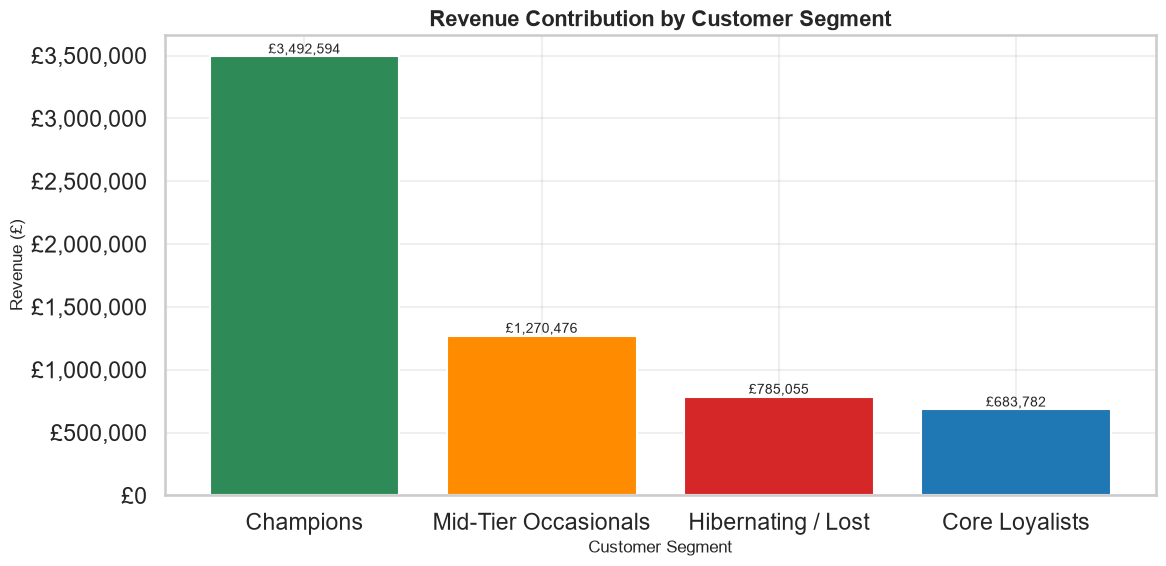

In [101]:
# ============================================================
# PHASE 9B - CELL 4
# Revenue Contribution by Customer Segment
# ============================================================

segment_revenue = (

    BI["customers"]

    .groupby("Segment_Name")["Total_Revenue"]

    .sum()

    .sort_values(ascending=False)

    .reset_index()

)

plt.figure(figsize=(12,6))

bars = plt.bar(

    segment_revenue["Segment_Name"],

    segment_revenue["Total_Revenue"],

    color=[
        SEGMENT_COLOURS[s]
        for s in segment_revenue["Segment_Name"]
    ]

)

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter("£{x:,.0f}")
)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height(),

        f"£{bar.get_height():,.0f}",

        ha="center",

        va="bottom",

        fontsize=10

    )

format_plot(

    "Revenue Contribution by Customer Segment",

    "Customer Segment",

    "Revenue (£)",

    "Business_Intelligence/Revenue_By_Segment"

)

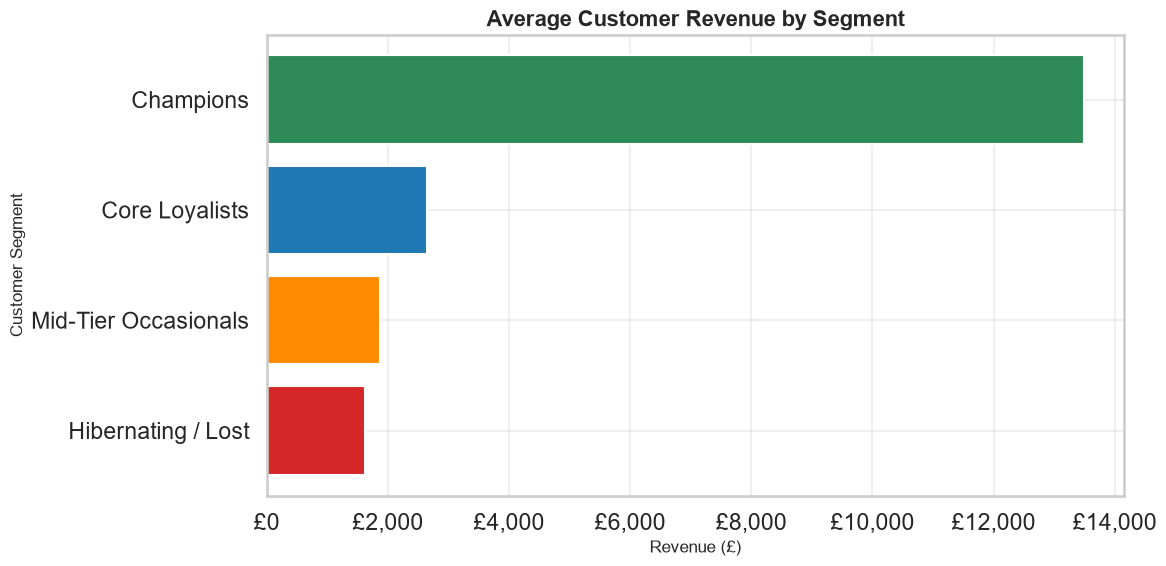

In [102]:
# ============================================================
# PHASE 9B - CELL 5
# Average Revenue per Customer
# ============================================================

avg_revenue = (

    BI["customers"]

    .groupby("Segment_Name")["Total_Revenue"]

    .mean()

    .sort_values()

    .reset_index()

)

plt.figure(figsize=(12,6))

plt.barh(

    avg_revenue["Segment_Name"],

    avg_revenue["Total_Revenue"],

    color=[

        SEGMENT_COLOURS[s]

        for s in avg_revenue["Segment_Name"]

    ]

)

plt.gca().xaxis.set_major_formatter(

    mtick.StrMethodFormatter("£{x:,.0f}")

)

format_plot(

    "Average Customer Revenue by Segment",

    "Revenue (£)",

    "Customer Segment",

    "Business_Intelligence/Average_Customer_Revenue"

)

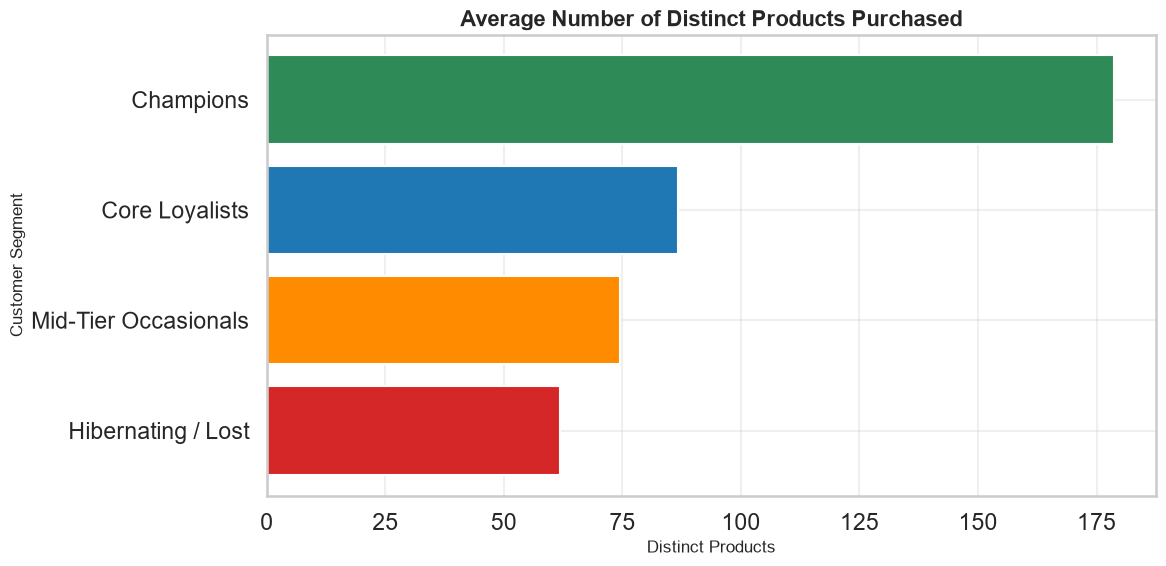

In [103]:
# ============================================================
# PHASE 9B - CELL 6
# Product Diversity by Segment
# ============================================================

product_diversity = (

    BI["customers"]

    .groupby("Segment_Name")["Distinct_Products"]

    .mean()

    .sort_values()

    .reset_index()

)

plt.figure(figsize=(12,6))

plt.barh(

    product_diversity["Segment_Name"],

    product_diversity["Distinct_Products"],

    color=[

        SEGMENT_COLOURS[s]

        for s in product_diversity["Segment_Name"]

    ]

)

format_plot(

    "Average Number of Distinct Products Purchased",

    "Distinct Products",

    "Customer Segment",

    "Business_Intelligence/Product_Diversity"

)

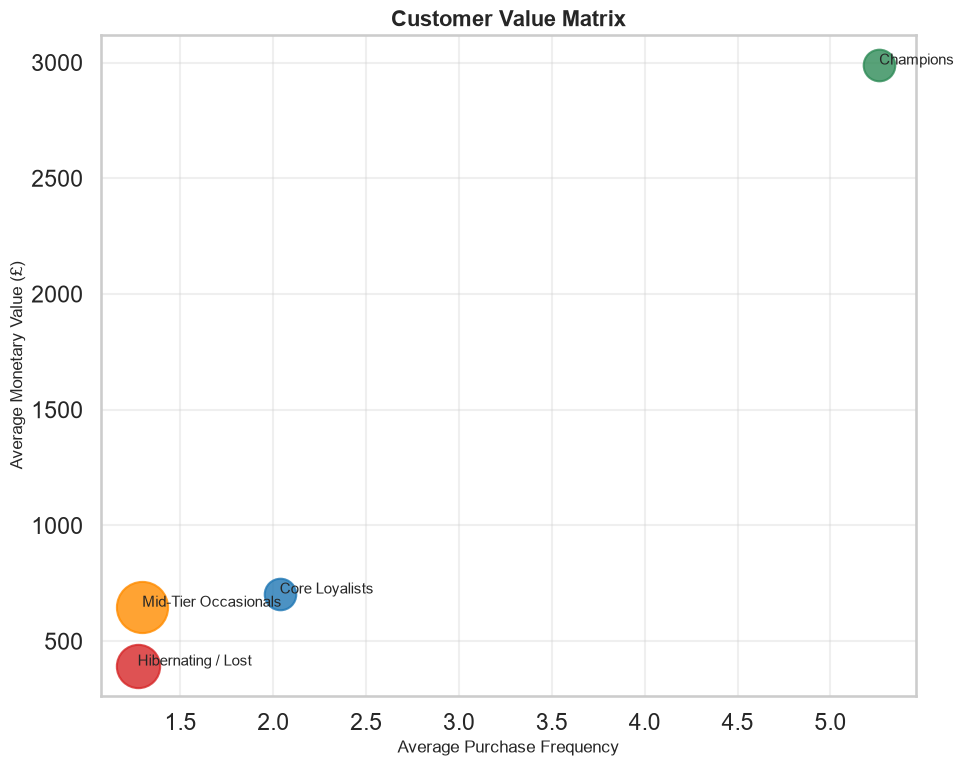

In [104]:
# ============================================================
# PHASE 9B - CELL 7
# Customer Value Matrix
# ============================================================

summary = BI["segments"]

plt.figure(figsize=(10,8))

for _, row in summary.iterrows():

    plt.scatter(

        row["Average_Frequency"],

        row["Average_Monetary"],

        s=row["Customers"]*2,

        color=SEGMENT_COLOURS[row["Segment_Name"]],

        alpha=0.8

    )

    plt.text(

        row["Average_Frequency"],

        row["Average_Monetary"],

        row["Segment_Name"],

        fontsize=11

    )

format_plot(

    "Customer Value Matrix",

    "Average Purchase Frequency",

    "Average Monetary Value (£)",

    "Business_Intelligence/Customer_Value_Matrix"

)

In [105]:
# ============================================================
# PHASE 9B - CELL 8
# Segment Opportunity Matrix
# ============================================================

segment_opportunity = (

    BI["customers"]

    .groupby("Segment_Name")

    .agg(

        Customers=("CustomerID","nunique"),

        Revenue=("Total_Revenue","sum"),

        Average_Revenue=("Total_Revenue","mean"),

        Average_Orders=("Total_Orders","mean"),

        Average_Product_Diversity=("Distinct_Products","mean")

    )

    .reset_index()

)

# ------------------------------------------------------------
# Business Recommendation
# ------------------------------------------------------------

recommendations = {

    "Champions":
        "Retain through VIP rewards and exclusive offers.",

    "Core Loyalists":
        "Increase basket size using cross-selling campaigns.",

    "Mid-Tier Occasionals":
        "Encourage repeat purchases with personalised promotions.",

    "Hibernating/Lost":
        "Run win-back campaigns and targeted discounts."

}

segment_opportunity["Business_Recommendation"] = (

    segment_opportunity["Segment_Name"]

    .map(recommendations)

)

display(segment_opportunity)

,Segment_Name,Customers,Revenue,Average_Revenue,Average_Orders,Average_Product_Diversity,Business_Recommendation
0,Champions,259,3492593.830,13484.918263,19.710425,178.610039,Retain through VIP rewards and exclusive offers.
1,Core Loyalists,258,683781.930,2650.317558,7.534884,86.755814,Increase basket size using cross-selling campa...
2,Hibernating / Lost,486,785055.321,1615.340167,4.432099,61.847737,NaN
3,Mid-Tier Occasionals,679,1270476.300,1871.099116,4.166421,74.594993,Encourage repeat purchases with personalised p...


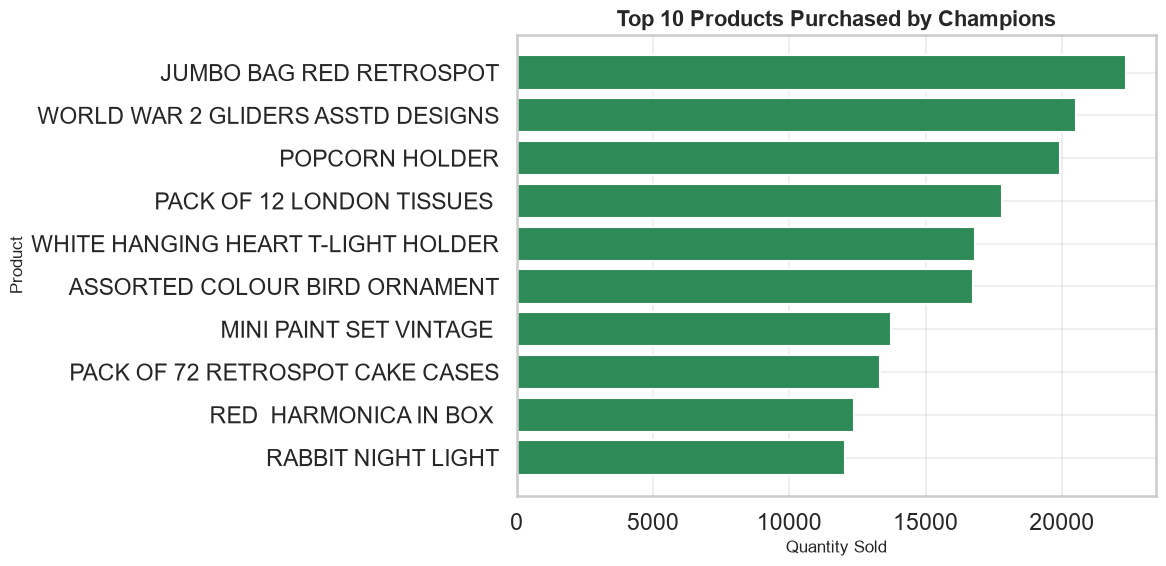

,Description,Quantity,Revenue,Customers
0,JUMBO BAG RED RETROSPOT,22338,39654.98,94
1,WORLD WAR 2 GLIDERS ASSTD DESIGNS,20502,4904.94,34
2,POPCORN HOLDER,19919,14637.95,45
3,PACK OF 12 LONDON TISSUES,17789,5029.47,40
4,WHITE HANGING HEART T-LIGHT HOLDER,16798,46564.04,109
5,ASSORTED COLOUR BIRD ORNAMENT,16728,25741.68,86
6,MINI PAINT SET VINTAGE,13719,8060.55,22
7,PACK OF 72 RETROSPOT CAKE CASES,13330,6208.30,97
8,RED HARMONICA IN BOX,12394,13563.24,47
9,RABBIT NIGHT LIGHT,12054,22737.82,69


In [106]:
# ============================================================
# PHASE 9C - CELL 9
# Champions' Favourite Products
# ============================================================

champions = business_df[
    business_df["Segment_Name"] == "Champions"
]

champion_products = (

    champions

    .groupby("Description")

    .agg(

        Quantity=("Quantity","sum"),

        Revenue=("Revenue","sum"),

        Customers=("CustomerID","nunique")

    )

    .sort_values(

        "Quantity",

        ascending=False

    )

    .head(10)

    .reset_index()

)

plt.figure(figsize=(12,6))

plt.barh(

    champion_products["Description"],

    champion_products["Quantity"],

    color=SEGMENT_COLOURS["Champions"]

)

plt.gca().invert_yaxis()

format_plot(

    "Top 10 Products Purchased by Champions",

    "Quantity Sold",

    "Product",

    "Business_Intelligence/Champions_Top_Products"

)

display(champion_products)

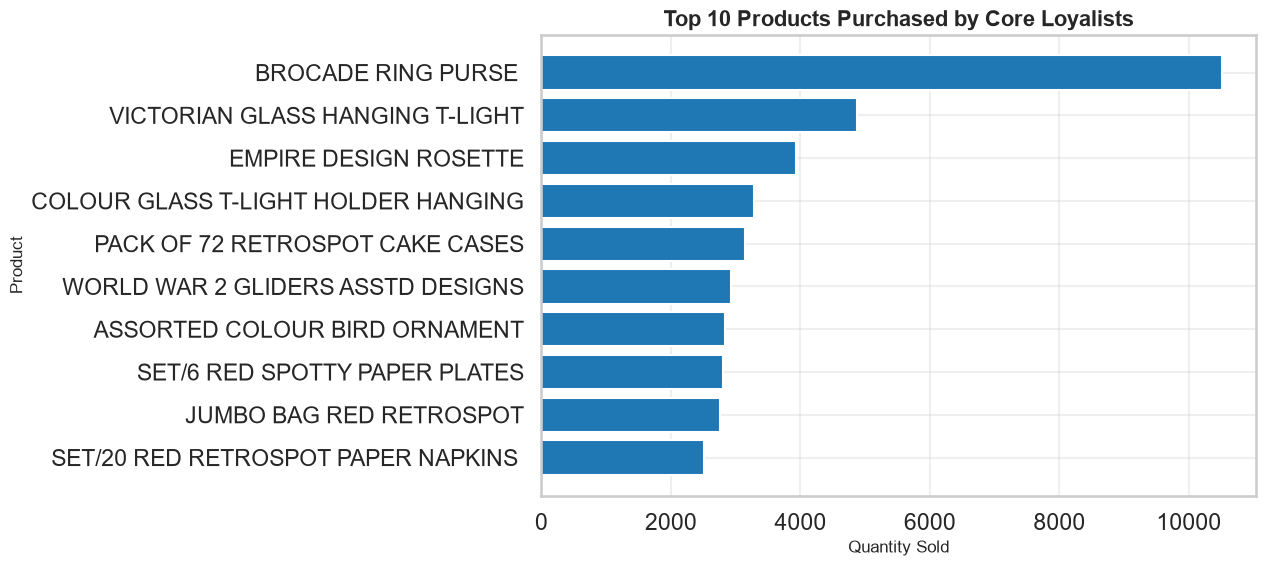

,Description,Quantity,Revenue,Customers
0,BROCADE RING PURSE,10512,2492.64,4
1,VICTORIAN GLASS HANGING T-LIGHT,4868,5831.86,37
2,EMPIRE DESIGN ROSETTE,3931,3234.17,2
3,COLOUR GLASS T-LIGHT HOLDER HANGING,3289,1950.65,38
4,PACK OF 72 RETROSPOT CAKE CASES,3146,1589.90,63
5,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2928,756.96,23
6,ASSORTED COLOUR BIRD ORNAMENT,2838,4757.82,45
7,SET/6 RED SPOTTY PAPER PLATES,2799,1950.75,19
8,JUMBO BAG RED RETROSPOT,2756,5543.91,57
9,SET/20 RED RETROSPOT PAPER NAPKINS,2508,1913.64,41


In [107]:
# ============================================================
# PHASE 9C - CELL 10
# Top 10 Products Purchased by Core Loyalists
# ============================================================

segment = "Core Loyalists"

core = business_df[
    business_df["Segment_Name"] == segment
]

core_products = (

    core

    .groupby("Description")

    .agg(

        Quantity=("Quantity","sum"),

        Revenue=("Revenue","sum"),

        Customers=("CustomerID","nunique")

    )

    .sort_values(

        "Quantity",

        ascending=False

    )

    .head(10)

    .reset_index()

)

plt.figure(figsize=(13,6))

plt.barh(

    core_products["Description"],

    core_products["Quantity"],

    color=SEGMENT_COLOURS[segment]

)

plt.gca().invert_yaxis()

format_plot(

    "Top 10 Products Purchased by Core Loyalists",

    "Quantity Sold",

    "Product",

    "Business_Intelligence/Core_Loyalists_Top_Products"

)

display(core_products)

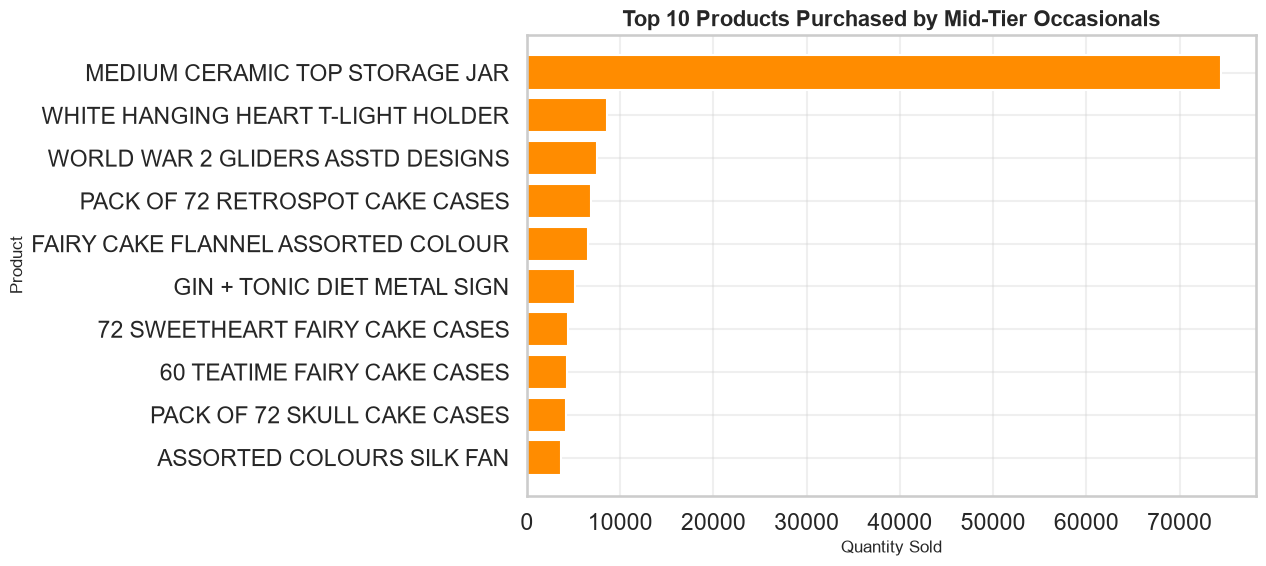

,Description,Quantity,Revenue,Customers
0,MEDIUM CERAMIC TOP STORAGE JAR,74472,77484.69,16
1,WHITE HANGING HEART T-LIGHT HOLDER,8620,22463.50,173
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,7483,1784.15,50
3,PACK OF 72 RETROSPOT CAKE CASES,6885,3109.23,114
4,FAIRY CAKE FLANNEL ASSORTED COLOUR,6525,13646.07,23
5,GIN + TONIC DIET METAL SIGN,5108,9536.61,61
6,72 SWEETHEART FAIRY CAKE CASES,4411,1942.45,64
7,60 TEATIME FAIRY CAKE CASES,4347,1948.05,75
8,PACK OF 72 SKULL CAKE CASES,4177,1848.31,58
9,ASSORTED COLOURS SILK FAN,3648,2694.00,41


In [108]:
# ============================================================
# PHASE 9C - CELL 11
# Top 10 Products Purchased by Mid-Tier Occasionals
# ============================================================

segment = "Mid-Tier Occasionals"

mid = business_df[
    business_df["Segment_Name"] == segment
]

mid_products = (

    mid

    .groupby("Description")

    .agg(

        Quantity=("Quantity","sum"),

        Revenue=("Revenue","sum"),

        Customers=("CustomerID","nunique")

    )

    .sort_values(

        "Quantity",

        ascending=False

    )

    .head(10)

    .reset_index()

)

plt.figure(figsize=(13,6))

plt.barh(

    mid_products["Description"],

    mid_products["Quantity"],

    color=SEGMENT_COLOURS[segment]

)

plt.gca().invert_yaxis()

format_plot(

    "Top 10 Products Purchased by Mid-Tier Occasionals",

    "Quantity Sold",

    "Product",

    "Business_Intelligence/MidTier_Top_Products"

)

display(mid_products)

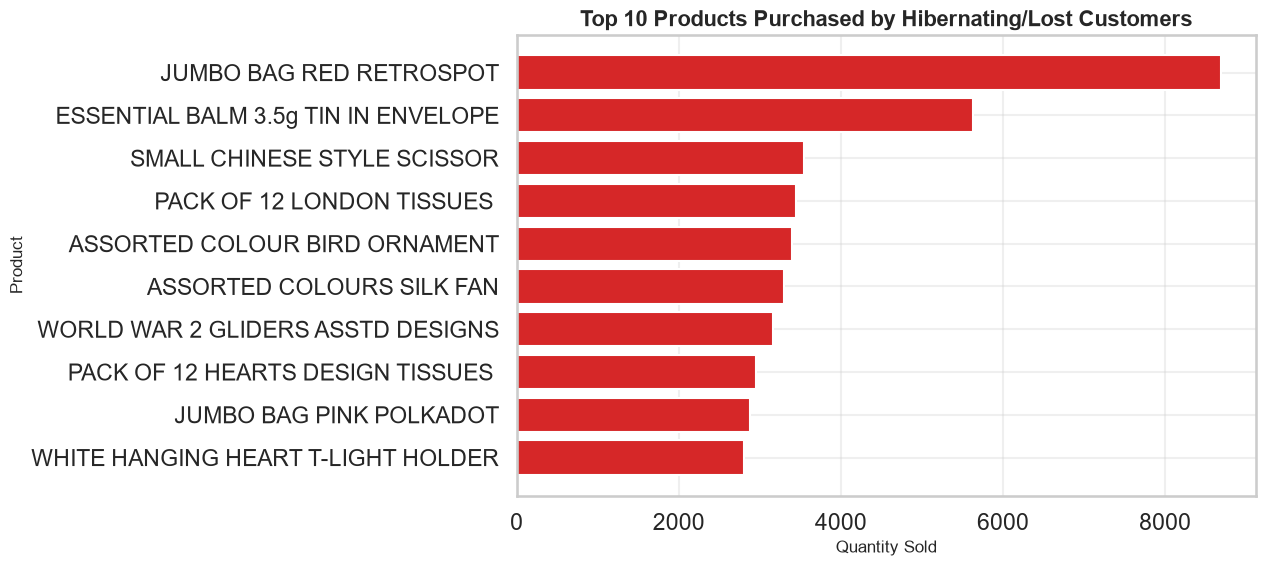

,Description,Quantity,Revenue,Customers
0,JUMBO BAG RED RETROSPOT,8687,16127.61,91
1,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,5625,342.18,4
2,SMALL CHINESE STYLE SCISSOR,3540,1136.80,2
3,PACK OF 12 LONDON TISSUES,3444,881.36,17
4,ASSORTED COLOUR BIRD ORNAMENT,3403,5559.07,81
5,ASSORTED COLOURS SILK FAN,3300,2306.52,25
6,WORLD WAR 2 GLIDERS ASSTD DESIGNS,3169,872.93,36
7,PACK OF 12 HEARTS DESIGN TISSUES,2954,755.70,52
8,JUMBO BAG PINK POLKADOT,2884,5423.33,52
9,WHITE HANGING HEART T-LIGHT HOLDER,2804,7708.20,116


In [109]:
# ============================================================
# PHASE 9C - CELL 12
# Top 10 Products Purchased by Hibernating/Lost Customers
# ============================================================

segment = "Hibernating / Lost"

hibernating = business_df[
    business_df["Segment_Name"] == segment
]

hibernating_products = (

    hibernating

    .groupby("Description")

    .agg(

        Quantity=("Quantity","sum"),

        Revenue=("Revenue","sum"),

        Customers=("CustomerID","nunique")

    )

    .sort_values(

        "Quantity",

        ascending=False

    )

    .head(10)

    .reset_index()

)

plt.figure(figsize=(13,6))

plt.barh(

    hibernating_products["Description"],

    hibernating_products["Quantity"],

    color=SEGMENT_COLOURS[segment]

)

plt.gca().invert_yaxis()

format_plot(

    "Top 10 Products Purchased by Hibernating/Lost Customers",

    "Quantity Sold",

    "Product",

    "Business_Intelligence/Hibernating_Top_Products"

)

display(hibernating_products)

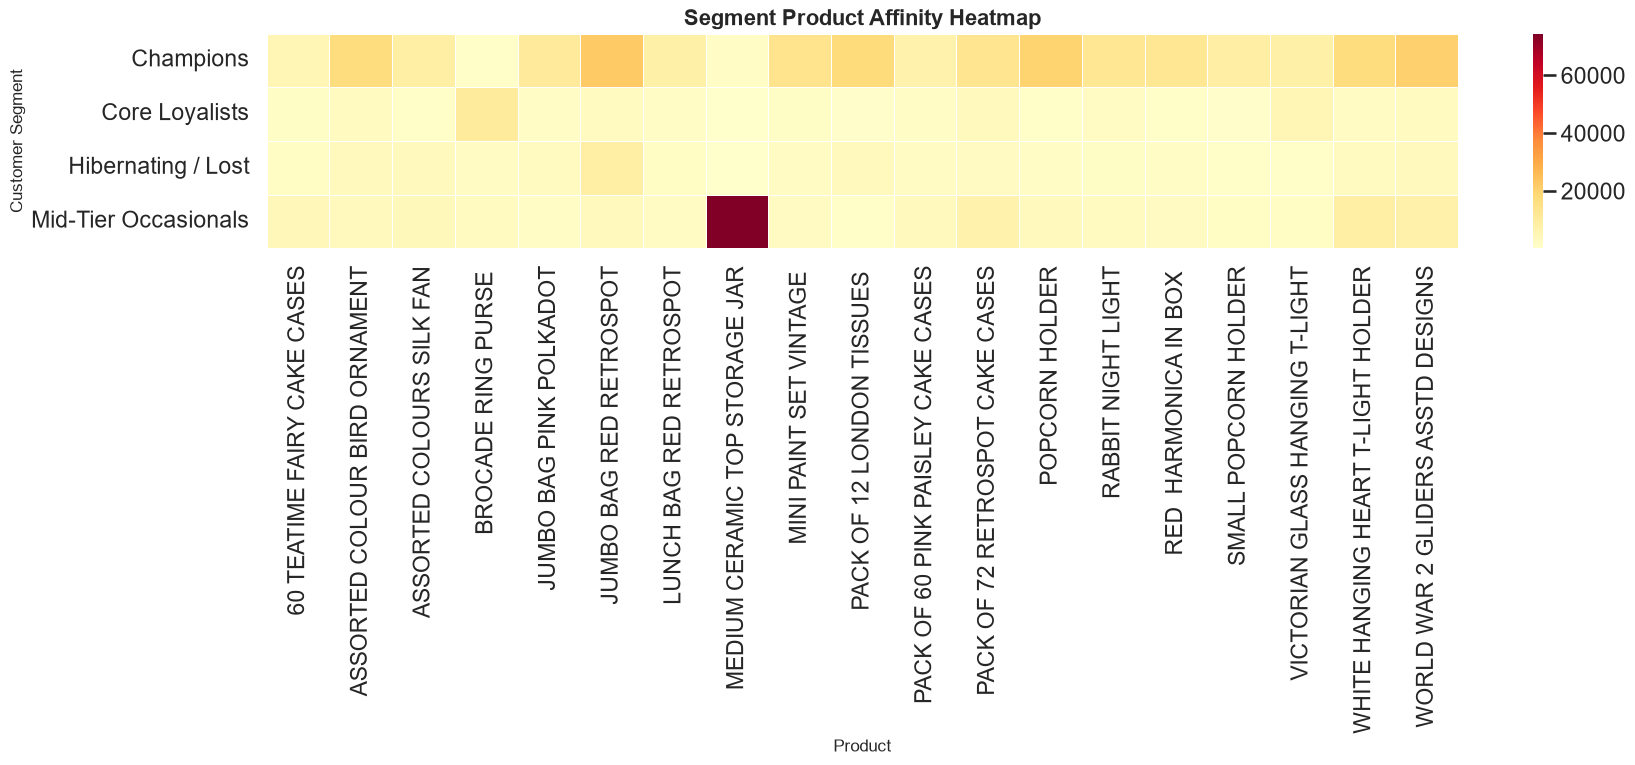

In [110]:
# ============================================================
# PHASE 9C - CELL 13
# Segment Product Affinity Heatmap
# ============================================================

top_products = (

    business_df

    .groupby("Description")["Quantity"]

    .sum()

    .nlargest(20)

    .index

)

heatmap_data = (

    business_df[

        business_df["Description"].isin(top_products)

    ]

    .pivot_table(

        index="Segment_Name",

        columns="Description",

        values="Quantity",

        aggfunc="sum",

        fill_value=0

    )

)

plt.figure(figsize=(18,8))

sns.heatmap(

    heatmap_data,

    cmap="YlOrRd",

    linewidths=.5

)

format_plot(

    "Segment Product Affinity Heatmap",

    "Product",

    "Customer Segment",

    "Business_Intelligence/Segment_Product_Heatmap"

)

,Description,Segment_Name,Quantity,Total_Product_Quantity,SegmentShare
12508,WOVEN BUBBLE GUM CUSHION COVER,Champions,2,2,100.0
12758,ZINC PLANT POT HOLDER,Core Loyalists,8,8,100.0
1859,"CAKESTAND, 3 TIER, LOVEHEART",Hibernating / Lost,2,2,100.0
1927,CANNISTER VINTAGE LEAF DESIGN,Champions,12,12,100.0
12640,WRAP SUMMER ROSE DESIGN,Champions,50,50,100.0
12683,YELLOW PINK FLOWER DESIGN BIG BOWL,Champions,22,22,100.0
12691,YELLOW/BLUE RETRO RADIO,Mid-Tier Occasionals,10,10,100.0
12692,YELLOW/ORANGE FLOWER DESIGN PLATE,Champions,60,60,100.0
16,I LOVE LONDON MINI RUCKSACK,Champions,1,1,100.0
9863,SET OF 3 MINI HANGING PORTRAITS,Champions,24,24,100.0


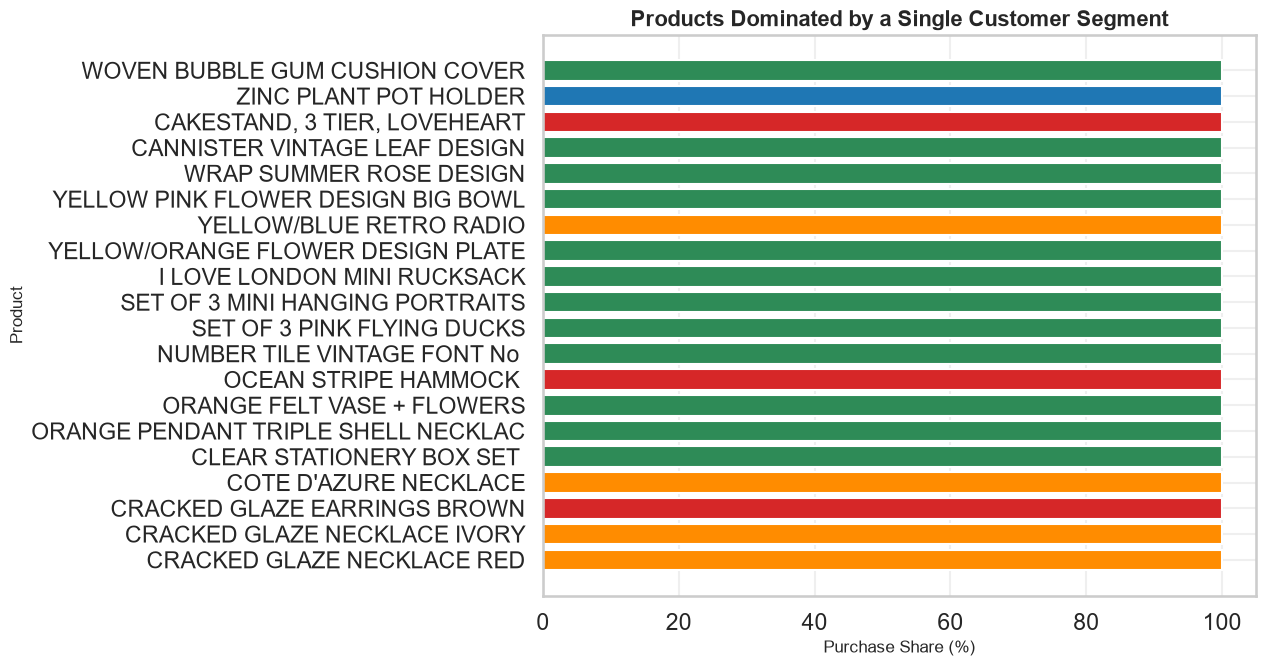

In [111]:
# ============================================================
# PHASE 9C - CELL 14
# Exclusive Product Analysis
# ============================================================

product_segment = (

    business_df

    .groupby(
        [
            "Description",
            "Segment_Name"
        ]
    )

    .agg(

        Quantity=("Quantity","sum")

    )

    .reset_index()

)

# ------------------------------------------------------------
# Percentage contribution per product
# ------------------------------------------------------------

product_segment["Total_Product_Quantity"] = (

    product_segment

    .groupby("Description")["Quantity"]

    .transform("sum")

)

product_segment["SegmentShare"] = (

    product_segment["Quantity"]

    / product_segment["Total_Product_Quantity"]

    *100

)

exclusive_products = (

    product_segment

    .sort_values(

        "SegmentShare",

        ascending=False

    )

    .drop_duplicates("Description")

    .head(20)

)

display(exclusive_products)

plt.figure(figsize=(13,7))

plt.barh(

    exclusive_products["Description"],

    exclusive_products["SegmentShare"],

    color=[

        SEGMENT_COLOURS[s]

        for s in exclusive_products["Segment_Name"]

    ]

)

plt.gca().invert_yaxis()

format_plot(

    "Products Dominated by a Single Customer Segment",

    "Purchase Share (%)",

    "Product",

    "Business_Intelligence/Exclusive_Product_Analysis"

)

,Description,Segments,Quantity,Customers
0,MEDIUM CERAMIC TOP STORAGE JAR,4,77916,138
1,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4,54415,307
2,JUMBO BAG RED RETROSPOT,4,46181,635
3,WHITE HANGING HEART T-LIGHT HOLDER,4,36725,856
4,ASSORTED COLOUR BIRD ORNAMENT,4,35362,678
5,PACK OF 72 RETROSPOT CAKE CASES,4,33693,635
6,POPCORN HOLDER,4,30931,295
7,RABBIT NIGHT LIGHT,4,27202,450
8,MINI PAINT SET VINTAGE,4,26076,213
9,PACK OF 12 LONDON TISSUES,4,25345,195


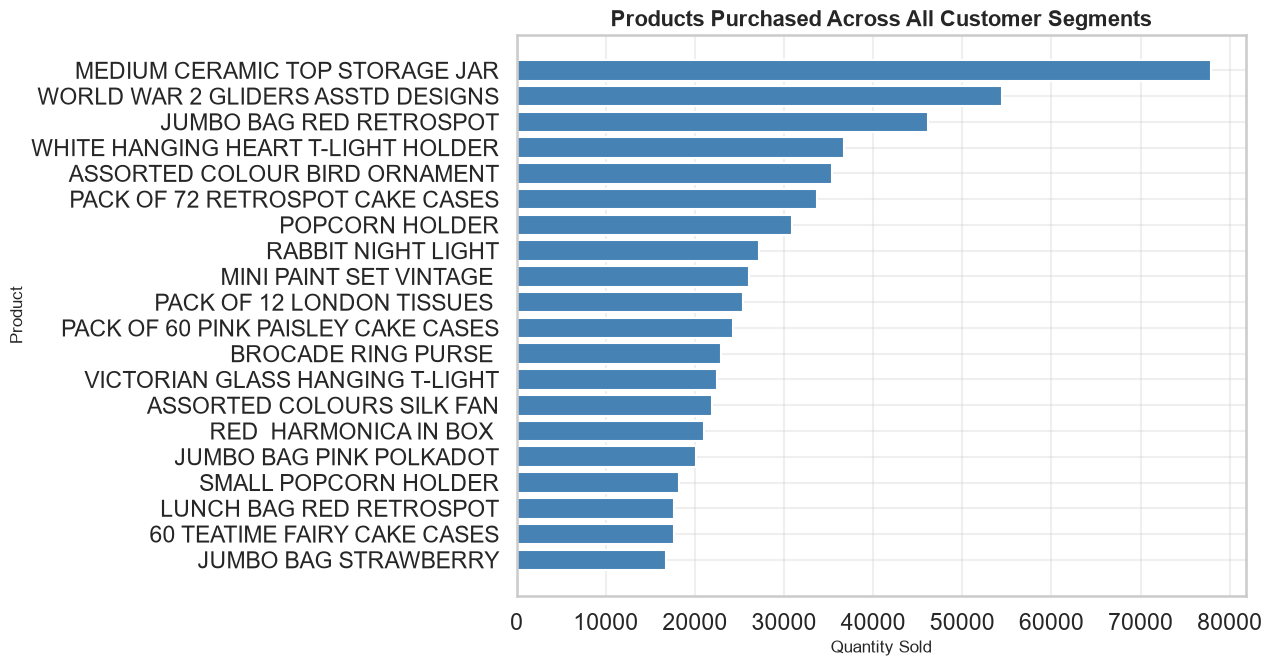

In [112]:
# ============================================================
# PHASE 9C - CELL 15
# Shared Products Across Segments
# ============================================================

shared_products = (

    business_df

    .groupby("Description")

    .agg(

        Segments=("Segment_Name","nunique"),

        Quantity=("Quantity","sum"),

        Customers=("CustomerID","nunique")

    )

    .query("Segments == 4")

    .sort_values(

        "Quantity",

        ascending=False

    )

    .head(20)

    .reset_index()

)

display(shared_products)

plt.figure(figsize=(13,7))

plt.barh(

    shared_products["Description"],

    shared_products["Quantity"],

    color="steelblue"

)

plt.gca().invert_yaxis()

format_plot(

    "Products Purchased Across All Customer Segments",

    "Quantity Sold",

    "Product",

    "Business_Intelligence/Shared_Products"

)

,Segment_Name,DistinctProducts,TotalPurchases,DiversityIndex
0,Champions,3461,1958393,0.001767
1,Core Loyalists,2897,410811,0.007052
2,Hibernating / Lost,3052,472030,0.006466
3,Mid-Tier Occasionals,3383,752492,0.004496


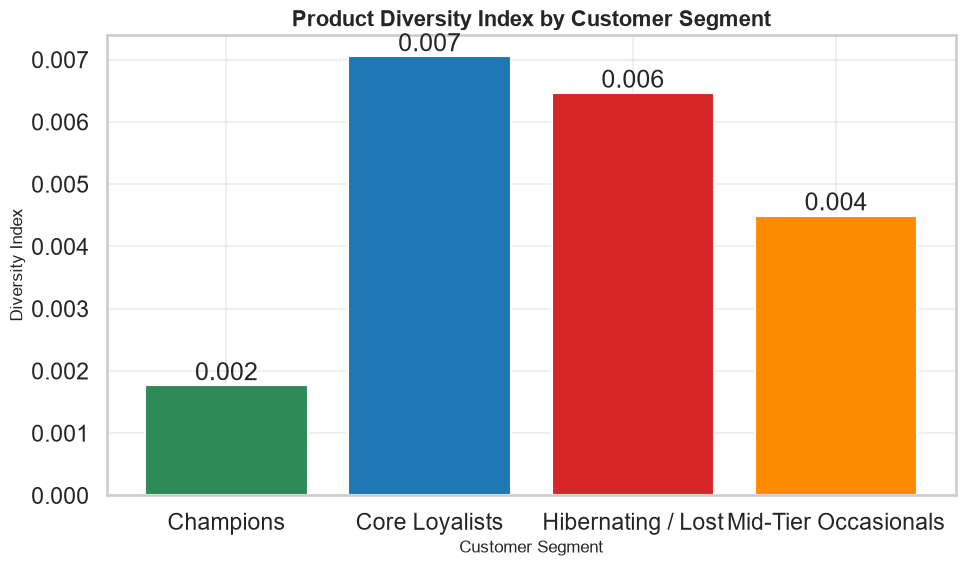

In [113]:
# ============================================================
# PHASE 9C - CELL 16
# Product Diversity Index
# ============================================================

segment_diversity = (

    business_df

    .groupby("Segment_Name")

    .agg(

        DistinctProducts=("Description","nunique"),

        TotalPurchases=("Quantity","sum")

    )

    .reset_index()

)

segment_diversity["DiversityIndex"] = (

    segment_diversity["DistinctProducts"]

    /

    segment_diversity["TotalPurchases"]

)

display(segment_diversity)

plt.figure(figsize=(10,6))

bars = plt.bar(

    segment_diversity["Segment_Name"],

    segment_diversity["DiversityIndex"],

    color=[

        SEGMENT_COLOURS[s]

        for s in segment_diversity["Segment_Name"]

    ]

)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height(),

        f"{bar.get_height():.3f}",

        ha="center",

        va="bottom"

    )

format_plot(

    "Product Diversity Index by Customer Segment",

    "Customer Segment",

    "Diversity Index",

    "Business_Intelligence/Product_Diversity_Index"

)

In [114]:
# ============================================================
# PHASE 9C - CELL 17
# Highest Revenue Products by Segment
# ============================================================

top_revenue_products = (

    business_df

    .groupby(
        [
            "Segment_Name",
            "Description"
        ]
    )

    .agg(

        Revenue=("Revenue","sum")

    )

    .reset_index()

)

top_revenue = (

    top_revenue_products

    .sort_values(

        ["Segment_Name","Revenue"],

        ascending=[True,False]

    )

    .groupby("Segment_Name")

    .head(5)

)

display(top_revenue)

,Segment_Name,Description,Revenue
2439,Champions,REGENCY CAKESTAND 3 TIER,81615.75
3299,Champions,WHITE HANGING HEART T-LIGHT HOLDER,46564.04
1552,Champions,JUMBO BAG RED RETROSPOT,39654.98
632,Champions,CHILLI LIGHTS,29232.01
324,Champions,BLACK RECORD COVER FRAME,28432.53
5496,Core Loyalists,REGENCY CAKESTAND 3 TIER,10342.80
5196,Core Loyalists,PARTY BUNTING,7785.70
5165,Core Loyalists,PAPER BUNTING RETROSPOT,6532.00
6216,Core Loyalists,WHITE HANGING HEART T-LIGHT HOLDER,6338.40
6100,Core Loyalists,VICTORIAN GLASS HANGING T-LIGHT,5831.86


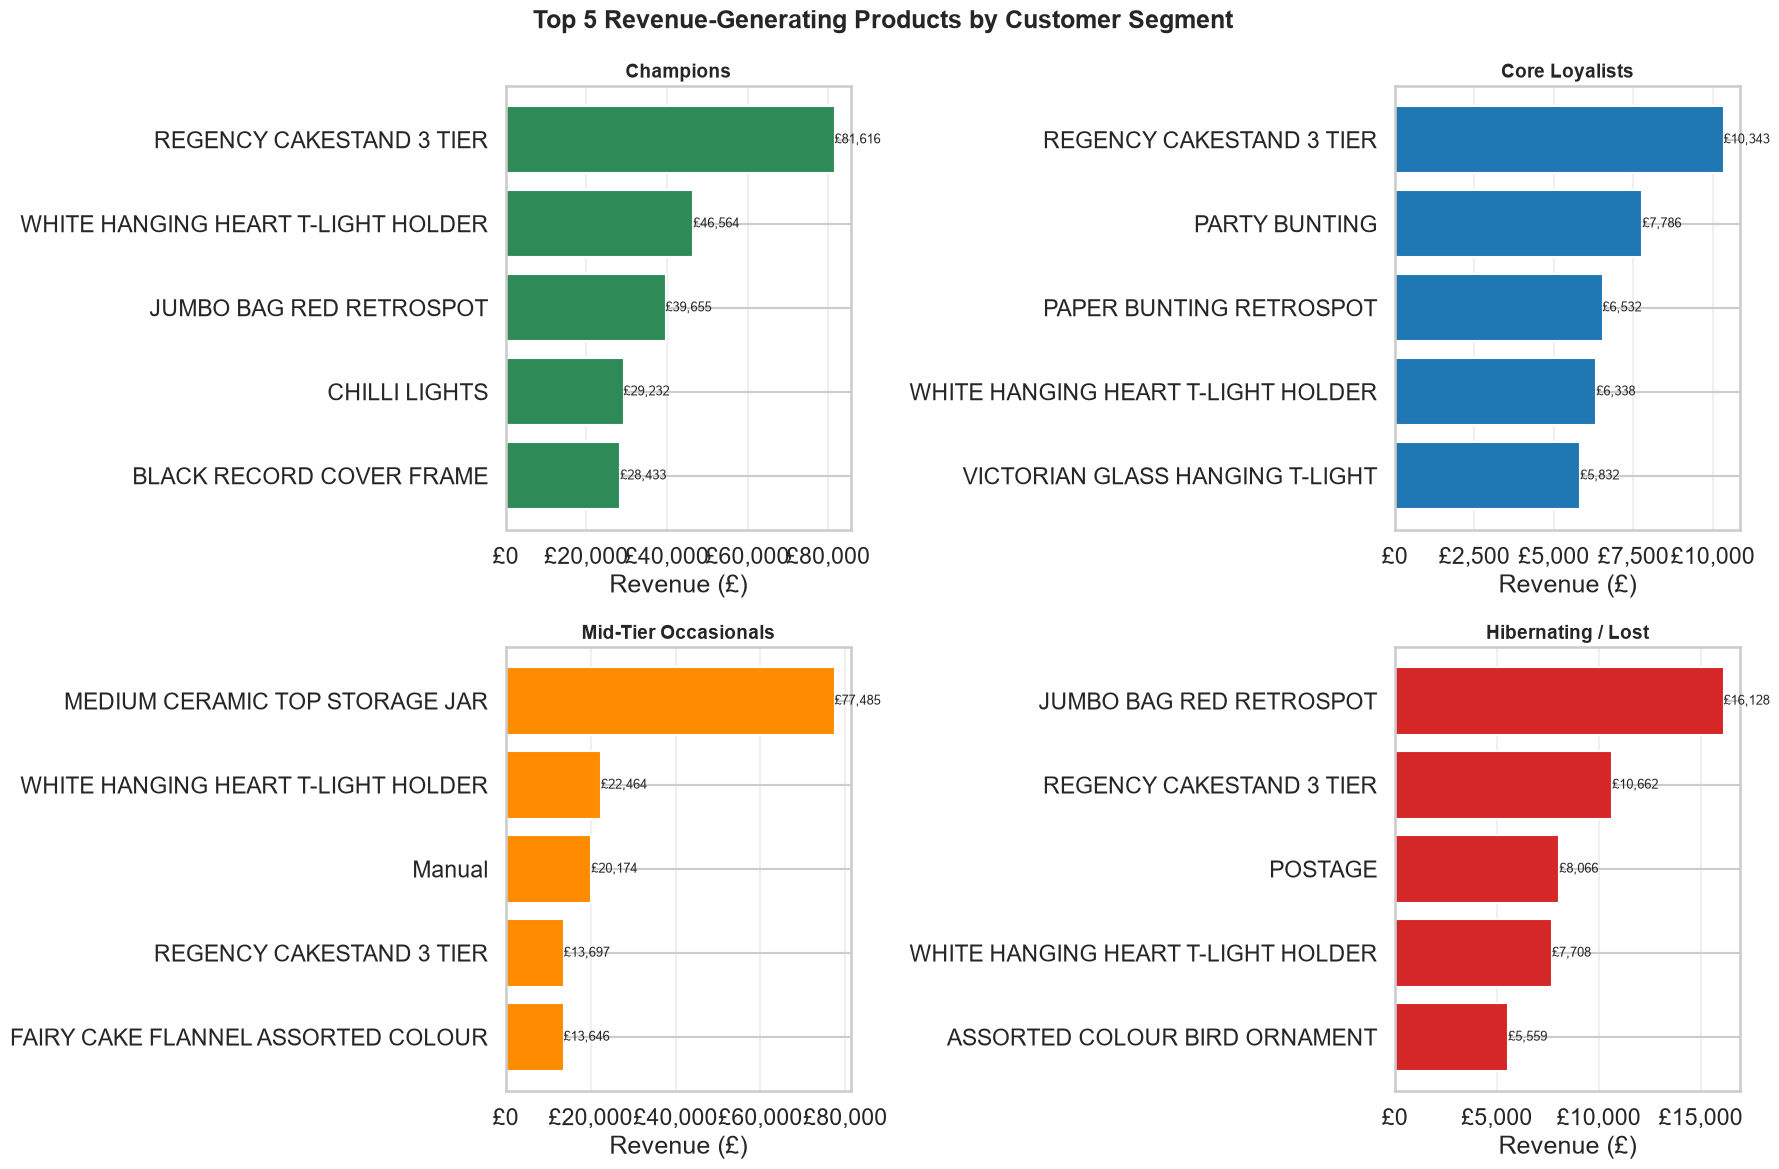

In [115]:
# ============================================================
# PHASE 9C - CELL 17
# Highest Revenue Products by Customer Segment
# ============================================================

import matplotlib.ticker as mtick

# ------------------------------------------------------------
# Top 5 Revenue Products per Segment
# ------------------------------------------------------------

top_revenue = (

    business_df

    .groupby(
        [
            "Segment_Name",
            "Description"
        ]
    )

    .agg(
        Revenue=("Revenue", "sum")
    )

    .reset_index()

)

top_revenue = (

    top_revenue

    .sort_values(
        ["Segment_Name", "Revenue"],
        ascending=[True, False]
    )

    .groupby("Segment_Name")

    .head(5)

)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(

    2,
    2,

    figsize=(18,12)

)

axes = axes.flatten()

segments = [

    "Champions",

    "Core Loyalists",

    "Mid-Tier Occasionals",

    "Hibernating / Lost"

]

for ax, segment in zip(axes, segments):

    data = (

        top_revenue[
            top_revenue["Segment_Name"] == segment
        ]

        .sort_values(
            "Revenue",
            ascending=True
        )

    )

    bars = ax.barh(

        data["Description"],

        data["Revenue"],

        color=SEGMENT_COLOURS[segment]

    )

    ax.set_title(

        segment,

        fontsize=14,

        fontweight="bold"

    )

    ax.set_xlabel("Revenue (£)")

    ax.xaxis.set_major_formatter(

        mtick.StrMethodFormatter("£{x:,.0f}")

    )

    ax.grid(

        alpha=0.3,

        axis="x"

    )

    # Revenue labels

    for bar in bars:

        value = bar.get_width()

        ax.text(

            value,

            bar.get_y() + bar.get_height()/2,

            f"£{value:,.0f}",

            va="center",

            ha="left",

            fontsize=9

        )

plt.suptitle(

    "Top 5 Revenue-Generating Products by Customer Segment",

    fontsize=18,

    fontweight="bold"

)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_FOLDER,

        "Business_Intelligence",

        "Top_Revenue_Products_By_Segment.png"

    ),

    dpi=300,

    bbox_inches="tight"

)

plt.show()

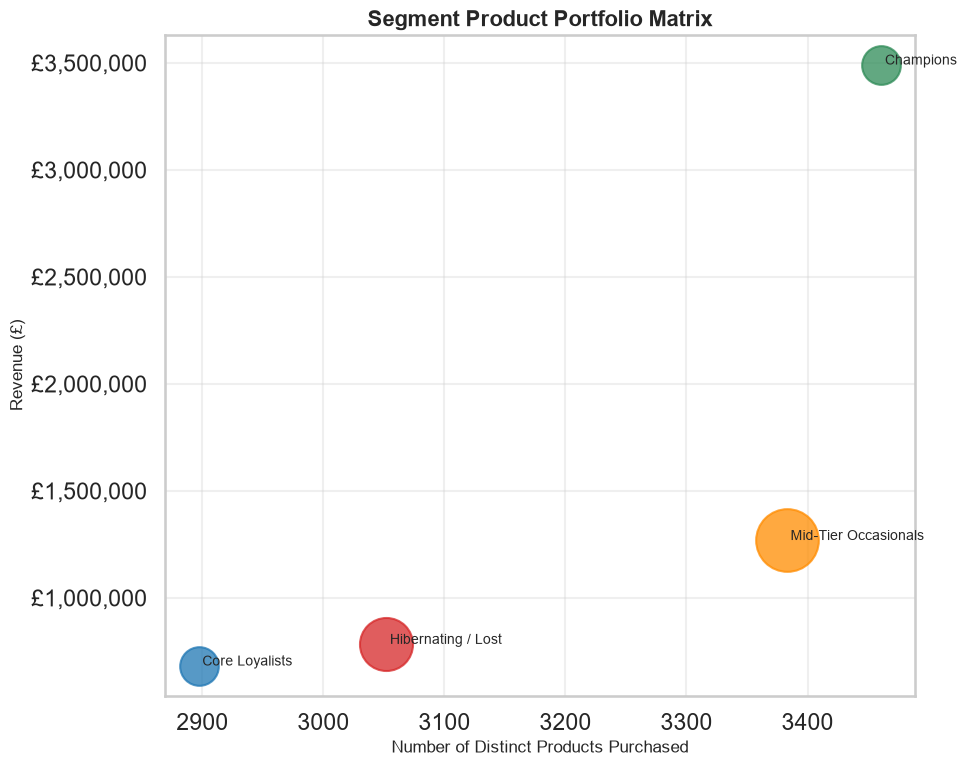

In [116]:
# ============================================================
# PHASE 9C - CELL 18
# Segment Product Portfolio Matrix
# ============================================================

portfolio = (

    business_df

    .groupby("Segment_Name")

    .agg(

        Revenue=("Revenue","sum"),

        Customers=("CustomerID","nunique"),

        ProductDiversity=("Description","nunique")

    )

    .reset_index()

)

plt.figure(figsize=(10,8))

for _, row in portfolio.iterrows():

    plt.scatter(

        row["ProductDiversity"],

        row["Revenue"],

        s=row["Customers"]*3,

        color=SEGMENT_COLOURS[row["Segment_Name"]],

        alpha=0.75

    )

    plt.text(

        row["ProductDiversity"]+3,

        row["Revenue"],

        row["Segment_Name"],

        fontsize=10

    )

plt.gca().yaxis.set_major_formatter(

    mtick.StrMethodFormatter("£{x:,.0f}")

)

format_plot(

    "Segment Product Portfolio Matrix",

    "Number of Distinct Products Purchased",

    "Revenue (£)",

    "Business_Intelligence/Segment_Product_Portfolio"

)

### PHASE 9D – Dynamic Business Intelligence

In [117]:
# ============================================================
# PHASE 9D - CELL 0
# Build Dynamic Business Dataset
# ============================================================

segments = dynamic_results[

    [
        "CustomerID",
        "CycleID",
        "Segment_Name"
    ]

].copy()

segments["CustomerID"] = segments["CustomerID"].astype(str)

transactions = df_retail.copy()

transactions["CustomerID"] = (

    transactions["CustomerID"]

    .astype(int)

    .astype(str)

)

dynamic_business_df = transactions.merge(

    segments,

    on="CustomerID",

    how="inner"

)

dynamic_business_df["Revenue"] = (

    dynamic_business_df["Quantity"]

    *

    dynamic_business_df["UnitPrice"]

)

print(dynamic_business_df.shape)

display(dynamic_business_df.head())

(1820954, 13)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Price,YearMonth,CycleID,Segment_Name,Revenue
0,536368,22914,BLUE COAT RACK PARIS FASHION,3,2010-12-01 08:34:00,4.95,13047,United Kingdom,14.85,2010-12,Cycle_1,Core Loyalists,14.85
1,536368,22914,BLUE COAT RACK PARIS FASHION,3,2010-12-01 08:34:00,4.95,13047,United Kingdom,14.85,2010-12,Cycle_3,Mid-Tier Occasionals,14.85
2,536368,22914,BLUE COAT RACK PARIS FASHION,3,2010-12-01 08:34:00,4.95,13047,United Kingdom,14.85,2010-12,Cycle_4,Hibernating / Lost,14.85
3,536368,22914,BLUE COAT RACK PARIS FASHION,3,2010-12-01 08:34:00,4.95,13047,United Kingdom,14.85,2010-12,Cycle_6,Mid-Tier Occasionals,14.85
4,536368,22914,BLUE COAT RACK PARIS FASHION,3,2010-12-01 08:34:00,4.95,13047,United Kingdom,14.85,2010-12,Cycle_8,Mid-Tier Occasionals,14.85


In [118]:
# ============================================================
# PHASE 9D - CELL 1
# Revenue Evolution by Segment
# ============================================================

cycle_revenue = (

    dynamic_business_df

    .groupby(

        [

            "CycleID",

            "Segment_Name"

        ]

    )

    .agg(

        Revenue=("Revenue","sum")

    )

    .reset_index()

)

display(cycle_revenue.head())

,CycleID,Segment_Name,Revenue
0,Cycle_1,Champions,2203459.30
1,Cycle_1,Core Loyalists,837253.72
2,Cycle_1,Hibernating / Lost,739214.96
3,Cycle_1,Mid-Tier Occasionals,1208591.94
4,Cycle_2,Champions,1478602.24


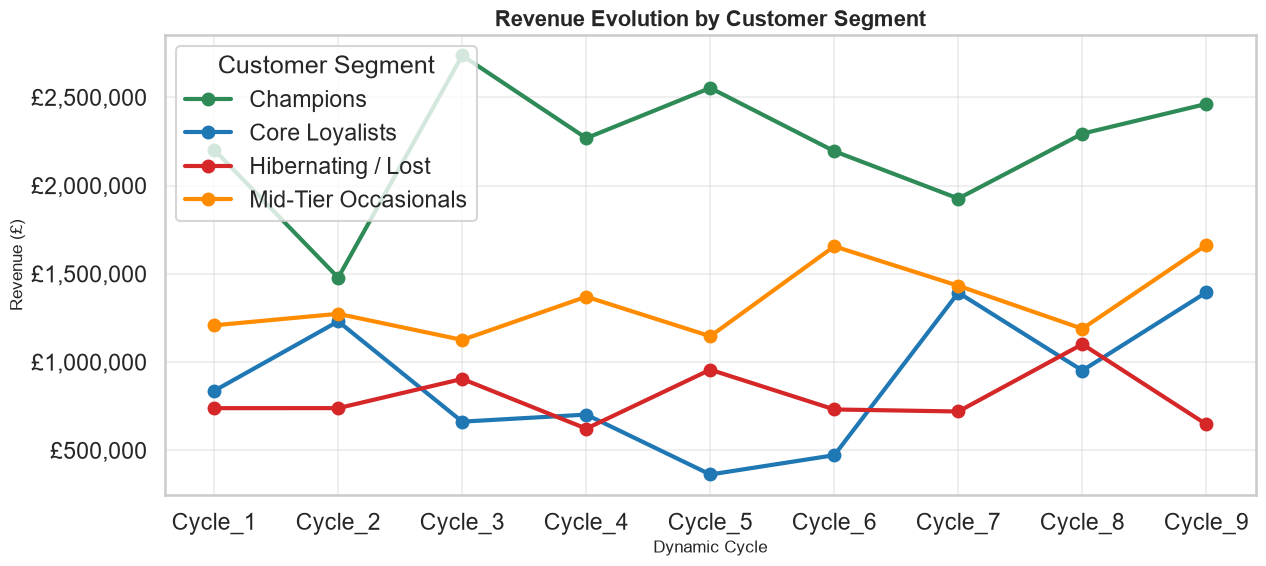

In [119]:
pivot = (

    cycle_revenue

    .pivot(

        index="CycleID",

        columns="Segment_Name",

        values="Revenue"

    )

)

plt.figure(figsize=(13,6))

for segment in pivot.columns:

    plt.plot(

        pivot.index,

        pivot[segment],

        marker="o",

        linewidth=3,

        color=SEGMENT_COLOURS[segment],

        label=segment

    )

plt.gca().yaxis.set_major_formatter(

    mtick.StrMethodFormatter("£{x:,.0f}")

)

plt.legend(title="Customer Segment")

format_plot(

    "Revenue Evolution by Customer Segment",

    "Dynamic Cycle",

    "Revenue (£)",

    "Dynamic_Analytics/Revenue_Evolution"

)

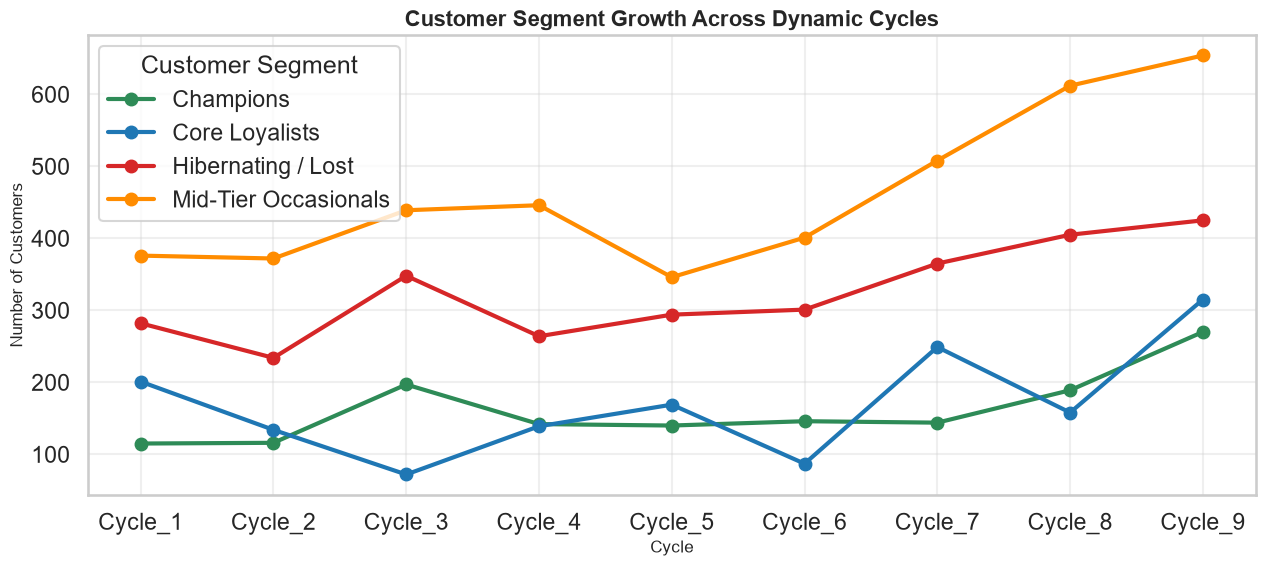

In [120]:
population = (

    dynamic_results

    .groupby(

        ["CycleID", "Segment_Name"]

    )

    .size()

    .reset_index(name="Customers")

)

pivot = population.pivot(

    index="CycleID",

    columns="Segment_Name",

    values="Customers"

)

plt.figure(figsize=(13,6))

for segment in pivot.columns:

    plt.plot(

        pivot.index,

        pivot[segment],

        marker="o",

        linewidth=3,

        color=SEGMENT_COLOURS[segment],

        label=segment

    )

plt.legend(title="Customer Segment")

format_plot(

    "Customer Segment Growth Across Dynamic Cycles",

    "Cycle",

    "Number of Customers",

    "Dynamic_Analytics/Segment_Growth"

)

PHASE 9A

In [121]:
# ============================================================
# PHASE 9A - CELL 1
# Load Dynamic Segmentation Results
# ============================================================

import sqlite3
import pandas as pd
import numpy as np

conn = sqlite3.connect(DATABASE_PATH)

dynamic_results = pd.read_sql("""

SELECT *

FROM Dynamic_Loop_Results

""", conn)

dynamic_results["CustomerID"] = (
    dynamic_results["CustomerID"]
    .astype(str)
)

print(dynamic_results.shape)

display(dynamic_results.head())

(10055, 11)


,DynamicID,CustomerID,CycleID,Previous_Cluster,MDFCM_Cluster_Number,Highest_Membership_Score,All_Fuzzy_Memberships,Migration_Status,Segment_Name,Updated_Centroids,Dynamic_Silhouette_Score
0,1,12352,Cycle_1,3.0,0,0.581014,"[0.5810139610480569, 0.09084392498117227, 0.16...",Migrated,Champions,None,None
1,2,12370,Cycle_1,2.0,2,0.745546,"[0.09793996240095529, 0.02557858959369171, 0.7...",Stable,Mid-Tier Occasionals,None,None
2,3,12383,Cycle_1,2.0,2,0.756092,"[0.060201252775430564, 0.01559301304781732, 0....",Stable,Mid-Tier Occasionals,None,None
3,4,12388,Cycle_1,3.0,2,0.924999,"[0.02147106429604676, 0.006345195584121239, 0....",Migrated,Mid-Tier Occasionals,None,None
4,5,12395,Cycle_1,0.0,3,0.944384,"[0.024572780777218334, 0.011851625880349593, 0...",Migrated,Hibernating / Lost,None,None


In [122]:
# ============================================================
# PHASE 9A - CELL 2
# Build Dynamic Business Dataset
# ============================================================

dynamic_business = []

for cycle_name, cycle_df in all_cycles.items():

    # ---------------------------------------
    # Skip baseline and future cycle
    # ---------------------------------------

    if cycle_name in ["Cycle_0", "Cycle_10"]:
        continue

    transactions = cycle_df.copy()

    transactions["CustomerID"] = (

        transactions["CustomerID"]

        .astype(int)

        .astype(str)

    )

    transactions["CycleID"] = cycle_name

    transactions["Revenue"] = (

        transactions["Quantity"]

        *

        transactions["UnitPrice"]

    )

    merged = transactions.merge(

        dynamic_results,

        on=[

            "CustomerID",

            "CycleID"

        ],

        how="left"

    )

    dynamic_business.append(merged)

print("✓ All cycles processed.")

✓ All cycles processed.


In [123]:
# ============================================================
# PHASE 9A - CELL 3
# Combine All Dynamic Cycles
# ============================================================

dynamic_business_df = pd.concat(

    dynamic_business,

    ignore_index=True

)

print(dynamic_business_df.shape)

display(dynamic_business_df.head())

(313267, 20)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Price,CycleID,Revenue,DynamicID,Previous_Cluster,MDFCM_Cluster_Number,Highest_Membership_Score,All_Fuzzy_Memberships,Migration_Status,Segment_Name,Updated_Centroids,Dynamic_Silhouette_Score
0,545220,21624,VINTAGE UNION JACK DOORSTOP,3,2011-03-01 08:30:00,5.95,14620,United Kingdom,17.85,Cycle_1,17.85,391,NaN,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None
1,545220,21259,VICTORIAN SEWING BOX SMALL,2,2011-03-01 08:30:00,5.95,14620,United Kingdom,11.90,Cycle_1,11.90,391,NaN,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None
2,545220,22960,JAM MAKING SET WITH JARS,6,2011-03-01 08:30:00,4.25,14620,United Kingdom,25.50,Cycle_1,25.50,391,NaN,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None
3,545220,20829,GLITTER HANGING BUTTERFLY STRING,8,2011-03-01 08:30:00,2.10,14620,United Kingdom,16.80,Cycle_1,16.80,391,NaN,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None
4,545220,22192,BLUE DINER WALL CLOCK,2,2011-03-01 08:30:00,8.50,14620,United Kingdom,17.00,Cycle_1,17.00,391,NaN,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None


In [124]:
# ============================================================
# PHASE 9A - CELL 4
# Validation
# ============================================================

print("Rows")

print(len(dynamic_business_df))

print("\nCycles")

print(dynamic_business_df["CycleID"].value_counts())

print("\nMissing Segments")

print(

    dynamic_business_df["Segment_Name"]

    .isna()

    .sum()

)

Rows
313267

Cycles
CycleID
Cycle_9    64531
Cycle_8    49554
Cycle_7    40028
Cycle_3    28320
Cycle_4    27185
Cycle_1    27175
Cycle_6    27007
Cycle_5    26825
Cycle_2    22642
Name: count, dtype: int64

Missing Segments
0


In [125]:
# ============================================================
# PHASE 9A - CELL 5
# Prepare for SQLite
# ============================================================

if "YearMonth" in dynamic_business_df.columns:

    dynamic_business_df["YearMonth"] = (

        dynamic_business_df["YearMonth"]

        .astype(str)

    )

print(dynamic_business_df.dtypes)

InvoiceNo                           object
StockCode                           object
Description                         object
Quantity                             int64
InvoiceDate                 datetime64[us]
UnitPrice                          float64
CustomerID                             str
Country                                str
Total_Price                        float64
CycleID                                str
Revenue                            float64
DynamicID                            int64
Previous_Cluster                   float64
MDFCM_Cluster_Number                 int64
Highest_Membership_Score           float64
All_Fuzzy_Memberships                  str
Migration_Status                       str
Segment_Name                           str
Updated_Centroids                   object
Dynamic_Silhouette_Score            object
dtype: object


In [126]:
# ============================================================
# PHASE 9A - CELL 6
# Save Dynamic Business Dataset
# ============================================================

dynamic_business_df.to_sql(

    "Dynamic_Business_Analytics",

    conn,

    if_exists="replace",

    index=False

)

conn.commit()

print("✓ Dynamic_Business_Analytics saved.")

✓ Dynamic_Business_Analytics saved.


In [127]:
# ============================================================
# PHASE 9A - CELL 7
# Verify SQLite Table
# ============================================================

verification = pd.read_sql("""

SELECT *

FROM Dynamic_Business_Analytics

LIMIT 10

""", conn)

display(verification)

print()

print(verification.columns.tolist())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Price,CycleID,Revenue,DynamicID,Previous_Cluster,MDFCM_Cluster_Number,Highest_Membership_Score,All_Fuzzy_Memberships,Migration_Status,Segment_Name,Updated_Centroids,Dynamic_Silhouette_Score
0,545220,21624,VINTAGE UNION JACK DOORSTOP,3,2011-03-01 08:30:00,5.95,14620,United Kingdom,17.85,Cycle_1,17.85,391,None,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None
1,545220,21259,VICTORIAN SEWING BOX SMALL,2,2011-03-01 08:30:00,5.95,14620,United Kingdom,11.90,Cycle_1,11.90,391,None,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None
2,545220,22960,JAM MAKING SET WITH JARS,6,2011-03-01 08:30:00,4.25,14620,United Kingdom,25.50,Cycle_1,25.50,391,None,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None
3,545220,20829,GLITTER HANGING BUTTERFLY STRING,8,2011-03-01 08:30:00,2.10,14620,United Kingdom,16.80,Cycle_1,16.80,391,None,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None
4,545220,22192,BLUE DINER WALL CLOCK,2,2011-03-01 08:30:00,8.50,14620,United Kingdom,17.00,Cycle_1,17.00,391,None,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None
5,545220,22191,IVORY DINER WALL CLOCK,2,2011-03-01 08:30:00,8.50,14620,United Kingdom,17.00,Cycle_1,17.00,391,None,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None
6,545220,21700,BIG DOUGHNUT FRIDGE MAGNETS,12,2011-03-01 08:30:00,0.85,14620,United Kingdom,10.20,Cycle_1,10.20,391,None,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None
7,545220,17091J,VANILLA INCENSE IN TIN,6,2011-03-01 08:30:00,1.25,14620,United Kingdom,7.50,Cycle_1,7.50,391,None,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None
8,545220,21485,RETROSPOT HEART HOT WATER BOTTLE,3,2011-03-01 08:30:00,4.95,14620,United Kingdom,14.85,Cycle_1,14.85,391,None,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None
9,545220,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,4,2011-03-01 08:30:00,3.75,14620,United Kingdom,15.00,Cycle_1,15.00,391,None,2,0.89827,"[0.035399342276490754, 0.011064092332802068, 0...",Migrated,Mid-Tier Occasionals,None,None



['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Total_Price', 'CycleID', 'Revenue', 'DynamicID', 'Previous_Cluster', 'MDFCM_Cluster_Number', 'Highest_Membership_Score', 'All_Fuzzy_Memberships', 'Migration_Status', 'Segment_Name', 'Updated_Centroids', 'Dynamic_Silhouette_Score']


In [128]:
# ============================================================
# PHASE 9A - CELL 8
# Dynamic Business Dataset Summary
# ============================================================

summary = pd.DataFrame({

    "Metric":[

        "Transactions",

        "Customers",

        "Cycles",

        "Segments",

        "Products"

    ],

    "Value":[

        len(dynamic_business_df),

        dynamic_business_df["CustomerID"].nunique(),

        dynamic_business_df["CycleID"].nunique(),

        dynamic_business_df["Segment_Name"].nunique(),

        dynamic_business_df["Description"].nunique()

    ]

})

display(summary)

,Metric,Value
0,Transactions,313267
1,Customers,3963
2,Cycles,9
3,Segments,4
4,Products,3685


In [129]:
# ============================================================
# PHASE 9A.1 - CELL 1
# Dynamic Product Summary
# ============================================================

product_summary = (

    dynamic_business_df

    .groupby(

        [

            "CycleID",

            "Segment_Name",

            "Description"

        ]

    )

    .agg(

        Quantity_Sold=("Quantity","sum"),

        Revenue=("Revenue","sum"),

        Customer_Count=("CustomerID","nunique"),

        Orders=("InvoiceNo","nunique"),

        Average_Price=("UnitPrice","mean")

    )

    .reset_index()

)

display(product_summary.head())

print(product_summary.shape)

,CycleID,Segment_Name,Description,Quantity_Sold,Revenue,Customer_Count,Orders,Average_Price
0,Cycle_1,Champions,SET 2 TEA TOWELS I LOVE LONDON,615,1436.25,6,6,2.845
1,Cycle_1,Champions,SPACEBOY BABY GIFT SET,59,892.05,5,5,16.150
2,Cycle_1,Champions,10 COLOUR SPACEBOY PEN,120,102.00,4,4,0.850
3,Cycle_1,Champions,12 COLOURED PARTY BALLOONS,90,58.50,5,5,0.650
4,Cycle_1,Champions,12 DAISY PEGS IN WOOD BOX,24,39.60,1,2,1.650


(62097, 8)


In [130]:
# ============================================================
# PHASE 9A.1 - CELL 2
# Save Product Summary
# ============================================================

product_summary.to_sql(

    "Dynamic_Product_Summary",

    conn,

    if_exists="replace",

    index=False

)

conn.commit()

print("✓ Dynamic_Product_Summary saved.")

✓ Dynamic_Product_Summary saved.


In [131]:
# ============================================================
# PHASE 9A.1 - CELL 3
# Dynamic Segment Summary
# ============================================================

segment_summary = (

    dynamic_business_df

    .groupby(

        [

            "CycleID",

            "Segment_Name"

        ]

    )

    .agg(

        Customers=("CustomerID","nunique"),

        Orders=("InvoiceNo","nunique"),

        Quantity=("Quantity","sum"),

        Revenue=("Revenue","sum"),

        Average_Order_Value=("Revenue","mean"),

        Average_Membership=(

            "Highest_Membership_Score",

            "mean"

        )

    )

    .reset_index()

)

display(segment_summary)

,CycleID,Segment_Name,Customers,Orders,Quantity,Revenue,Average_Order_Value,Average_Membership
0,Cycle_1,Champions,115,335,113759,197952.450,32.574041,0.550129
1,Cycle_1,Core Loyalists,201,296,67413,110620.150,19.383240,0.666899
2,Cycle_1,Hibernating / Lost,282,282,59114,98798.330,15.767368,0.720115
3,Cycle_1,Mid-Tier Occasionals,376,408,108217,188129.830,20.616968,0.724961
4,Cycle_2,Champions,116,318,98699,138314.870,23.490977,0.576739
5,Cycle_2,Core Loyalists,134,223,46959,87784.880,24.004616,0.693306
6,Cycle_2,Hibernating / Lost,234,234,49277,72823.370,15.977045,0.788824
7,Cycle_2,Mid-Tier Occasionals,372,374,97287,170277.241,19.941122,0.782538
8,Cycle_3,Champions,197,560,158658,300222.300,34.299360,0.572243
9,Cycle_3,Core Loyalists,72,156,33581,71438.200,24.839430,0.626002


In [132]:
segment_summary["Revenue_Per_Customer"] = (

    segment_summary["Revenue"]

    /

    segment_summary["Customers"]

).round(2)

display(segment_summary.head())

,CycleID,Segment_Name,Customers,Orders,Quantity,Revenue,Average_Order_Value,Average_Membership,Revenue_Per_Customer
0,Cycle_1,Champions,115,335,113759,197952.45,32.574041,0.550129,1721.33
1,Cycle_1,Core Loyalists,201,296,67413,110620.15,19.383240,0.666899,550.35
2,Cycle_1,Hibernating / Lost,282,282,59114,98798.33,15.767368,0.720115,350.35
3,Cycle_1,Mid-Tier Occasionals,376,408,108217,188129.83,20.616968,0.724961,500.35
4,Cycle_2,Champions,116,318,98699,138314.87,23.490977,0.576739,1192.37


In [133]:
# ============================================================
# PHASE 9A.1 - CELL 5
# Save Segment Summary
# ============================================================

segment_summary.to_sql(

    "Dynamic_Segment_Summary",

    conn,

    if_exists="replace",

    index=False

)

conn.commit()

print("✓ Dynamic_Segment_Summary saved.")

✓ Dynamic_Segment_Summary saved.


In [134]:
# ============================================================
# PHASE 9A.1 - CELL 6
# Dynamic Customer Summary
# ============================================================

customer_summary = (

    dynamic_business_df

    .groupby(

        [

            "CycleID",

            "CustomerID"

        ]

    )

    .agg(

        Segment_Name=("Segment_Name","first"),

        Orders=("InvoiceNo","nunique"),

        Products=("Description","nunique"),

        Quantity=("Quantity","sum"),

        Revenue=("Revenue","sum"),

        Average_Membership=(

            "Highest_Membership_Score",

            "mean"

        ),

        Migration_Status=(

            "Migration_Status",

            "first"

        )

    )

    .reset_index()

)

display(customer_summary.head())

,CycleID,CustomerID,Segment_Name,Orders,Products,Quantity,Revenue,Average_Membership,Migration_Status
0,Cycle_1,12352,Champions,4,12,156,1265.31,0.581014,Migrated
1,Cycle_1,12370,Mid-Tier Occasionals,1,48,1005,938.39,0.745546,Stable
2,Cycle_1,12383,Mid-Tier Occasionals,1,15,91,357.07,0.756092,Stable
3,Cycle_1,12388,Mid-Tier Occasionals,1,10,90,210.90,0.924999,Migrated
4,Cycle_1,12395,Hibernating / Lost,1,10,321,326.50,0.944384,Migrated


In [135]:
customer_summary["Average_Basket_Value"] = (

    customer_summary["Revenue"]

    /

    customer_summary["Orders"]

).round(2)

display(customer_summary.head())

,CycleID,CustomerID,Segment_Name,Orders,Products,Quantity,Revenue,Average_Membership,Migration_Status,Average_Basket_Value
0,Cycle_1,12352,Champions,4,12,156,1265.31,0.581014,Migrated,316.33
1,Cycle_1,12370,Mid-Tier Occasionals,1,48,1005,938.39,0.745546,Stable,938.39
2,Cycle_1,12383,Mid-Tier Occasionals,1,15,91,357.07,0.756092,Stable,357.07
3,Cycle_1,12388,Mid-Tier Occasionals,1,10,90,210.90,0.924999,Migrated,210.90
4,Cycle_1,12395,Hibernating / Lost,1,10,321,326.50,0.944384,Migrated,326.50


In [136]:
# ============================================================
# PHASE 9A.1 - CELL 8
# Save Customer Summary
# ============================================================

customer_summary.to_sql(

    "Dynamic_Customer_Summary",

    conn,

    if_exists="replace",

    index=False

)

conn.commit()

print("✓ Dynamic_Customer_Summary saved.")

✓ Dynamic_Customer_Summary saved.


In [137]:
# ============================================================
# PHASE 9A.1 - CELL 9
# Verify Summary Tables
# ============================================================

tables = [

    "Dynamic_Product_Summary",

    "Dynamic_Segment_Summary",

    "Dynamic_Customer_Summary"

]

for table in tables:

    rows = pd.read_sql(

        f"SELECT COUNT(*) AS Records FROM {table}",

        conn

    )

    print(

        f"{table}:",

        rows.iloc[0,0],

        "records"

    )

Dynamic_Product_Summary: 62097 records
Dynamic_Segment_Summary: 36 records
Dynamic_Customer_Summary: 10055 records


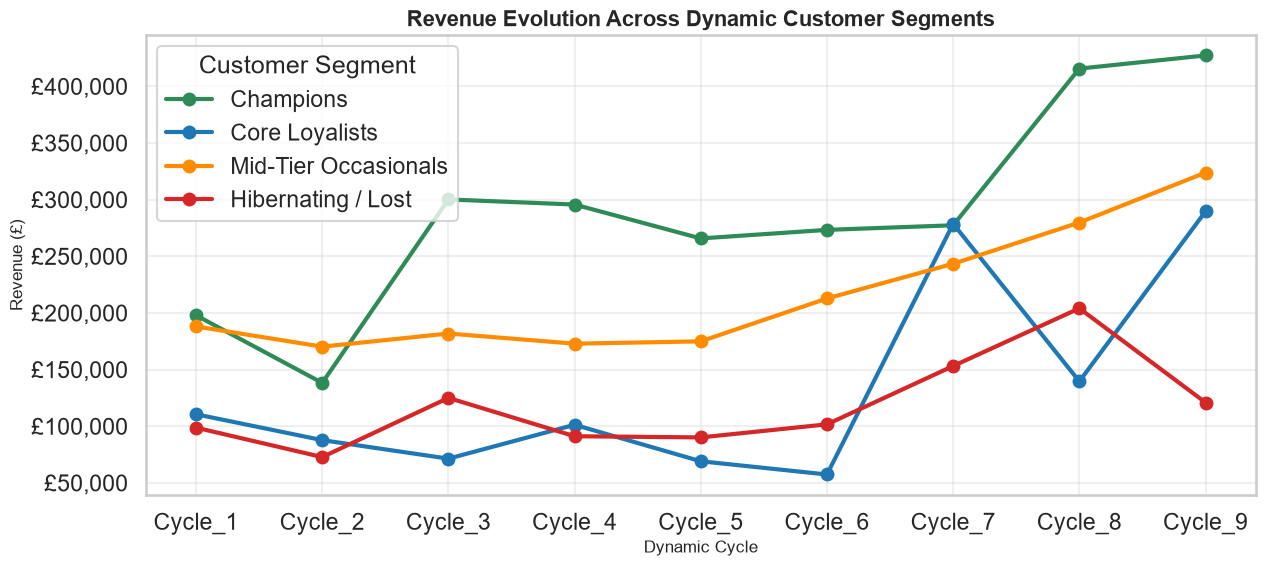

In [138]:
# ============================================================
# PHASE 9D - CELL 1
# Revenue Evolution by Customer Segment
# ============================================================

import matplotlib.ticker as mtick

revenue = (

    segment_summary

    .pivot(

        index="CycleID",

        columns="Segment_Name",

        values="Revenue"

    )

)

# Keep dissertation order
segment_order = [

    "Champions",

    "Core Loyalists",

    "Mid-Tier Occasionals",

    "Hibernating / Lost"

]

revenue = revenue.reindex(columns=segment_order)

plt.figure(figsize=(13,6))

for segment in revenue.columns:

    plt.plot(

        revenue.index,

        revenue[segment],

        marker="o",

        linewidth=3,

        color=SEGMENT_COLOURS[segment],

        label=segment

    )

plt.legend(title="Customer Segment")

plt.gca().yaxis.set_major_formatter(

    mtick.StrMethodFormatter("£{x:,.0f}")

)

format_plot(

    title="Revenue Evolution Across Dynamic Customer Segments",

    xlabel="Dynamic Cycle",

    ylabel="Revenue (£)",

    filename="Dynamic_Analytics/Revenue_Evolution_By_Segment"

)

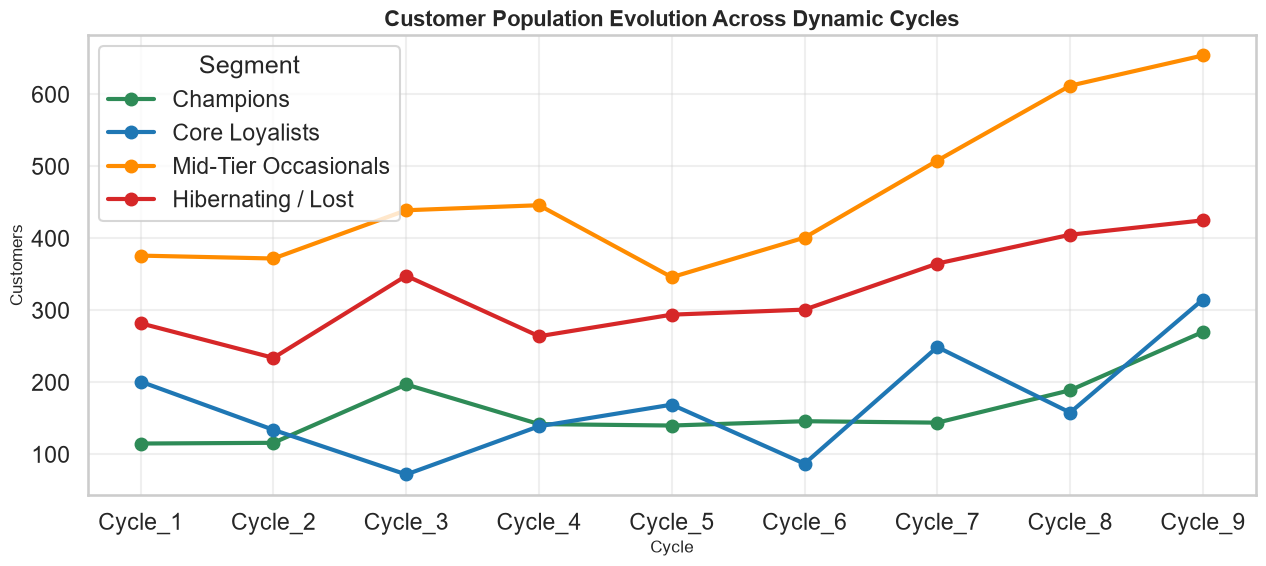

In [139]:
population = (

    segment_summary

    .pivot(

        index="CycleID",

        columns="Segment_Name",

        values="Customers"

    )

)

population = population.reindex(columns=segment_order)

plt.figure(figsize=(13,6))

for segment in population.columns:

    plt.plot(

        population.index,

        population[segment],

        marker="o",

        linewidth=3,

        color=SEGMENT_COLOURS[segment],

        label=segment

    )

plt.legend(title="Segment")

format_plot(

    title="Customer Population Evolution Across Dynamic Cycles",

    xlabel="Cycle",

    ylabel="Customers",

    filename="Dynamic_Analytics/Population_Evolution"

)

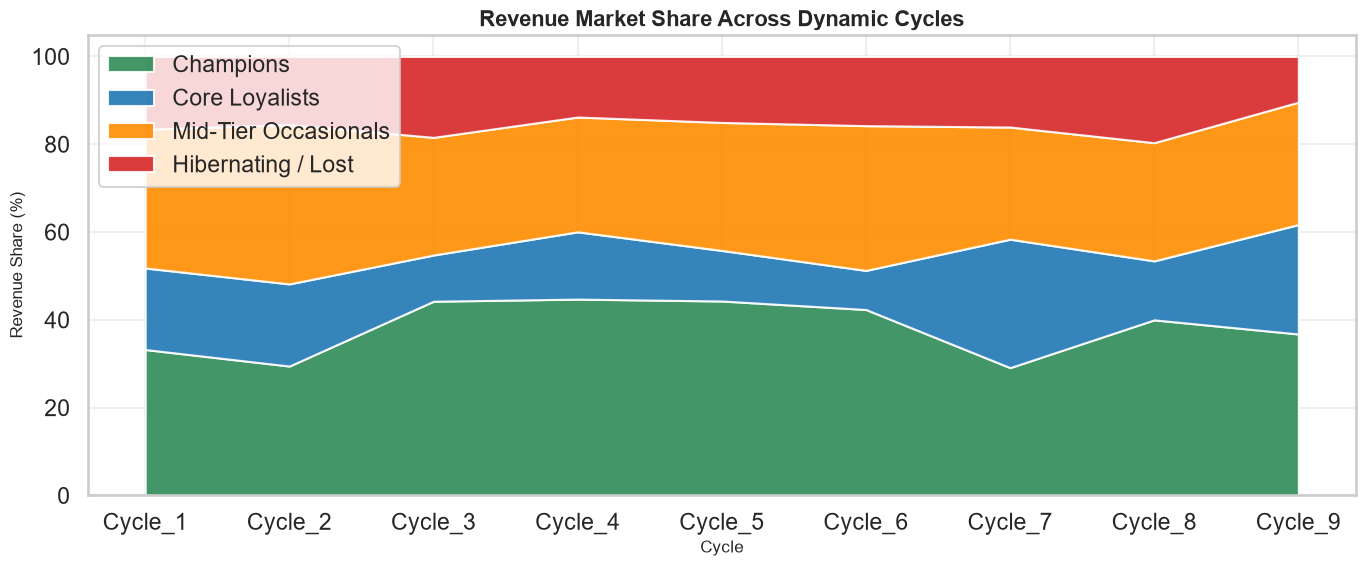

In [140]:
# ============================================================
# PHASE 9D - CELL 3
# Revenue Market Share Evolution
# ============================================================

market_share = segment_summary.copy()

market_share["Revenue Share"] = (

    market_share["Revenue"]

    /

    market_share.groupby("CycleID")["Revenue"].transform("sum")

    * 100

)

pivot = market_share.pivot(

    index="CycleID",

    columns="Segment_Name",

    values="Revenue Share"

)

pivot = pivot.reindex(columns=segment_order)

colors = [

    SEGMENT_COLOURS[s]

    for s in segment_order

]

plt.figure(figsize=(14,6))

plt.stackplot(

    pivot.index,

    *[pivot[col] for col in pivot.columns],

    labels=pivot.columns,

    colors=colors,

    alpha=0.9

)

plt.legend(loc="upper left")

format_plot(

    "Revenue Market Share Across Dynamic Cycles",

    "Cycle",

    "Revenue Share (%)",

    "Dynamic_Analytics/Revenue_Market_Share"

)

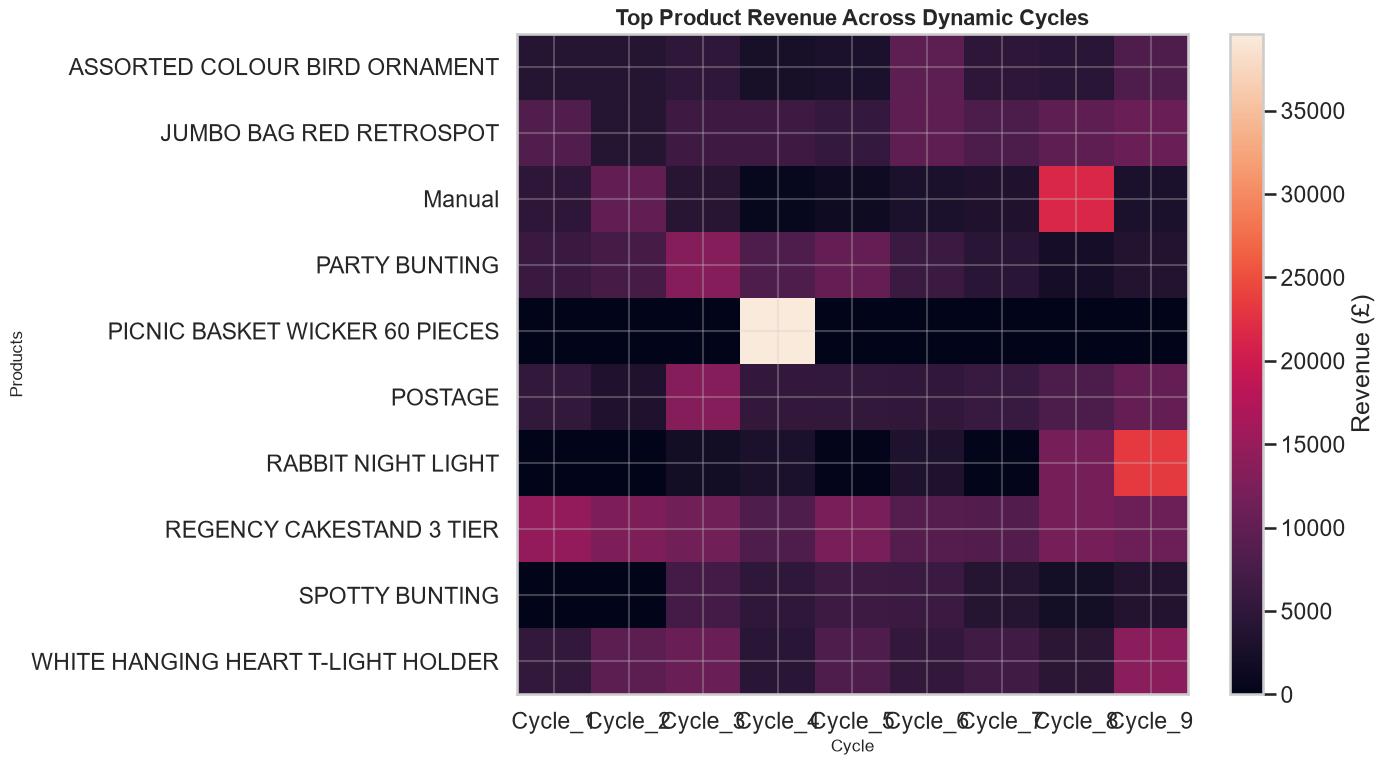

In [141]:
top_products = (

    product_summary

    .groupby("Description")["Revenue"]

    .sum()

    .nlargest(10)

    .index

)

heatmap = (

    product_summary[

        product_summary["Description"].isin(top_products)

    ]

    .groupby(

        [

            "Description",

            "CycleID"

        ]

    )["Revenue"]

    .sum()

    .unstack(fill_value=0)

)

plt.figure(figsize=(14,8))

plt.imshow(

    heatmap,

    aspect="auto"

)

plt.colorbar(label="Revenue (£)")

plt.xticks(

    range(len(heatmap.columns)),

    heatmap.columns

)

plt.yticks(

    range(len(heatmap.index)),

    heatmap.index

)

format_plot(

    "Top Product Revenue Across Dynamic Cycles",

    "Cycle",

    "Products",

    "Dynamic_Analytics/Product_Heatmap"

)

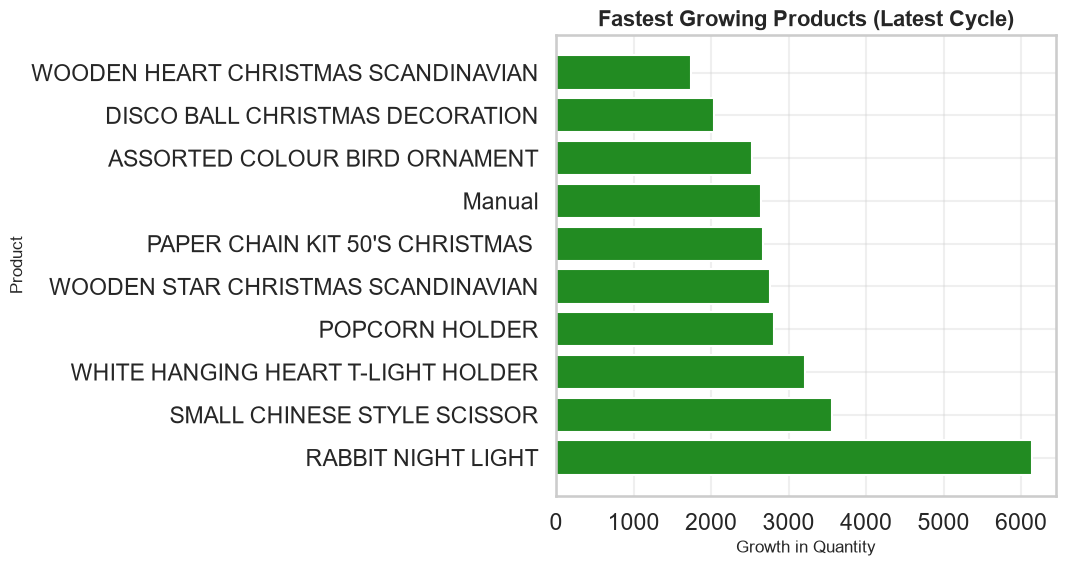

In [142]:
growth = (

    product_summary

    .groupby(

        [

            "CycleID",

            "Description"

        ]

    )["Quantity_Sold"]

    .sum()

    .unstack(fill_value=0)

)

growth = growth.diff().fillna(0)

latest_growth = (

    growth.iloc[-1]

    .sort_values(

        ascending=False

    )

    .head(10)

)

plt.figure(figsize=(11,6))

plt.barh(

    latest_growth.index,

    latest_growth.values,

    color="forestgreen"

)

format_plot(

    "Fastest Growing Products (Latest Cycle)",

    "Growth in Quantity",

    "Product",

    "Dynamic_Analytics/Fastest_Growing"

)

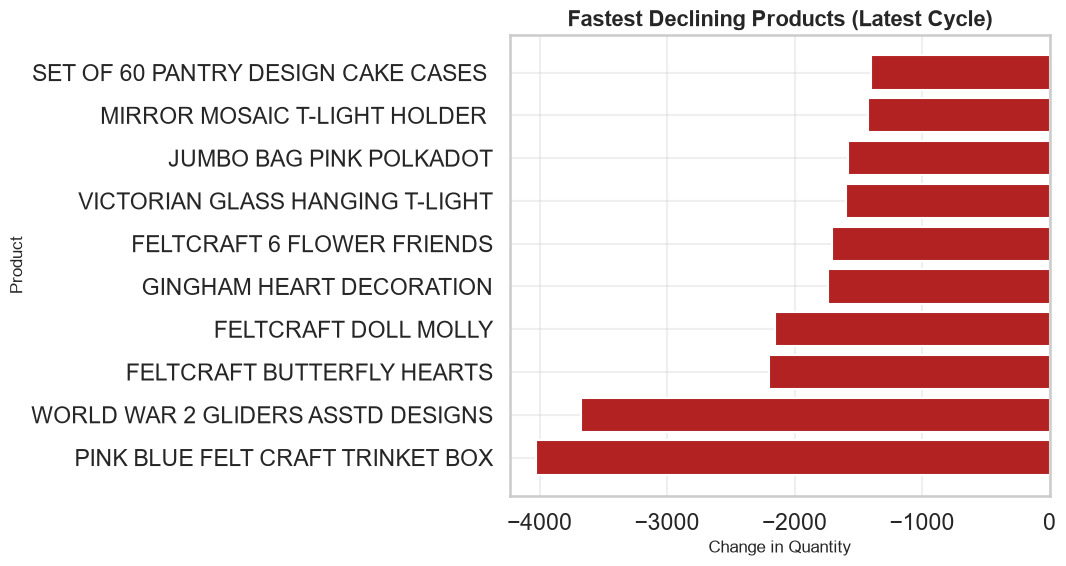

In [143]:
decline = (

    growth.iloc[-1]

    .sort_values()

    .head(10)

)

plt.figure(figsize=(11,6))

plt.barh(

    decline.index,

    decline.values,

    color="firebrick"

)

format_plot(

    "Fastest Declining Products (Latest Cycle)",

    "Change in Quantity",

    "Product",

    "Dynamic_Analytics/Fastest_Declining"

)

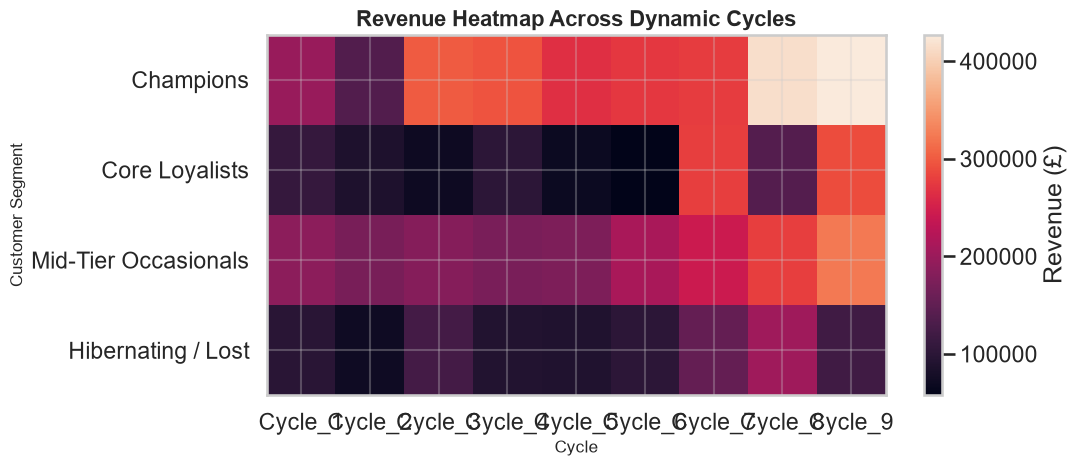

In [144]:
heat = (

    segment_summary

    .pivot(

        index="Segment_Name",

        columns="CycleID",

        values="Revenue"

    )

)

heat = heat.reindex(segment_order)

plt.figure(figsize=(11,5))

plt.imshow(

    heat,

    aspect="auto"

)

plt.colorbar(label="Revenue (£)")

plt.xticks(

    range(len(heat.columns)),

    heat.columns

)

plt.yticks(

    range(len(heat.index)),

    heat.index

)

format_plot(

    "Revenue Heatmap Across Dynamic Cycles",

    "Cycle",

    "Customer Segment",

    "Dynamic_Analytics/Revenue_Heatmap"

)

,Revenue,Basket,Orders
Migration_Status,,,
Migrated,594.757409,417.651340,1.345511
Stable,1217.306984,495.413439,1.981104


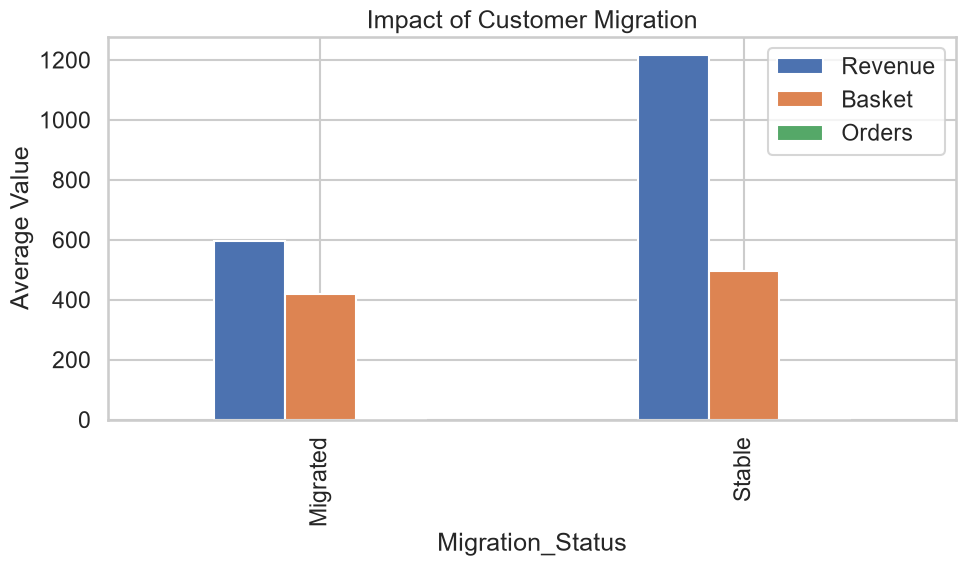

In [145]:
migration = (

    customer_summary

    .groupby(

        "Migration_Status"

    )

    .agg(

        Revenue=("Revenue","mean"),

        Basket=("Average_Basket_Value","mean"),

        Orders=("Orders","mean")

    )

)

display(migration)

migration.plot(

    kind="bar",

    figsize=(10,6)

)

plt.ylabel("Average Value")

plt.title("Impact of Customer Migration")

plt.tight_layout()

plt.show()

In [146]:
dashboard = pd.DataFrame({

    "KPI":[

        "Highest Revenue Cycle",

        "Highest Spending Segment",

        "Largest Customer Segment",

        "Most Popular Product",

        "Highest Revenue Product",

        "Highest Avg Basket"

    ],

    "Value":[

        segment_summary.groupby("CycleID")["Revenue"].sum().idxmax(),

        segment_summary.groupby("Segment_Name")["Revenue"].sum().idxmax(),

        segment_summary.groupby("Segment_Name")["Customers"].sum().idxmax(),

        product_summary.groupby("Description")["Quantity_Sold"].sum().idxmax(),

        product_summary.groupby("Description")["Revenue"].sum().idxmax(),

        customer_summary["Average_Basket_Value"].max()

    ]

})

display(dashboard)

,KPI,Value
0,Highest Revenue Cycle,Cycle_9
1,Highest Spending Segment,Champions
2,Largest Customer Segment,Mid-Tier Occasionals
3,Most Popular Product,WORLD WAR 2 GLIDERS ASSTD DESIGNS
4,Highest Revenue Product,REGENCY CAKESTAND 3 TIER
5,Highest Avg Basket,21880.44


In [147]:
print("="*80)
print("EXECUTIVE BUSINESS SUMMARY")
print("="*80)

print()

print(

    f"Highest Revenue Cycle : "

    f"{dashboard.iloc[0,1]}"

)

print(

    f"Highest Spending Segment : "

    f"{dashboard.iloc[1,1]}"

)

print(

    f"Largest Customer Segment : "

    f"{dashboard.iloc[2,1]}"

)

print(

    f"Most Popular Product : "

    f"{dashboard.iloc[3,1]}"

)

print(

    f"Highest Revenue Product : "

    f"{dashboard.iloc[4,1]}"

)

print("="*80)

EXECUTIVE BUSINESS SUMMARY

Highest Revenue Cycle : Cycle_9
Highest Spending Segment : Champions
Largest Customer Segment : Mid-Tier Occasionals
Most Popular Product : WORLD WAR 2 GLIDERS ASSTD DESIGNS
Highest Revenue Product : REGENCY CAKESTAND 3 TIER


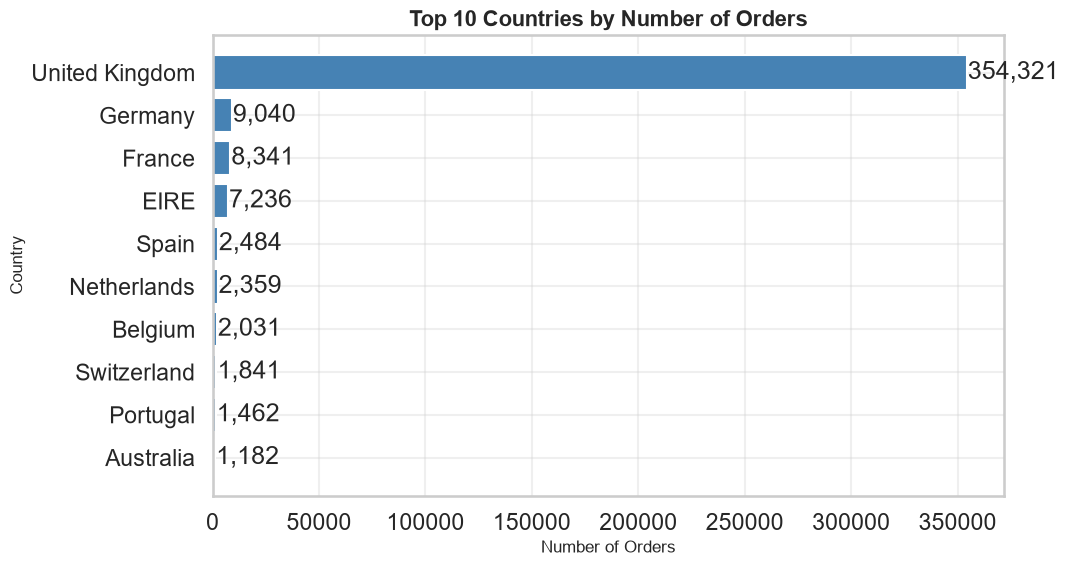

In [148]:
# ============================================================
# PHASE 9 - CELL X
# Top 10 Countries by Orders
# ============================================================

country_orders = (

    df_retail

    .groupby("Country")

    .size()

    .sort_values(ascending=False)

    .head(10)

)

plt.figure(figsize=(11,6))

plt.barh(

    country_orders.index[::-1],

    country_orders.values[::-1],

    color="steelblue"

)

for i, value in enumerate(country_orders.values[::-1]):

    plt.text(

        value + 500,

        i,

        f"{value:,}",

        va="center"

    )

format_plot(

    title="Top 10 Countries by Number of Orders",

    xlabel="Number of Orders",

    ylabel="Country",

    filename="Business_Analytics/Top10_Countries"

)

<Figure size 1100x600 with 0 Axes>

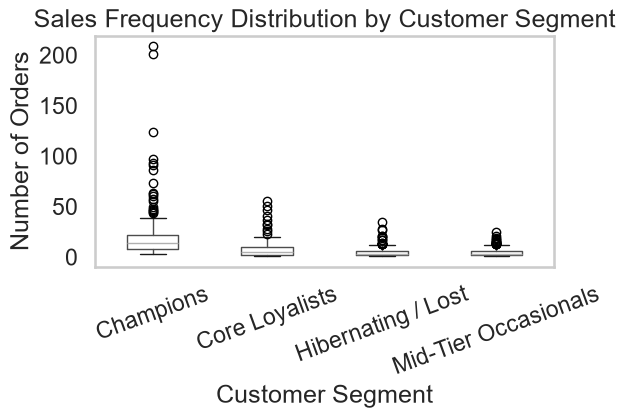

In [149]:
# ============================================================
# PHASE 9 - CELL X
# Sales Frequency Distribution by Segment
# ============================================================

sales_frequency = (

    business_df

    .groupby(

        [

            "CustomerID",

            "Segment_Name"

        ]

    )

    .agg(

        Orders=("InvoiceNo","nunique")

    )

    .reset_index()

)

plt.figure(figsize=(11,6))

sales_frequency.boxplot(

    column="Orders",

    by="Segment_Name",

    grid=False,

    rot=20

)

plt.suptitle("")

plt.title("Sales Frequency Distribution by Customer Segment")

plt.xlabel("Customer Segment")

plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

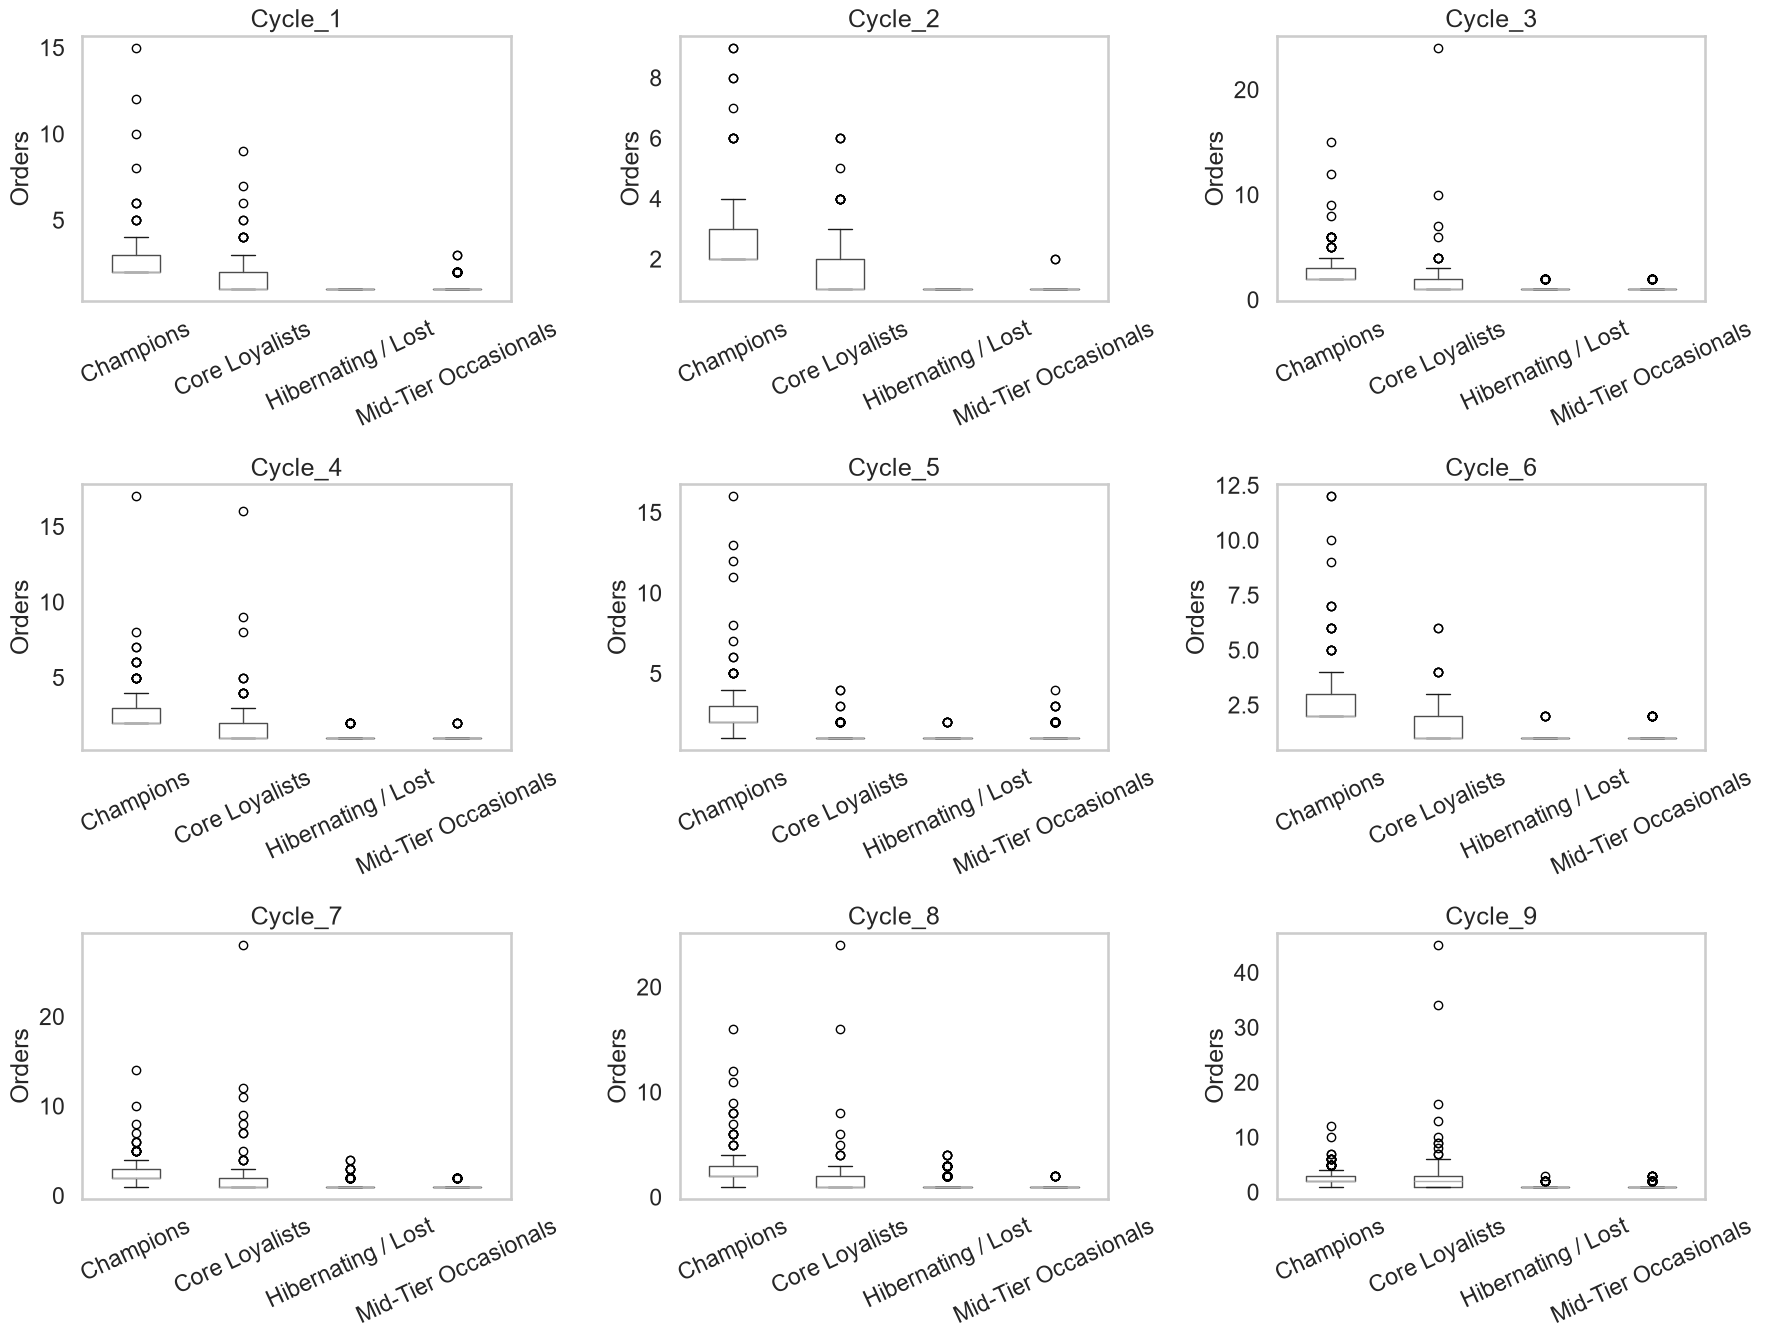

In [150]:
# ============================================================
# PHASE 9D - CELL X
# Sales Frequency Distribution by Segment Across Cycles
# ============================================================

orders = (

    dynamic_business_df

    .groupby(

        [

            "CycleID",
            "Segment_Name",
            "CustomerID"

        ]

    )

    .agg(

        Orders=("InvoiceNo","nunique")

    )

    .reset_index()

)

cycle_order = [

    "Cycle_1",
    "Cycle_2",
    "Cycle_3",
    "Cycle_4",
    "Cycle_5",
    "Cycle_6",
    "Cycle_7",
    "Cycle_8",
    "Cycle_9"

]

orders["CycleID"] = pd.Categorical(

    orders["CycleID"],

    categories=cycle_order,

    ordered=True

)

fig, axes = plt.subplots(

    3,

    3,

    figsize=(18,14)

)

axes = axes.flatten()

for i, cycle in enumerate(cycle_order):

    data = orders[

        orders["CycleID"] == cycle

    ]

    data.boxplot(

        column="Orders",

        by="Segment_Name",

        ax=axes[i],

        grid=False,

        rot=25

    )

    axes[i].set_title(cycle)

    axes[i].set_xlabel("")

    axes[i].set_ylabel("Orders")

plt.suptitle("")

plt.tight_layout()

plt.show()

### Phase 10 Geographic Segmentation Analytics

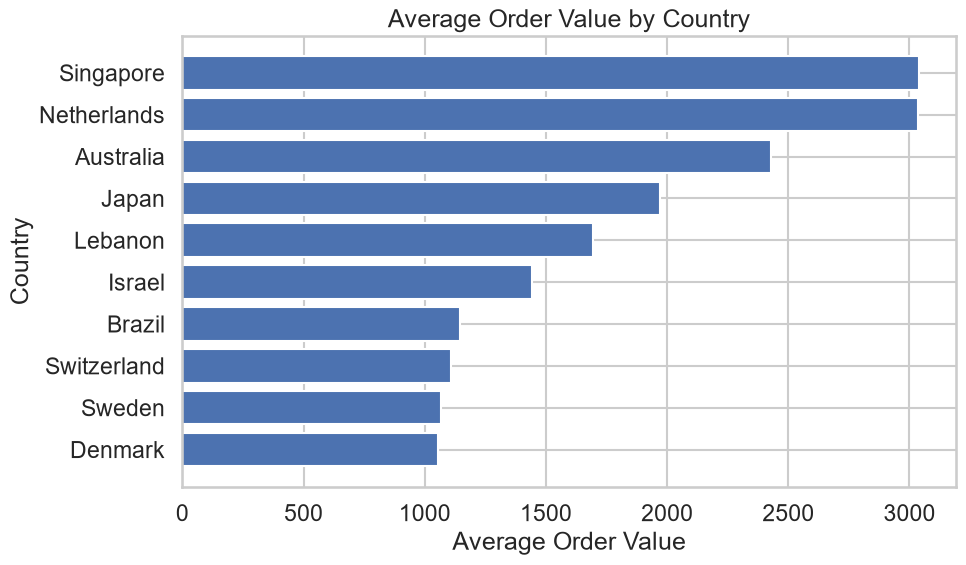

In [161]:
top10 = country_aov.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top10.index,
    top10.values
)

plt.xlabel('Average Order Value')
plt.ylabel('Country')
plt.title('Average Order Value by Country')

plt.tight_layout()
plt.show()

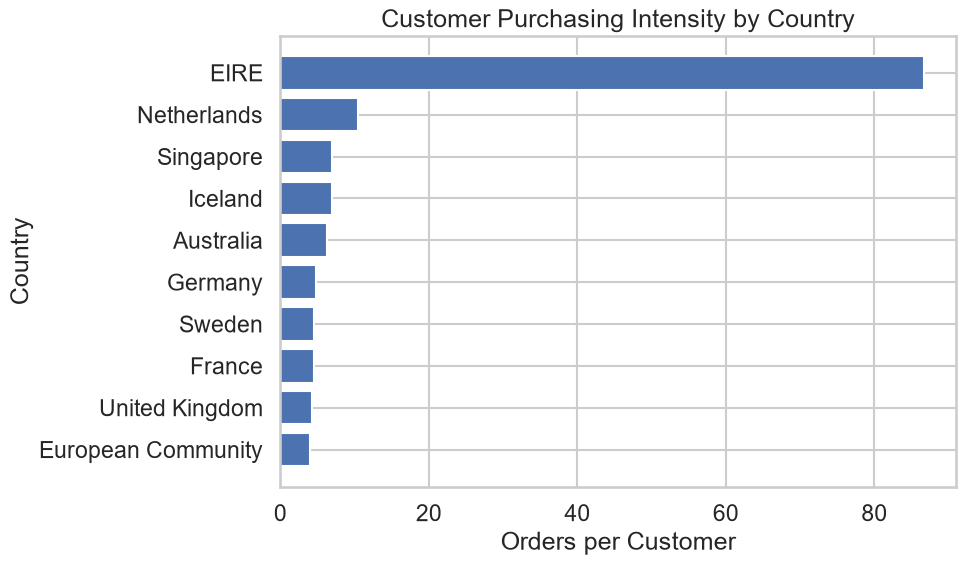

In [163]:
top10 = orders_per_customer.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top10.index,
    top10.values
)

plt.xlabel('Orders per Customer')
plt.ylabel('Country')
plt.title('Customer Purchasing Intensity by Country')

plt.tight_layout()
plt.show()

In [166]:
# Safely list all DataFrames currently available

dataframes = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        dataframes.append(
            (name, obj.shape, list(obj.columns))
        )

for name, shape, columns in dataframes:
    print(f"\n{name}: {shape}")
    print("Columns:", columns)


df_retail: (397884, 10)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Total_Price', 'YearMonth']

cycle_df: (17304, 9)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Total_Price']

baseline_rfm: (1682, 17)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Recency_Bucket', 'Log_R', 'Log_F', 'Log_M', 'RF_Score', 'RM_Score', 'FM_Score', 'Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M', 'Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score']

firmographic_df: (4338, 2)
Columns: ['CustomerID', 'Country']

rfm_df: (615, 17)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Recency_Bucket', 'Log_R', 'Log_F', 'Log_M', 'RF_Score', 'RM_Score', 'FM_Score', 'Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M', 'Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score']

insert_df: (1682, 10)
Columns: ['CustomerID', 'Optimal_K_Value', 'Elbow_Inert

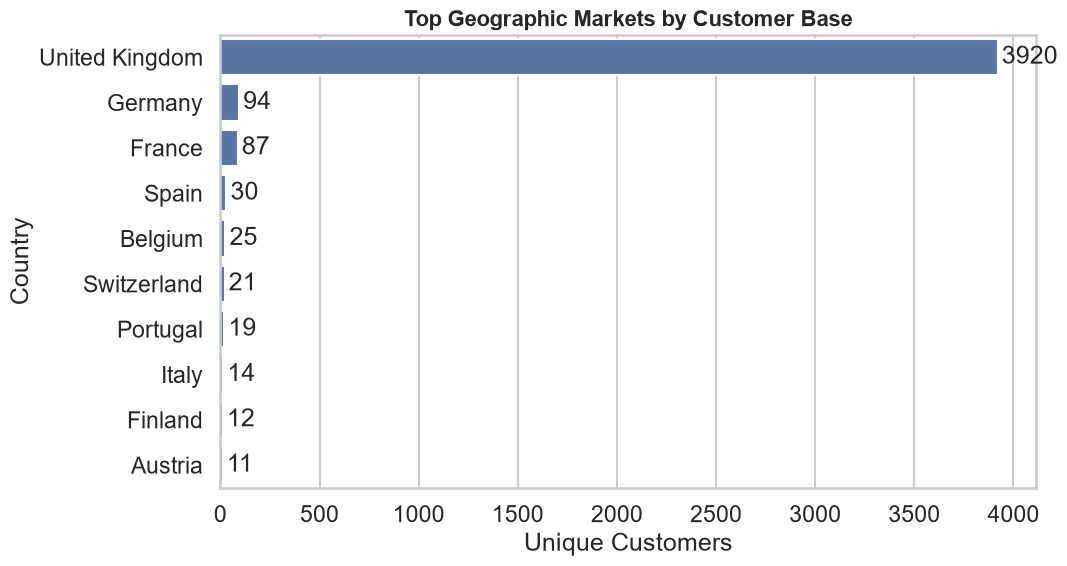

In [193]:
# ============================================================
# PHASE 10 - CELL 1
# Geographic Market Size
# ============================================================

geo_market = (
    df_retail
    .groupby('Country')
    .agg(
        Customers=('CustomerID', 'nunique'),
        Transactions=('InvoiceNo', 'nunique'),
        Products=('StockCode', 'nunique')
    )
    .reset_index()
)

# Remove missing / invalid countries
geo_market = geo_market[
    geo_market['Country'].notna()
].copy()

# Sort by customers
geo_market = geo_market.sort_values(
    'Customers',
    ascending=False
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=geo_market.head(10),
    y='Country',
    x='Customers'
)

plt.title(
    'Top Geographic Markets by Customer Base',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Unique Customers')
plt.ylabel('Country')

# Add values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

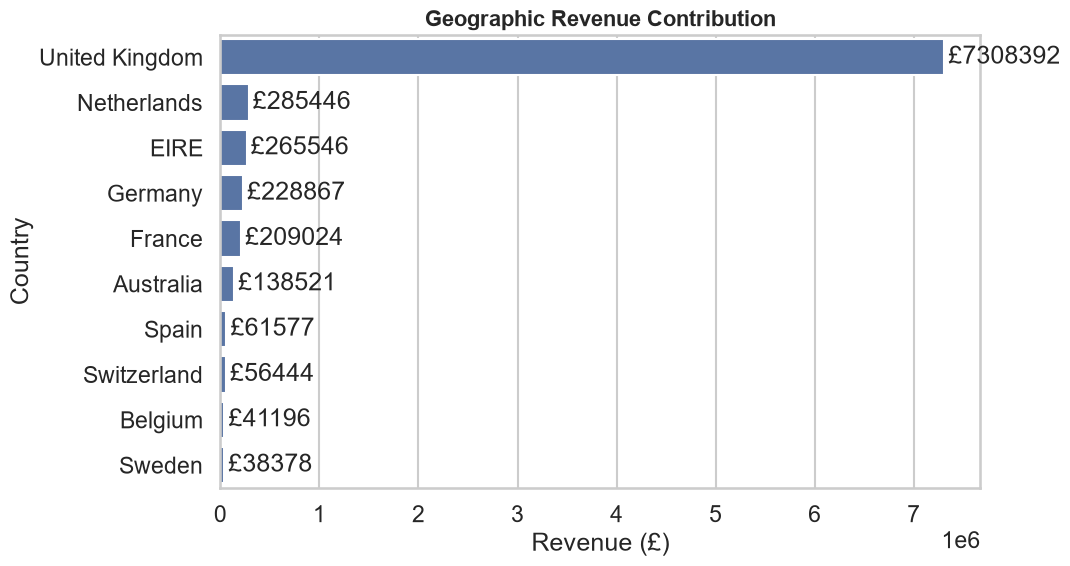

In [194]:
# ============================================================
# PHASE 10 - CELL 2
# Geographic Revenue Contribution
# ============================================================

df_geo_revenue = df_retail.copy()

# Calculate transaction revenue
df_geo_revenue['Revenue'] = (
    df_geo_revenue['Quantity'] *
    df_geo_revenue['UnitPrice']
)

country_revenue = (
    df_geo_revenue
    .groupby('Country')
    .agg(
        Revenue=('Revenue', 'sum'),
        Transactions=('InvoiceNo', 'nunique'),
        Customers=('CustomerID', 'nunique')
    )
    .reset_index()
)

country_revenue = country_revenue[
    country_revenue['Country'].notna()
]

country_revenue = country_revenue.sort_values(
    'Revenue',
    ascending=False
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=country_revenue.head(10),
    y='Country',
    x='Revenue'
)

plt.title(
    'Geographic Revenue Contribution',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Revenue (£)')
plt.ylabel('Country')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='£%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

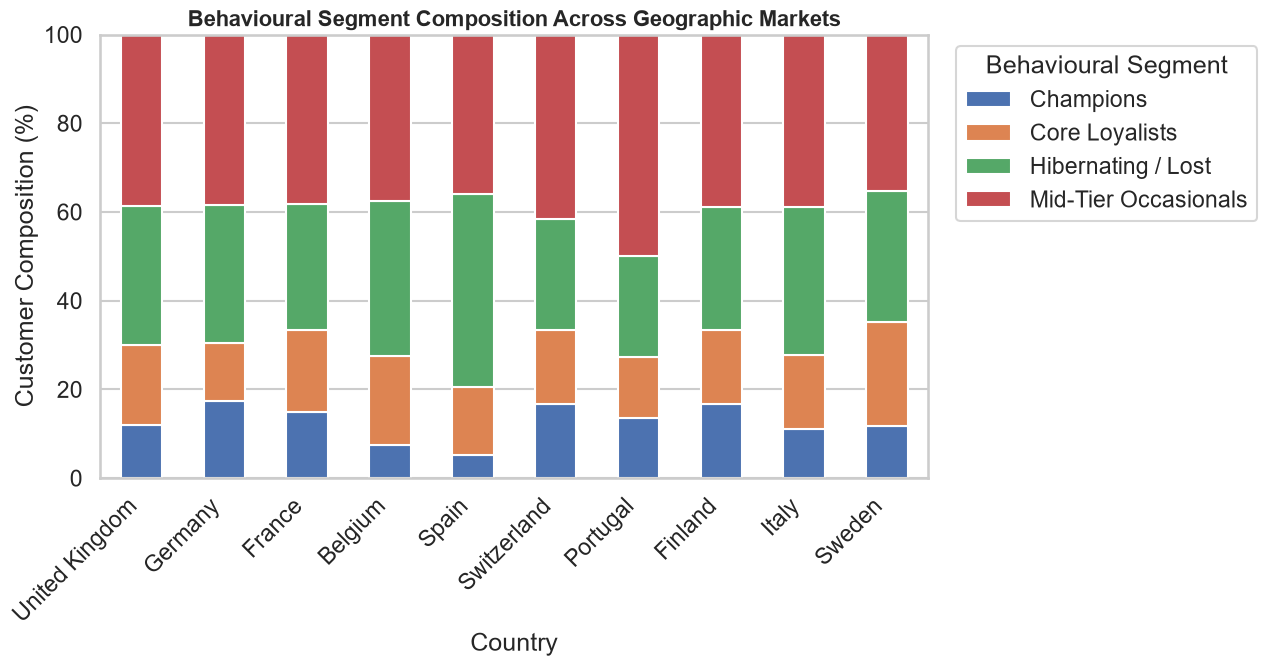

In [203]:
# ============================================================
# PHASE 10 - CELL 3
# Geographic × Behavioural Segment Composition
# ============================================================

# Count unique customers by Country and Segment
geo_segment = (
    geo_segments
    .groupby(['Country', 'Segment_Name'])['CustomerID']
    .nunique()
    .reset_index(name='Customers')
)

# Remove missing countries
geo_segment = geo_segment[
    geo_segment['Country'].notna()
].copy()

# Calculate percentage within each country
geo_segment['Percentage'] = (
    geo_segment['Customers']
    /
    geo_segment.groupby('Country')['Customers']
    .transform('sum')
) * 100

# ------------------------------------------------------------
# Select the 10 largest geographic markets
# ------------------------------------------------------------

country_totals = (
    geo_segment
    .groupby('Country')['Customers']
    .sum()
    .sort_values(ascending=False)
)

top_countries = country_totals.head(10).index.tolist()

plot_data = geo_segment[
    geo_segment['Country'].isin(top_countries)
].copy()

# ------------------------------------------------------------
# Order countries from largest to smallest
# ------------------------------------------------------------

plot_data['Country'] = pd.Categorical(
    plot_data['Country'],
    categories=top_countries,
    ordered=True
)

# ------------------------------------------------------------
# Convert to wide format
# ------------------------------------------------------------

segment_pct = (
    plot_data
    .pivot(
        index='Country',
        columns='Segment_Name',
        values='Percentage'
    )
    .fillna(0)
)

# Make sure countries remain in correct order
segment_pct = segment_pct.reindex(top_countries)

# ------------------------------------------------------------
# Plot 100% stacked bar chart
# ------------------------------------------------------------

ax = segment_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(13, 7)
)

plt.title(
    'Behavioural Segment Composition Across Geographic Markets',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Country')
plt.ylabel('Customer Composition (%)')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.ylim(0, 100)

plt.legend(
    title='Behavioural Segment',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

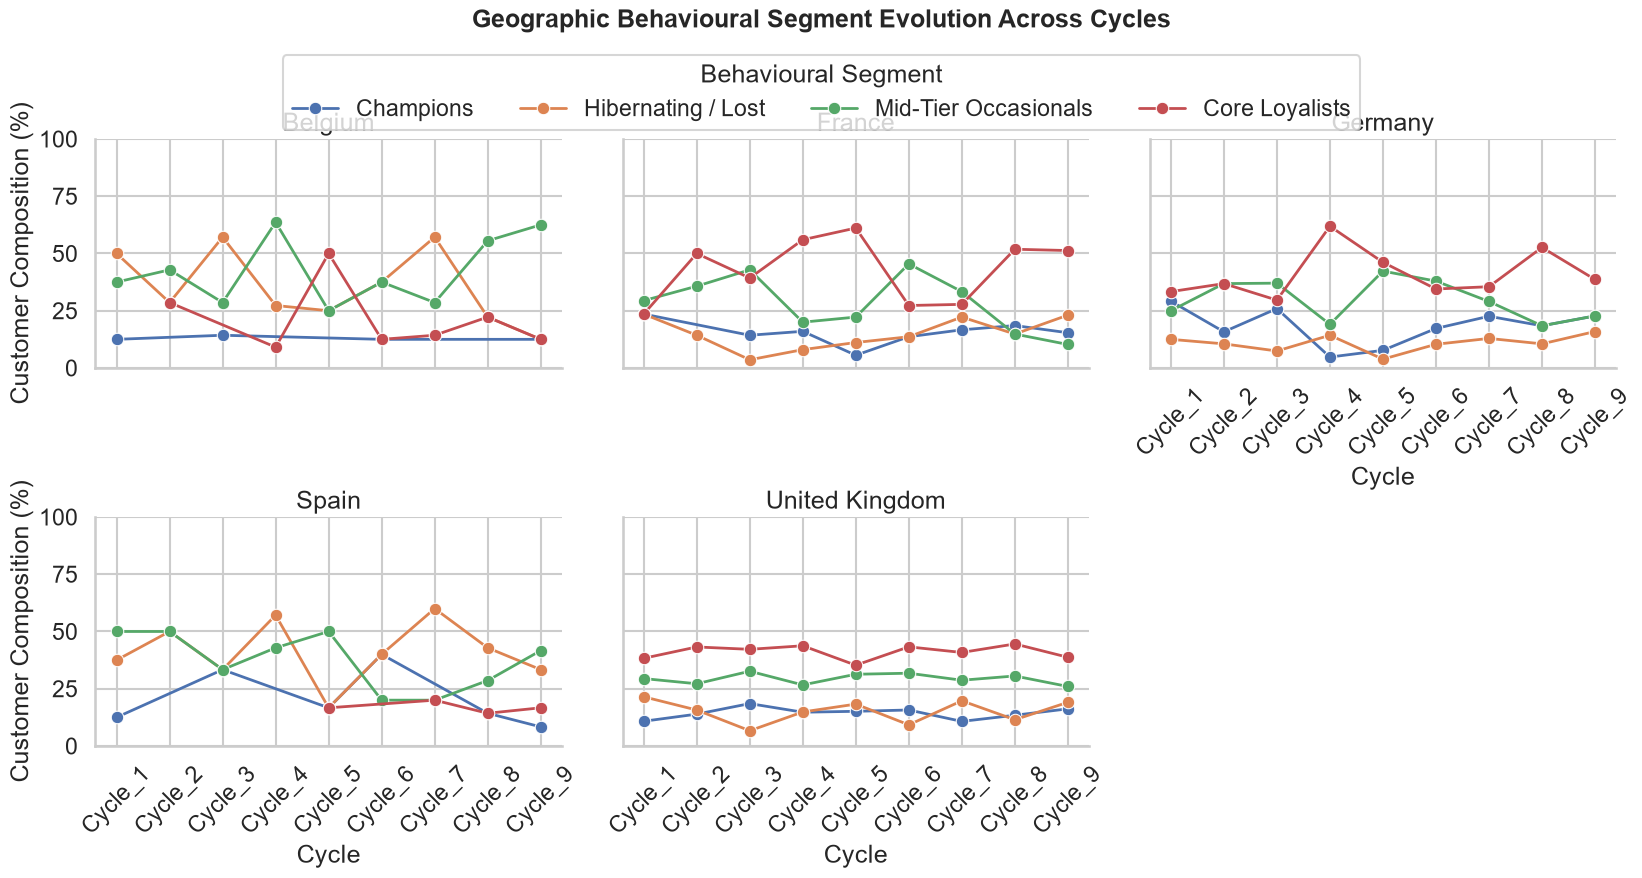

In [197]:
# ============================================================
# PHASE 10 - CELL 4
# Geographic × Segment × Cycle
# ============================================================

geo_cycle_segment = (
    geo_segments
    .groupby(
        ['CycleID', 'Country', 'Segment_Name']
    )['CustomerID']
    .nunique()
    .reset_index(name='Customers')
)

# Calculate percentage within Country + Cycle
geo_cycle_segment['Percentage'] = (
    geo_cycle_segment['Customers']
    /
    geo_cycle_segment.groupby(
        ['CycleID', 'Country']
    )['Customers']
    .transform('sum')
) * 100

# Select top 5 geographic markets
top_geo_countries = (
    geo_cycle_segment
    .groupby('Country')['Customers']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plot_geo_cycle = geo_cycle_segment[
    geo_cycle_segment['Country'].isin(top_geo_countries)
].copy()

# Correct cycle ordering
cycle_order = sorted(
    plot_geo_cycle['CycleID'].unique(),
    key=lambda x: int(str(x).split('_')[-1])
)

plot_geo_cycle['CycleID'] = pd.Categorical(
    plot_geo_cycle['CycleID'],
    categories=cycle_order,
    ordered=True
)

# Plot
g = sns.FacetGrid(
    plot_geo_cycle,
    col='Country',
    col_wrap=3,
    height=4.3,
    aspect=1.3,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x='CycleID',
    y='Percentage',
    hue='Segment_Name',
    marker='o',
    linewidth=2
)

g.set_axis_labels(
    'Cycle',
    'Customer Composition (%)'
)

g.set_titles(
    col_template='{col_name}'
)

for ax in g.axes.flat:
    ax.tick_params(
        axis='x',
        rotation=45
    )
    ax.set_ylim(0, 100)

# Overall title
g.fig.suptitle(
    'Geographic Behavioural Segment Evolution Across Cycles',
    fontsize=18,
    fontweight='bold',
    y=1.03
)

# Clean legend
handles, labels = g.axes.flat[0].get_legend_handles_labels()

if g.axes.flat[0].legend_:
    g.axes.flat[0].legend_.remove()

g.fig.legend(
    handles,
    labels,
    title='Behavioural Segment',
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=4
)

plt.tight_layout()
plt.show()

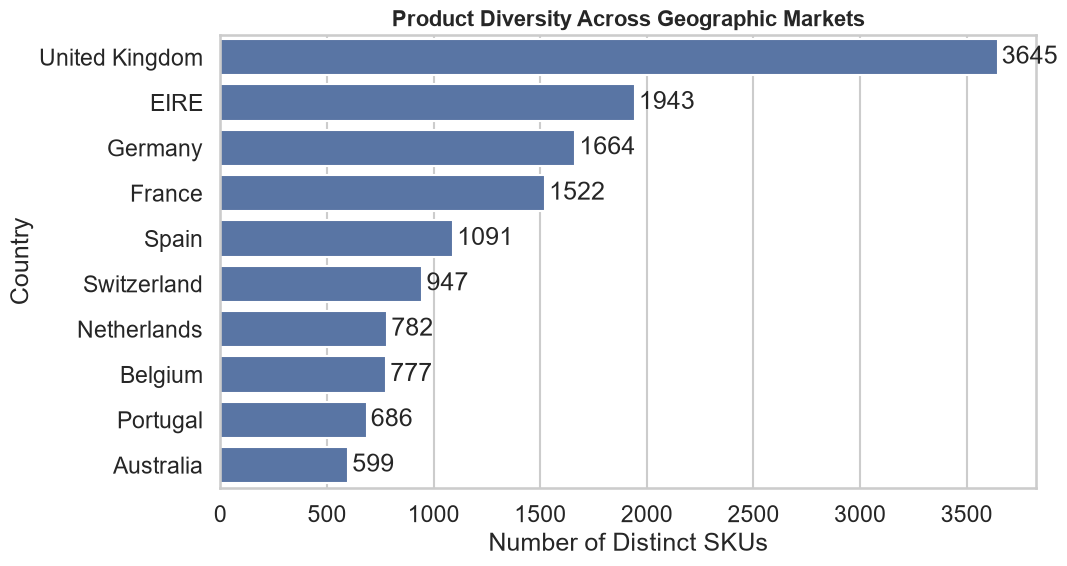

In [198]:
# ============================================================
# PHASE 10 - CELL 5
# Geographic Product / SKU Diversity
# ============================================================

geo_products = (
    df_retail
    .groupby('Country')
    .agg(
        Unique_SKUs=('StockCode', 'nunique'),
        Transactions=('InvoiceNo', 'nunique'),
        Customers=('CustomerID', 'nunique')
    )
    .reset_index()
)

geo_products = geo_products[
    geo_products['Country'].notna()
]

geo_products = geo_products.sort_values(
    'Unique_SKUs',
    ascending=False
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=geo_products.head(10),
    y='Country',
    x='Unique_SKUs'
)

plt.title(
    'Product Diversity Across Geographic Markets',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Distinct SKUs')
plt.ylabel('Country')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

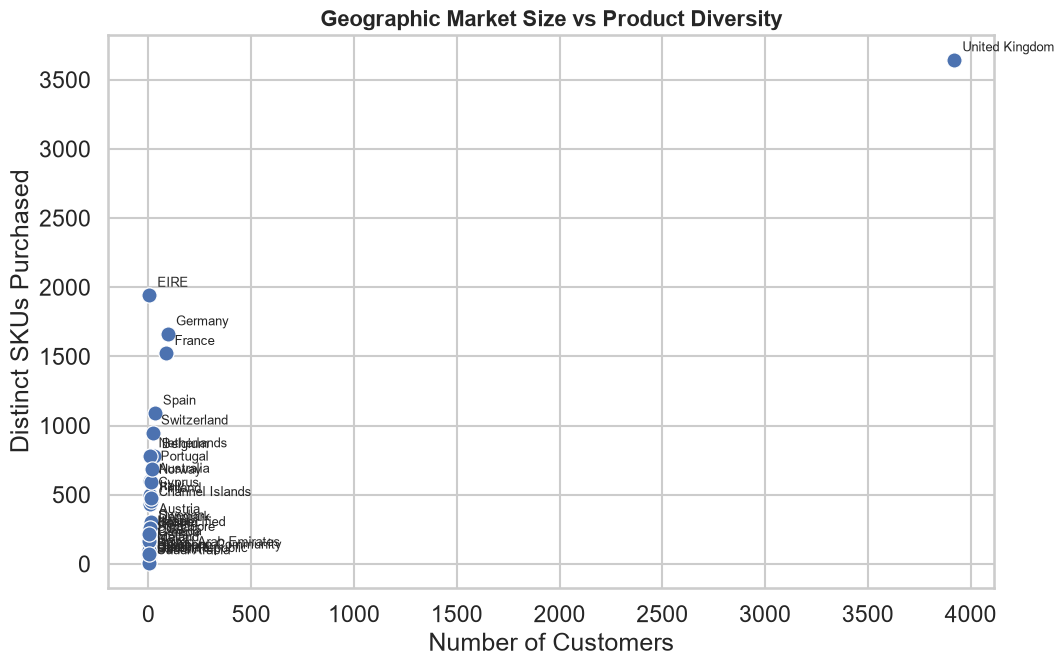

In [199]:
# ============================================================
# PHASE 10 - CELL 6
# Geographic Market Size vs Product Diversity
# ============================================================

geo_relationship = (
    df_retail
    .groupby('Country')
    .agg(
        Customers=('CustomerID', 'nunique'),
        Unique_SKUs=('StockCode', 'nunique'),
        Transactions=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

geo_relationship = geo_relationship[
    geo_relationship['Country'].notna()
]

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=geo_relationship,
    x='Customers',
    y='Unique_SKUs',
    s=120
)

# Add country labels
for _, row in geo_relationship.iterrows():

    plt.annotate(
        row['Country'],
        (
            row['Customers'],
            row['Unique_SKUs']
        ),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=9
    )

plt.title(
    'Geographic Market Size vs Product Diversity',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Customers')
plt.ylabel('Distinct SKUs Purchased')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PHASE 10 - CELL 7
# Average Revenue per Customer by Geographic Market
# ============================================================

geo_value = (
    df_retail
    .assign(
        Revenue=lambda x:
        x['Quantity'] * x['UnitPrice']
    )
    .groupby('Country')
    .agg(
        Revenue=('Revenue', 'sum'),
        Customers=('CustomerID', 'nunique')
    )
    .reset_index()
)

geo_value = geo_value[
    geo_value['Customers'] > 0
]

geo_value['Revenue_per_Customer'] = (
    geo_value['Revenue']
    /
    geo_value['Customers']
)

geo_value = geo_value.sort_values(
    'Revenue_per_Customer',
    ascending=False
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=geo_value.head(10),
    y='Country',
    x='Revenue_per_Customer'
)

plt.title(
    'Average Revenue per Customer Across Geographic Markets',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Average Revenue per Customer (£)')
plt.ylabel('Country')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='£%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

Segment_Name,Champions,Core Loyalists,Hibernating / Lost,Mid-Tier Occasionals
Country,,,,
Australia,14.29,21.43,21.43,42.86
Austria,0.00,20.00,20.00,60.00
Bahrain,0.00,0.00,50.00,50.00
Belgium,7.50,20.00,35.00,37.50
Brazil,0.00,0.00,0.00,100.00
Canada,0.00,0.00,40.00,60.00
Channel Islands,30.77,0.00,30.77,38.46
Cyprus,0.00,16.67,16.67,66.67
Czech Republic,0.00,0.00,0.00,100.00


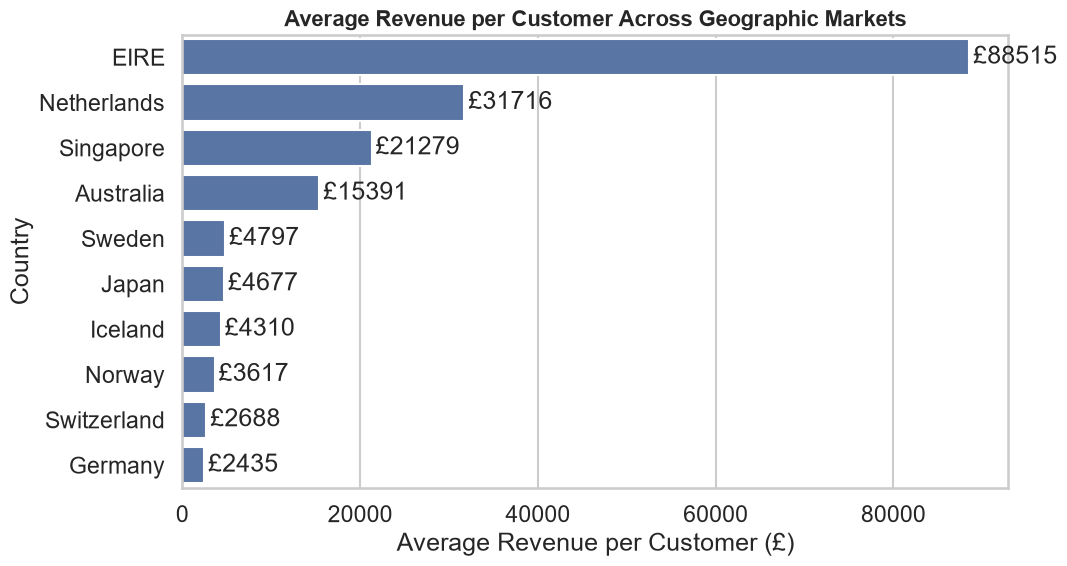

In [201]:
# ============================================================
# PHASE 10 - CELL 7
# Average Revenue per Customer by Geographic Market
# ============================================================

geo_value = (
    df_retail
    .assign(
        Revenue=lambda x:
        x['Quantity'] * x['UnitPrice']
    )
    .groupby('Country')
    .agg(
        Revenue=('Revenue', 'sum'),
        Customers=('CustomerID', 'nunique')
    )
    .reset_index()
)

geo_value = geo_value[
    geo_value['Customers'] > 0
]

geo_value['Revenue_per_Customer'] = (
    geo_value['Revenue']
    /
    geo_value['Customers']
)

geo_value = geo_value.sort_values(
    'Revenue_per_Customer',
    ascending=False
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=geo_value.head(10),
    y='Country',
    x='Revenue_per_Customer'
)

plt.title(
    'Average Revenue per Customer Across Geographic Markets',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Average Revenue per Customer (£)')
plt.ylabel('Country')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='£%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

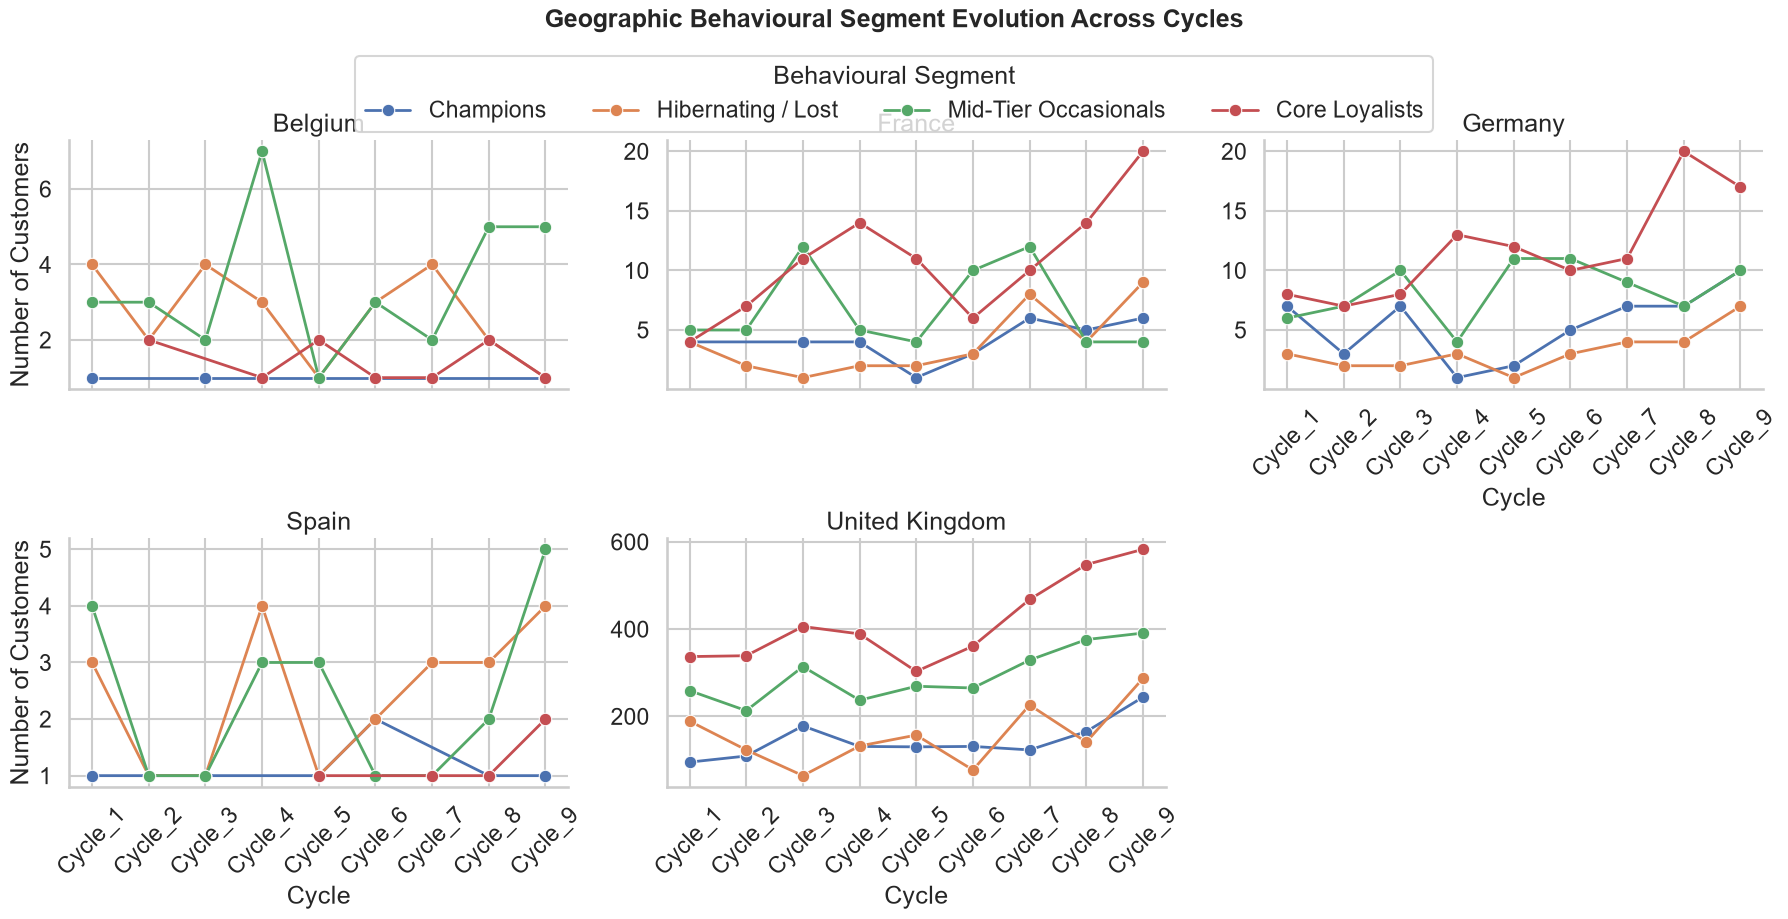

In [190]:
# ============================================================
# PHASE 10 - CELL 10
# Geographic × Segment × Cycle Visualisation
# ============================================================

# Select the 5 largest geographic markets
top_geo_countries = (
    country_customers
    .sort_values('Customers', ascending=False)
    .head(5)['Country']
    .tolist()
)

plot_geo_cycle = geo_segment_cycle[
    geo_segment_cycle['Country'].isin(top_geo_countries)
].copy()

# Make sure cycles are ordered correctly
cycle_order = sorted(
    plot_geo_cycle['CycleID'].unique(),
    key=lambda x: int(str(x).split('_')[-1])
)

plot_geo_cycle['CycleID'] = pd.Categorical(
    plot_geo_cycle['CycleID'],
    categories=cycle_order,
    ordered=True
)

# ------------------------------------------------------------
# Create one panel per country
# ------------------------------------------------------------

g = sns.FacetGrid(
    plot_geo_cycle,
    col='Country',
    col_wrap=3,
    height=4.5,
    aspect=1.35,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x='CycleID',
    y='Customers',
    hue='Segment_Name',
    marker='o',
    linewidth=2
)

# Axis labels
g.set_axis_labels(
    'Cycle',
    'Number of Customers'
)

# Rotate cycle labels
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

# Titles
g.set_titles(
    col_template='{col_name}'
)

# Overall title
g.fig.suptitle(
    'Geographic Behavioural Segment Evolution Across Cycles',
    fontsize=18,
    fontweight='bold',
    y=1.03
)

# Create one clean legend
handles, labels = g.axes.flat[0].get_legend_handles_labels()

if g.axes.flat[0].legend_:
    g.axes.flat[0].legend_.remove()

g.fig.legend(
    handles,
    labels,
    title='Behavioural Segment',
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=4
)

plt.tight_layout()
plt.show()

In [187]:
# ============================================================
# PHASE 10 - CELL 13
# Geographic × Behavioural Segment Revenue
# ============================================================

geo_segment_revenue = (
    dynamic_business_df
    .groupby(
        ['Country', 'Segment_Name']
    )
    .agg(
        Revenue=('Revenue', 'sum'),
        Customers=('CustomerID', 'nunique'),
        Orders=('InvoiceNo', 'nunique'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

geo_segment_revenue['Revenue_Per_Customer'] = (
    geo_segment_revenue['Revenue']
    / geo_segment_revenue['Customers']
)

display(
    geo_segment_revenue
    .sort_values('Revenue', ascending=False)
    .head(20)
)

,Country,Segment_Name,Revenue,Customers,Orders,Quantity,Revenue_Per_Customer
93,United Kingdom,Champions,1999459.210,734,3597,1077797,2724.058869
96,United Kingdom,Mid-Tier Occasionals,1611798.191,2361,3967,998508,682.676066
94,United Kingdom,Core Loyalists,1012685.092,1094,2445,574343,925.671931
95,United Kingdom,Hibernating / Lost,915557.351,1901,2870,586092,481.618806
60,Netherlands,Champions,207882.980,2,58,144147,103941.490000
27,EIRE,Champions,125249.630,2,118,64080,62624.815000
28,EIRE,Core Loyalists,88885.290,2,99,51496,44442.645000
0,Australia,Champions,64632.920,2,20,40068,32316.460000
44,Germany,Mid-Tier Occasionals,61546.050,64,115,34649,961.657031
41,Germany,Champions,57347.330,29,116,30243,1977.494138


In [189]:
# ============================================================
# PHASE 10 - CELL 15
# Geographic × Segment × Cycle Revenue
# ============================================================

geo_segment_cycle_revenue = (
    dynamic_business_df
    .groupby(
        ['CycleID', 'Country', 'Segment_Name']
    )
    .agg(
        Revenue=('Revenue', 'sum'),
        Customers=('CustomerID', 'nunique'),
        Orders=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

display(
    geo_segment_cycle_revenue.head(20)
)

,CycleID,Country,Segment_Name,Revenue,Customers,Orders
0,Cycle_1,Australia,Hibernating / Lost,286.25,1,1
1,Cycle_1,Australia,Mid-Tier Occasionals,16937.74,2,2
2,Cycle_1,Austria,Hibernating / Lost,1542.08,1,1
3,Cycle_1,Austria,Mid-Tier Occasionals,166.04,1,1
4,Cycle_1,Belgium,Champions,837.59,1,2
5,Cycle_1,Belgium,Hibernating / Lost,1188.20,4,4
6,Cycle_1,Belgium,Mid-Tier Occasionals,1326.19,3,3
7,Cycle_1,Canada,Mid-Tier Occasionals,140.54,1,1
8,Cycle_1,Channel Islands,Mid-Tier Occasionals,3509.33,3,3
9,Cycle_1,Cyprus,Mid-Tier Occasionals,938.39,1,1


In [204]:
# ============================================================
# PHASE 10 - CELL 16
# Phase 10 Analytical Outputs
# ============================================================

phase10_outputs = {
    # Geographic + behavioural customer-level data
    'geo_segments': geo_segments,

    # Geographic market size
    'country_customers': country_customers,

    # Country × behavioural segment
    'country_segment': country_segment,

    # Country × behavioural segment (% composition)
    'country_segment_pct': country_segment_pct,

    # Geographic × segment × cycle
    'geo_segment_cycle': geo_segment_cycle,

    # Geographic revenue analysis
    'geo_revenue': geo_revenue,

    # Geographic × segment revenue
    'geo_segment_revenue': geo_segment_revenue,

    # Geographic × segment × cycle revenue
    'geo_segment_cycle_revenue': geo_segment_cycle_revenue
}

print("=" * 70)
print("PHASE 10 OUTPUTS")
print("=" * 70)

for name, dataframe in phase10_outputs.items():
    print(f"{name}: {dataframe.shape}")

PHASE 10 OUTPUTS
geo_segments: (10055, 4)
country_customers: (34, 3)
country_segment: (100, 3)
country_segment_pct: (34, 4)
geo_segment_cycle: (421, 4)
geo_revenue: (34, 6)
geo_segment_revenue: (100, 7)
geo_segment_cycle_revenue: (420, 6)
